In [1]:
%pip install oauth2client

import pandas as pd
import numpy as np
import gspread
from oauth2client.service_account import ServiceAccountCredentials
import matplotlib.pyplot as plt

# ใช้ username และ password แทน service account json
from gspread.exceptions import APIError

import os

# Define the scope for Google Sheets and Drive API
scope = ['https://spreadsheets.google.com/feeds', 'https://www.googleapis.com/auth/drive']

credentials_path = r"..\Service Account\gen-lang-client-0406795509-bc06ec2e33dc.json"
# Use ServiceAccountCredentials and gspread.authorize only if credentials file exists
if os.path.exists(credentials_path):
	credentials = ServiceAccountCredentials.from_json_keyfile_name(credentials_path, scope)
	gc = gspread.authorize(credentials)

	# ── Master (Store Master) from Google Sheets ──────────────────────
	sheet_master = gc.open_by_url("https://docs.google.com/spreadsheets/d/1PiFiOJyxoI6aDR9xdU4HIl8KoDG-50PwYuL4Bm9f8Fk/edit?gid=0#gid=0")
	ws_master = sheet_master.worksheet("Store master")
	Master = pd.DataFrame(ws_master.get_all_records())

	# ── Ref_Survey_Database ─────────────────────────────────────────────
	sheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/1jNP96tfKsehXOS1EknpoO5fkcDbonyu4mEWxxxa3zKE/edit?usp=sharing")
	worksheet = sheet.worksheet("Ref_Survey_Database")
	data = worksheet.get_all_records()
	df_refig_survey = pd.DataFrame(data)
	
	# ── Aircon_Survey_Database ─────────────────────────────────────────────
	sheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/1jNP96tfKsehXOS1EknpoO5fkcDbonyu4mEWxxxa3zKE/edit?usp=sharing")
	worksheet = sheet.worksheet("Aircon_Survey_Database")
	data = worksheet.get_all_records()
	df_aircon_survey = pd.DataFrame(data)


else:
	print(f"Warning: {credentials_path} not found. Skipping Google Sheets import.")


energy_data = pd.read_excel("Energy_Analysis_Report.xlsx")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:

# ใช้ข้อมูลล่าสุดของแต่ละ Branch Code (ทั้ง Refig และ Aircon)
df_refig_survey_Clean = (
    df_refig_survey
    .dropna(subset=['Branch Code'])
    .assign(Timestamp=pd.to_datetime(df_refig_survey['Timestamp'], errors='coerce'))
    .sort_values(['Branch Code', 'Timestamp'], na_position='first')
    .drop_duplicates(subset=['Branch Code'], keep='last')
    .reset_index(drop=True)
)

df_aircon_survey_clean = (
    df_aircon_survey
    .dropna(subset=['Branch Code'])
    .assign(Timestamp=pd.to_datetime(df_aircon_survey['Timestamp'], errors='coerce'))
    .sort_values(['Branch Code', 'Timestamp'], na_position='first')
    .drop_duplicates(subset=['Branch Code'], keep='last')
    .reset_index(drop=True)
)

In [3]:
merged_critical_df = pd.merge(df_refig_survey_Clean, df_aircon_survey_clean, on='Branch Code', how='outer', 
                        suffixes=('_Refig', '_Aircon')).merge(Master[['Gold text', 'AMM MTN (23)', 'Date Open Store','Status']], 
                        left_on='Branch Code', right_on='Gold text', how='right').drop(columns=['Gold text'] )[Master['Status'] =="A"].merge(energy_data, left_on='Branch Code', right_on='Store ID', how='left')     

In [4]:
cols = df_refig_survey_Clean.columns.tolist()
qty_cols = [c for c in cols if c.endswith('Qty')]
print("=== จำนวนตู้แต่ละประเภท (Clean data) ===")
for c in qty_cols:
    total = pd.to_numeric(df_refig_survey_Clean[c], errors='coerce').sum()
    stores = (pd.to_numeric(df_refig_survey_Clean[c], errors='coerce') > 0).sum()
    print(f"{c:30s}  รวม {int(total):5d} ตัว  ({stores} สาขา)")

=== จำนวนตู้แต่ละประเภท (Clean data) ===
Ref Open Qty                    รวม  6476 ตัว  (1185 สาขา)
Ref Bev Walk In Qty             รวม   331 ตัว  (193 สาขา)
Ref Frozen3 Door Qty            รวม    91 ตัว  (142 สาขา)
Ref Ice Cream Qty               รวม  2105 ตัว  (1103 สาขา)
Ref Ice Qty                     รวม  1801 ตัว  (1116 สาขา)
Ref Frozen1 Door Qty            รวม  2864 ตัว  (1002 สาขา)
Ref Bev Plugin Qty              รวม  1876 ตัว  (739 สาขา)
Ref Frozen2 Door Qty            รวม   128 ตัว  (131 สาขา)
Ref Bev Remote Qty              รวม   647 ตัว  (279 สาขา)
Ref Ss4 Door Qty                รวม  1329 ตัว  (716 สาขา)


In [5]:
cols = df_refig_survey_Clean.columns.tolist()
type_prefixes = {
    'Open':       'Ref Open',
    'Bev Walk In':'Ref Bev Walk In',
    'Frozen 3D':  'Ref Frozen3 Door',
    'Ice Cream':  'Ref Ice Cream',
    'Ice':        'Ref Ice',
    'Frozen 1D':  'Ref Frozen1 Door',
    'Bev Plugin': 'Ref Bev Plugin',
    'Frozen 2D':  'Ref Frozen2 Door',
    'Bev Remote': 'Ref Bev Remote',
    'SS 4D':      'Ref Ss4 Door',
}

print("=== ยี่ห้อแต่ละประเภท ===")
for label, prefix in type_prefixes.items():
    brand_cols = [c for c in cols if c.startswith(prefix) and 'Brand' in c]
    brands = pd.Series(dtype=str)
    for bc in brand_cols:
        brands = pd.concat([brands, df_refig_survey_Clean[bc].astype(str)], ignore_index=True)
    brands = brands[brands.notna() & (brands != '') & (brands != 'nan') & (brands != '0')]
    top = brands.value_counts().head(8)
    if len(top) > 0:
        print(f"[{label}]: " + ", ".join(f"{b}({n})" for b,n in top.items()))

=== ยี่ห้อแต่ละประเภท ===
[Open]: Themedez(2069), VSR(1887), Panasonic(1268), Carrier(355), Systemform(231), Sanyo(71), SANYO(48), SANYO SMI(42)
[Bev Walk In]: Themedez(100), Panasonic(92), VSR(54), Systemform(10), Sanyo(8), Carrier(7), SANYO(6), Other(4)
[Ice Cream]: LIEBHERR(366), Liebherr(253), Hiron(229), Other(98), The Cool(83), Haier(65), LIEBHERR (37), Panasonic(29)
[Ice]: Panasonic(862), LIEBHERR(417), Themedez(340), Liebherr(271), Hiron(229), The Cool(211), Other(127), VSR(116)
[Bev Plugin]: Themedez(682), VSR(500), Panasonic(258), Carrier(114), Pattana Inter Cool(102), Systemform(76), Sanden(54), Sanyo(18)
[Bev Remote]: Themedez(238), VSR(182), Panasonic(63), Systemform(26), Carrier(17), Pattana Inter Cool(13), COOLPOINT(7), Dixell(5)
[SS 4D]: Themedez(323), VSR(222), Panasonic(209), Sanden(118), Carrier(72), Systemform(65), Sanyo(24), Other(22)


In [6]:
cols = df_refig_survey_Clean.columns.tolist()
type_prefixes = {
    'Open':       'Ref Open',
    'Bev Walk In':'Ref Bev Walk In',
    'Frozen 3D':  'Ref Frozen3 Door',
    'Ice Cream':  'Ref Ice Cream',
    'Ice':        'Ref Ice',
    'Frozen 1D':  'Ref Frozen1 Door',
    'Bev Plugin': 'Ref Bev Plugin',
    'Frozen 2D':  'Ref Frozen2 Door',
    'Bev Remote': 'Ref Bev Remote',
    'SS 4D':      'Ref Ss4 Door',
}

print("=== สินค้าที่ใส่ในตู้ ===")
for label, prefix in type_prefixes.items():
    prod_cols = [c for c in cols if c.startswith(prefix) and 'Product' in c]
    products = pd.Series(dtype=str)
    for pc in prod_cols:
        products = pd.concat([products, df_refig_survey_Clean[pc].astype(str)], ignore_index=True)
    products = products[products.notna() & (products != '') & (products != 'nan') & (products != '0')]
    top = products.value_counts().head(8)
    if len(top) > 0:
        print(f"[{label}]: " + ", ".join(f"{p}({n})" for p,n in top.items()))
    else:
        print(f"[{label}]: ไม่มีข้อมูล Product")

=== สินค้าที่ใส่ในตู้ ===
[Open]: อื่นๆ(1582), อาหารพร้อมทาน(1103), ยำ/โยเกิร์ต/น้ำผลไม้(988), หมู/ไก่/เนื้อสัตว์(977), แซนวิช/แฮมเบอร์เกอร์/แพนเวิ่ง(594), แซนวิช/แฮมเบอร์เกอร์/แพนเวิ่ง, อาหารพร้อมทาน(290), ยำ/โยเกิร์ต/น้ำผลไม้, อื่นๆ(258), อาหารพร้อมทาน, อื่นๆ(132)
[Bev Walk In]: เครื่องดื่ม(297), อื่นๆ(4), เครื่องดื่ม, อื่นๆ(3), เครื่องดื่ม, อาหารสด(2), อาหารสด(2)
[Frozen 3D]: ไม่มีข้อมูล Product
[Ice Cream]: ไอศครีม(4)
[Ice]: ไอศครีม(4), น้ำแข็ง(3)
[Frozen 1D]: ไม่มีข้อมูล Product
[Bev Plugin]: เครื่องดื่ม(1714), อื่นๆ(83), อาหารสด(40), เครื่องดื่ม, อื่นๆ(18), เครื่องดื่ม, อาหารสด(5), อาหารสด, อื่นๆ(1)
[Frozen 2D]: ไม่มีข้อมูล Product
[Bev Remote]: เครื่องดื่ม(484), อื่นๆ(19), เครื่องดื่ม, อื่นๆ(5), เครื่องดืม(5), อาหารสด(3), เครื่องดื่ม, อาหารสด(3), น้ำอัดลม(2)
[SS 4D]: ไม่มีข้อมูล Product


In [7]:
cols = df_refig_survey_Clean.columns.tolist()
# ตรวจ brand columns สำหรับ Frozen types
for prefix in ['Ref Frozen', 'Ref Ss4', 'Ref Ice Cream']:
    brand_cols = [c for c in cols if c.startswith(prefix) and 'Brand' in c]
    print(f"{prefix}: brand_cols = {brand_cols[:5]}")
    # ตรวจ Asset No, Model, Type columns ด้วย
    other_cols = [c for c in cols if c.startswith(prefix)][:10]
    print(f"  first cols: {other_cols}")

Ref Frozen: brand_cols = ['Ref Frozen Brand_1', 'Ref Frozen Brand_3', 'Ref Frozen Brand_2', 'Ref Frozen Brand_4', 'Ref Frozen Brand_6']
  first cols: ['Ref Frozen3 Door Qty', 'Ref Frozen1 Door Qty', 'Ref Frozen Brand_1', 'Ref Frozen Asset No_1', 'Ref Frozen Asset No_3', 'Ref Frozen Brand_3', 'Ref Frozen Brand_2', 'Ref Frozen Brand_4', 'Ref Frozen Asset No_2', 'Ref Frozen Asset No_4']
Ref Ss4: brand_cols = ['Ref Ss4 Door Brand_2', 'Ref Ss4 Door Brand_1', 'Ref Ss4 Door Brand_3', 'Ref Ss4 Door Brand_4', 'Ref Ss4 Door Brand_5']
  first cols: ['Ref Ss4 Door Brand_2', 'Ref Ss4 Door Asset No_1', 'Ref Ss4 Door Asset No_2', 'Ref Ss4 Door Brand_1', 'Ref Ss4 Door Qty', 'Ref Ss4 Door Status_1', 'Ref Ss4 Door Status_2', 'Ref Ss4 Door Brand_3', 'Ref Ss4 Door Asset No_3', 'Ref Ss4 Door Status_3']
Ref Ice Cream: brand_cols = ['Ref Ice Cream Brand_1', 'Ref Ice Cream Brand_3', 'Ref Ice Cream Brand_2', 'Ref Ice Cream Brand_4']
  first cols: ['Ref Ice Cream Qty', 'Ref Ice Cream Asset No_1', 'Ref Ice Cream

In [8]:
cols = df_refig_survey_Clean.columns.tolist()
# ยี่ห้อ Frozen (รวม 1D, 2D, 3D) และ Ice Cream
for label, prefix in [('Frozen (ทุกขนาด)', 'Ref Frozen'), ('Ice Cream', 'Ref Ice Cream'), ('Ice', 'Ref Ice B')]:
    brand_cols = [c for c in cols if c.startswith(prefix) and 'Brand' in c]
    brands = pd.Series(dtype=str)
    for bc in brand_cols:
        brands = pd.concat([brands, df_refig_survey_Clean[bc].astype(str)], ignore_index=True)
    brands = brands[brands.notna() & (brands != '') & (brands != 'nan') & (brands != '0')]
    top = brands.value_counts().head(10)
    print(f"[{label}]: " + ", ".join(f"{b}({n})" for b,n in top.items()))

[Frozen (ทุกขนาด)]: Themedez(851), Sanden(593), Panasonic(516), VSR(321), Carrier(139), iarp(127), Systemform(107), IARP(67), Iarp(67), Sanyo(48)
[Ice Cream]: LIEBHERR(366), Liebherr(253), Hiron(229), Other(98), The Cool(83), Haier(65), LIEBHERR (37), Panasonic(29), Themedez(27), Sanden(20)
[Ice]: Panasonic(833), Themedez(313), The Cool(128), VSR(109), Sanden(86), MIRAGE(55), LIEBHERR(51), Mirage(36), Carrier(30), Other(29)


In [9]:
# ── ตรวจสอบโครงสร้างข้อมูล ──
print("=== Master columns (ที่มีคำว่า date/open/year) ===")
for c in Master.columns:
    if any(k in c.lower() for k in ['date', 'open', 'year', 'วัน', 'เปิด']):
        print(f"  {c}")

print("\n=== Master columns ทั้งหมด ===")
print(Master.columns.tolist())

print("\n=== df_refig_survey_Clean - Ref Open columns (20 แรก) ===")
open_cols = [c for c in df_refig_survey_Clean.columns if 'Open' in c]
print(open_cols[:20])

=== Master columns (ที่มีคำว่า date/open/year) ===
  Date Open Store
  Already open Month

=== Master columns ทั้งหมด ===
['Gold text', 'GOLD Code', 'Store Name(th) (2)', 'Store Name(en) (3)', 'BU Type (20)', 'ID DD (13)', 'DD Name (14)', 'ID CM (10)', 'CM Name (11)', 'ID AMM (22)', 'AMM MTN (23)', 'AMM MTN DUMMY', 'Tel AMM', 'HUB CODE (17)', 'HUB (18)', 'Date Open Store', 'Status', 'FlowType_Format', 'BU', 'BCM DM Region', 'BCM CM Region', 'FC Flag(Y/N)', 'Oracle Code', 'Address (4)', 'ถนน', 'ตำบล', 'District', 'Province', 'Postal Code', 'Latitude', 'Longitude', 'store name - code', 'ภูมิภาค', 'VP Opts', 'Contract', 'Already open Month', 'MMS Team', 'e-mail SGM', 'e-mail DM BCM', 'e-mail CM BCM']

=== df_refig_survey_Clean - Ref Open columns (20 แรก) ===
['Ref Open Qty', 'Ref Open Asset No_4', 'Ref Open Asset No_2', 'Ref Open Brand_6', 'Ref Open Product_4', 'Ref Open Asset No_3', 'Ref Open Product_2', 'Ref Open Brand_2', 'Ref Open Product_3', 'Ref Open Asset No_6', 'Ref Open Brand_1',

In [10]:
# import os
# from openpyxl import Workbook
# from openpyxl.styles import PatternFill, Font, Alignment, Border, Side, numbers
# from openpyxl.utils import get_column_letter
# from openpyxl.worksheet.table import Table, TableStyleInfo
# from datetime import datetime

# OUTPUT_PATH = os.path.join(os.path.dirname(os.path.abspath("Refig_Survey_Analysys.ipynb")), "Refig_Survey_Report.xlsx")

# cols = df_refig_survey_Clean.columns.tolist()

# type_prefixes = {
#     'Ref Open':       'Ref Open',
#     'Bev Walk In':    'Ref Bev Walk In',
#     'Frozen 3D':      'Ref Frozen3 Door',
#     'Ice Cream':      'Ref Ice Cream',
#     'Ice':            'Ref Ice',
#     'Frozen 1D':      'Ref Frozen1 Door',
#     'Bev Plugin':     'Ref Bev Plugin',
#     'Frozen 2D':      'Ref Frozen2 Door',
#     'Bev Remote':     'Ref Bev Remote',
#     'SS 4D':          'Ref Ss4 Door',
# }

# qty_cols = [c for c in cols if c.endswith('Qty')]

# wb = Workbook()

# # ─────────────────────────────────────────────────────────────
# # SHEET 1 : Summary Report
# # ─────────────────────────────────────────────────────────────
# ws_sum = wb.active
# ws_sum.title = "Summary"

# HEADER_FILL  = PatternFill("solid", fgColor="1F4E79")
# HEADER_FONT  = Font(bold=True, color="FFFFFF", size=11)
# SUBHDR_FILL  = PatternFill("solid", fgColor="2E75B6")
# SUBHDR_FONT  = Font(bold=True, color="FFFFFF", size=10)
# ALT_FILL     = PatternFill("solid", fgColor="D6E4F0")
# TOTAL_FILL   = PatternFill("solid", fgColor="BDD7EE")
# TOTAL_FONT   = Font(bold=True, size=10)
# BORDER       = Border(
#     left   = Side(style='thin'),
#     right  = Side(style='thin'),
#     top    = Side(style='thin'),
#     bottom = Side(style='thin'),
# )

# def set_cell(ws, row, col, value, fill=None, font=None, align_center=False, number_format=None):
#     cell = ws.cell(row=row, column=col, value=value)
#     cell.border = BORDER
#     if fill:   cell.fill = fill
#     if font:   cell.font = font
#     if align_center: cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
#     if number_format: cell.number_format = number_format
#     return cell

# # ── Title ──
# ws_sum.merge_cells("A1:F1")
# t = ws_sum["A1"]
# t.value = f"สรุปข้อมูลตู้แช่ (Refrigeration Survey)  —  Export: {datetime.today().strftime('%d/%m/%Y')}"
# t.font = Font(bold=True, size=14, color="FFFFFF")
# t.fill = HEADER_FILL
# t.alignment = Alignment(horizontal='center', vertical='center')
# ws_sum.row_dimensions[1].height = 30

# # ── Section A : จำนวนตู้แต่ละประเภท ──
# ws_sum.merge_cells("A2:F2")
# c2 = ws_sum["A2"]
# c2.value = "A.  จำนวนตู้แช่แต่ละประเภท"
# c2.font = SUBHDR_FONT
# c2.fill = SUBHDR_FILL
# c2.alignment = Alignment(horizontal='left', vertical='center')
# ws_sum.row_dimensions[2].height = 20

# headers_A = ["ประเภทตู้แช่", "รหัสคอลัมน์", "จำนวน (ตัว)", "จำนวนสาขา", "เฉลี่ย/สาขา"]
# for ci, h in enumerate(headers_A, 1):
#     set_cell(ws_sum, 3, ci, h, fill=PatternFill("solid", fgColor="2E75B6"),
#              font=Font(bold=True, color="FFFFFF", size=10), align_center=True)

# label_map = {
#     'Ref Open Qty':          'ตู้แช่เปิด (Open)',
#     'Ref Bev Walk In Qty':   'ห้องเย็นเครื่องดื่ม (Walk-in)',
#     'Ref Frozen3 Door Qty':  'ตู้แช่แข็ง 3 ประตู (Frozen 3D)',
#     'Ref Ice Cream Qty':     'ตู้ไอศกรีม (Ice Cream)',
#     'Ref Ice Qty':           'ตู้น้ำแข็ง (Ice)',
#     'Ref Frozen1 Door Qty':  'ตู้แช่แข็ง 1 ประตู (Frozen 1D)',
#     'Ref Bev Plugin Qty':    'ตู้แช่เครื่องดื่ม Plugin (Bev Plugin)',
#     'Ref Frozen2 Door Qty':  'ตู้แช่แข็ง 2 ประตู (Frozen 2D)',
#     'Ref Bev Remote Qty':    'ตู้แช่เครื่องดื่ม Remote (Bev Remote)',
#     'Ref Ss4 Door Qty':      'ตู้ SS 4 ประตู (SS 4D)',
# }

# row = 4
# grand_total_units = 0
# for i, qc in enumerate(qty_cols):
#     nums = pd.to_numeric(df_refig_survey_Clean[qc], errors='coerce')
#     total_u = int(nums.sum())
#     store_c = int((nums > 0).sum())
#     avg = round(total_u / store_c, 2) if store_c > 0 else 0
#     grand_total_units += total_u
#     fill = ALT_FILL if i % 2 == 0 else None
#     set_cell(ws_sum, row, 1, label_map.get(qc, qc), fill=fill)
#     set_cell(ws_sum, row, 2, qc, fill=fill)
#     set_cell(ws_sum, row, 3, total_u, fill=fill, align_center=True, number_format='#,##0')
#     set_cell(ws_sum, row, 4, store_c, fill=fill, align_center=True, number_format='#,##0')
#     set_cell(ws_sum, row, 5, avg, fill=fill, align_center=True, number_format='#,##0.00')
#     row += 1

# # Grand total row
# set_cell(ws_sum, row, 1, "รวมทั้งหมด", fill=TOTAL_FILL, font=TOTAL_FONT)
# set_cell(ws_sum, row, 2, "", fill=TOTAL_FILL)
# set_cell(ws_sum, row, 3, grand_total_units, fill=TOTAL_FILL, font=TOTAL_FONT, align_center=True, number_format='#,##0')
# set_cell(ws_sum, row, 4, "", fill=TOTAL_FILL)
# set_cell(ws_sum, row, 5, "", fill=TOTAL_FILL)
# row += 2

# # ── Section B : ยี่ห้อ (Brand) ──
# ws_sum.merge_cells(f"A{row}:F{row}")
# ws_sum.cell(row=row, column=1).value = "B.  ยี่ห้อตู้แช่แต่ละประเภท (Top 8)"
# ws_sum.cell(row=row, column=1).font = SUBHDR_FONT
# ws_sum.cell(row=row, column=1).fill = SUBHDR_FILL
# ws_sum.cell(row=row, column=1).alignment = Alignment(horizontal='left', vertical='center')
# ws_sum.row_dimensions[row].height = 20
# row += 1

# headers_B = ["ประเภทตู้แช่", "อันดับ", "ยี่ห้อ", "จำนวน (ครั้ง)"]
# for ci, h in enumerate(headers_B, 1):
#     set_cell(ws_sum, row, ci, h, fill=PatternFill("solid", fgColor="2E75B6"),
#              font=Font(bold=True, color="FFFFFF", size=10), align_center=True)
# row += 1

# brand_prefixes = {
#     'ตู้แช่เปิด':              ('Ref Open',       'Ref Open'),
#     'ห้องเย็นเครื่องดื่ม':     ('Bev Walk In',    'Ref Bev Walk In'),
#     'ตู้แช่แข็ง (1D/2D/3D)':  ('Frozen',         'Ref Frozen'),
#     'ตู้ไอศกรีม':              ('Ice Cream',      'Ref Ice Cream'),
#     'ตู้น้ำแข็ง':              ('Ice',            'Ref Ice B'),
#     'ตู้แช่เครื่องดื่ม Plugin': ('Bev Plugin',    'Ref Bev Plugin'),
#     'ตู้แช่เครื่องดื่ม Remote': ('Bev Remote',    'Ref Bev Remote'),
#     'ตู้ SS 4 ประตู':           ('SS 4D',         'Ref Ss4 Door'),
# }

# alt = 0
# for type_label, (_, prefix) in brand_prefixes.items():
#     brand_cols_t = [c for c in cols if c.startswith(prefix) and 'Brand' in c]
#     brands_s = pd.Series(dtype=str)
#     for bc_col in brand_cols_t:
#         brands_s = pd.concat([brands_s, df_refig_survey_Clean[bc_col].astype(str)], ignore_index=True)
#     brands_s = brands_s[brands_s.notna() & (brands_s != '') & (brands_s != 'nan') & (brands_s != '0')]
#     top_brands = brands_s.value_counts().head(8)
#     if len(top_brands) == 0:
#         continue
#     first = True
#     for rank, (brand_name, cnt_b) in enumerate(top_brands.items(), 1):
#         fill = ALT_FILL if alt % 2 == 0 else None
#         set_cell(ws_sum, row, 1, type_label if first else "", fill=fill)
#         set_cell(ws_sum, row, 2, rank, fill=fill, align_center=True)
#         set_cell(ws_sum, row, 3, brand_name, fill=fill)
#         set_cell(ws_sum, row, 4, int(cnt_b), fill=fill, align_center=True, number_format='#,##0')
#         first = False
#         row += 1
#     alt += 1

# # ── Section C : สินค้า (Product) ──
# row += 1
# ws_sum.merge_cells(f"A{row}:F{row}")
# ws_sum.cell(row=row, column=1).value = "C.  สินค้าในตู้แต่ละประเภท (Top 8)"
# ws_sum.cell(row=row, column=1).font = SUBHDR_FONT
# ws_sum.cell(row=row, column=1).fill = SUBHDR_FILL
# ws_sum.cell(row=row, column=1).alignment = Alignment(horizontal='left', vertical='center')
# ws_sum.row_dimensions[row].height = 20
# row += 1

# headers_C = ["ประเภทตู้แช่", "อันดับ", "สินค้า", "จำนวน (ครั้ง)"]
# for ci, h in enumerate(headers_C, 1):
#     set_cell(ws_sum, row, ci, h, fill=PatternFill("solid", fgColor="2E75B6"),
#              font=Font(bold=True, color="FFFFFF", size=10), align_center=True)
# row += 1

# product_prefixes = {
#     'ตู้แช่เปิด':               'Ref Open',
#     'ห้องเย็นเครื่องดื่ม':      'Ref Bev Walk In',
#     'ตู้ไอศกรีม':               'Ref Ice Cream',
#     'ตู้น้ำแข็ง':               'Ref Ice',
#     'ตู้แช่เครื่องดื่ม Plugin':  'Ref Bev Plugin',
#     'ตู้แช่เครื่องดื่ม Remote':  'Ref Bev Remote',
# }

# alt2 = 0
# for type_label, prefix in product_prefixes.items():
#     prod_cols_t = [c for c in cols if c.startswith(prefix) and 'Product' in c]
#     products_s = pd.Series(dtype=str)
#     for pc_col in prod_cols_t:
#         products_s = pd.concat([products_s, df_refig_survey_Clean[pc_col].astype(str)], ignore_index=True)
#     products_s = products_s[products_s.notna() & (products_s != '') & (products_s != 'nan') & (products_s != '0')]
#     top_prods = products_s.value_counts().head(8)
#     if len(top_prods) == 0:
#         continue
#     first = True
#     for rank, (prod_name, cnt_p) in enumerate(top_prods.items(), 1):
#         fill = ALT_FILL if alt2 % 2 == 0 else None
#         set_cell(ws_sum, row, 1, type_label if first else "", fill=fill)
#         set_cell(ws_sum, row, 2, rank, fill=fill, align_center=True)
#         set_cell(ws_sum, row, 3, prod_name, fill=fill)
#         set_cell(ws_sum, row, 4, int(cnt_p), fill=fill, align_center=True, number_format='#,##0')
#         first = False
#         row += 1
#     alt2 += 1

# # column widths
# for col_idx, w in zip(range(1, 7), [40, 30, 18, 14, 14, 14]):
#     ws_sum.column_dimensions[get_column_letter(col_idx)].width = w

# # ─────────────────────────────────────────────────────────────
# # SHEET 2 : Raw Data (Refig Survey Clean)
# # ─────────────────────────────────────────────────────────────
# ws_raw = wb.create_sheet("Raw Data - Refig")
# raw_df = df_refig_survey_Clean.copy()

# # Write header
# for ci, col_name in enumerate(raw_df.columns, 1):
#     cell = ws_raw.cell(row=1, column=ci, value=col_name)
#     cell.fill = HEADER_FILL
#     cell.font = HEADER_FONT
#     cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
#     cell.border = BORDER

# # Write data
# for ri, data_row in enumerate(raw_df.itertuples(index=False), 2):
#     fill = ALT_FILL if ri % 2 == 0 else None
#     for ci, val in enumerate(data_row, 1):
#         cell = ws_raw.cell(row=ri, column=ci, value=val if val != '' else None)
#         cell.border = BORDER
#         if fill: cell.fill = fill
#         cell.alignment = Alignment(vertical='center')

# # Excel Table on Raw sheet
# table_ref = f"A1:{get_column_letter(len(raw_df.columns))}{len(raw_df)+1}"
# tbl = Table(displayName="RefigSurveyRaw", ref=table_ref)
# tbl.tableStyleInfo = TableStyleInfo(name="TableStyleMedium2", showFirstColumn=False,
#                                     showLastColumn=False, showRowStripes=True, showColumnStripes=False)
# ws_raw.add_table(tbl)

# # auto-width first 15 cols only (others may be too many)
# for ci in range(1, min(16, len(raw_df.columns)+1)):
#     col_vals = [str(raw_df.iloc[r, ci-1]) for r in range(min(200, len(raw_df)))]
#     max_len = max([len(str(raw_df.columns[ci-1]))] + [len(v) for v in col_vals if v not in ('', 'nan', 'None')])
#     ws_raw.column_dimensions[get_column_letter(ci)].width = min(max_len + 2, 40)

# ws_raw.freeze_panes = "A2"

# # ─────────────────────────────────────────────────────────────
# # SHEET 3 : Raw Data (Merged)
# # ─────────────────────────────────────────────────────────────
# ws_merged = wb.create_sheet("Raw Data - Merged")
# mg_df = merged_critical_df.copy()

# for ci, col_name in enumerate(mg_df.columns, 1):
#     cell = ws_merged.cell(row=1, column=ci, value=col_name)
#     cell.fill = HEADER_FILL
#     cell.font = HEADER_FONT
#     cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
#     cell.border = BORDER

# for ri, data_row in enumerate(mg_df.itertuples(index=False), 2):
#     fill = ALT_FILL if ri % 2 == 0 else None
#     for ci, val in enumerate(data_row, 1):
#         cell = ws_merged.cell(row=ri, column=ci, value=val if val != '' else None)
#         cell.border = BORDER
#         if fill: cell.fill = fill
#         cell.alignment = Alignment(vertical='center')

# table_ref2 = f"A1:{get_column_letter(len(mg_df.columns))}{len(mg_df)+1}"
# tbl2 = Table(displayName="MergedSurveyRaw", ref=table_ref2)
# tbl2.tableStyleInfo = TableStyleInfo(name="TableStyleMedium6", showFirstColumn=False,
#                                      showLastColumn=False, showRowStripes=True, showColumnStripes=False)
# ws_merged.add_table(tbl2)
# ws_merged.freeze_panes = "A2"

# for ci in range(1, min(16, len(mg_df.columns)+1)):
#     col_vals = [str(mg_df.iloc[r, ci-1]) for r in range(min(200, len(mg_df)))]
#     max_len = max([len(str(mg_df.columns[ci-1]))] + [len(v) for v in col_vals if v not in ('', 'nan', 'None')])
#     ws_merged.column_dimensions[get_column_letter(ci)].width = min(max_len + 2, 40)

# # ─────────────────────────────────────────────────────────────
# # Save
# # ─────────────────────────────────────────────────────────────
# wb.save(OUTPUT_PATH)
# print(f"✅ Saved: {OUTPUT_PATH}")
# print(f"   Sheet 'Summary'          : {row-1} rows")
# print(f"   Sheet 'Raw Data - Refig' : {len(raw_df)} rows × {len(raw_df.columns)} cols")
# print(f"   Sheet 'Raw Data - Merged': {len(mg_df)} rows × {len(mg_df.columns)} cols")

In [11]:
print("Master GOLD Code sample:", Master['GOLD Code'].head(5).tolist())
print("Branch Code sample:", df_refig_survey_Clean['Branch Code'].head(5).tolist())
print("Date Open Store sample:", Master['Date Open Store'].head(5).tolist())
print("Already open Month sample:", Master['Already open Month'].head(5).tolist())
print("Status unique:", Master['Status'].unique()[:10])
# ── ตรวจสอบ BU filter ──
bu_counts = Master['BU'].value_counts()
print("\n=== BU value_counts ===")
for bu_val, cnt in bu_counts.items():
    print(f"  {bu_val}: {cnt:,}")
#print(f"\nmaster_active (BU=BCM, Status=A) : {len(master_active):,} สาขา")

# ── ตรวจสอบ columns ใน energy_data ──
print("\n=== energy_data columns ===")
print(energy_data.columns.tolist())
print(f"\nenergy_data shape: {energy_data.shape}")
print(energy_data.head(3))


Master GOLD Code sample: [11101, 11102, 11103, 11104, 11106]
Branch Code sample: [11235, 21002, 21005, 21007, 21009]
Date Open Store sample: ['1/9/1995', '15/1/1994', '25/11/1994', '17/6/1995', '1/2/1996']
Already open Month sample: [367, 387, 377, 370, 362]
Status unique: ['A' 'I' 0]

=== BU value_counts ===
  BCM: 1,771
  Donjai: 844
  PURE: 174
  Hyper: 167
  BCM(FC): 140
  AsiaBooks: 91
  WAWEE: 69
  BMK: 58
  FoodPlace: 17
  DC: 16
  Depot: 13
  BCFS: 8
  : 5

=== energy_data columns ===
['Store ID', 'Site Name (Eng)', 'Format', 'Province', 'DM Region', 'Net sqm', 'ชั่วโมงเปิดบริการ/วัน', 'kWh 2024', 'kWh 2025', 'kWh/sqm 2024', 'kWh/sqm 2025', 'kWh/kTHB Sales', 'YoY % (2024-2025)', 'YTD 2026 vs 2025 %', 'Intensity Status', 'YoY Status', '2026 Status', 'Risk_Flag']

energy_data shape: (1582, 18)
   Store ID                      Site Name (Eng) Format Province  DM Region  \
0   21718.0              BCM Esso Khao Thaa,Trat    BCM     Trat  DM06 East   
1   22696.0                    

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

rcParams['font.family'] = 'Tahoma'
rcParams['axes.unicode_minus'] = False

TODAY = pd.Timestamp.today().normalize()

# ═══════════════════════════════════════════════════════════
# 1.  Prepare Master — active stores, BU = BCM only
# ═══════════════════════════════════════════════════════════
master_active = Master[(Master['Status'] == 'A') & (Master['BU'] == 'BCM')].copy()
master_active['Date Open Store'] = pd.to_datetime(
    master_active['Date Open Store'], dayfirst=True, errors='coerce')
master_active['Already open Month'] = pd.to_numeric(
    master_active['Already open Month'], errors='coerce')
master_active['Store Age (yrs)'] = (
    (TODAY - master_active['Date Open Store']).dt.days / 365.25).round(1)
master_active['Open Year'] = master_active['Date Open Store'].dt.year

# ═══════════════════════════════════════════════════════════
# 2.  Identify stores with Ref Open + อาหารพร้อมทาน
# ═══════════════════════════════════════════════════════════
ref_df = df_refig_survey_Clean.copy()
ref_df['Ref Open Qty Num'] = pd.to_numeric(ref_df['Ref Open Qty'], errors='coerce').fillna(0)
open_prod_cols = [c for c in ref_df.columns if c.startswith('Ref Open Product')]

keywords = ['อาหาร', 'พร้อมทาน', 'แซนวิช', 'หมู', 'ยำ', 'โยเกิร์ต', 'น้ำผลไม้']
prod_text = ref_df[open_prod_cols].astype(str)
prod_mask = prod_text.apply(lambda col: col.str.contains('|'.join(keywords), na=False)).any(axis=1)
qty_mask = ref_df['Ref Open Qty Num'] >= 1

rte_stores = ref_df[qty_mask & prod_mask][
    ['Branch Code', 'Branch Name', 'DM Area', 'CM Area', 'Ref Open Qty Num']].copy()
rte_stores['Branch Code'] = rte_stores['Branch Code'].astype(str).str.strip()
print(f"สาขาที่มีตู้ Ref Open + อาหารพร้อมทาน: {len(rte_stores)} สาขา")

# ═══════════════════════════════════════════════════════════
# 3.  Merge กับ Master เพื่อได้ Date Open Store
# ═══════════════════════════════════════════════════════════
master_active['GOLD Code'] = master_active['GOLD Code'].astype(str).str.strip()
analysis_df = rte_stores.merge(
    master_active[['GOLD Code', 'Store Name(th) (2)', 'Date Open Store',
                   'Store Age (yrs)', 'Open Year', 'Already open Month',
                   'BCM DM Region', 'BCM CM Region', 'HUB (18)', 'Province']],
    left_on='Branch Code', right_on='GOLD Code', how='left'
)
analysis_df.drop(columns=['GOLD Code'], inplace=True)

# fallback: ใช้ Already open Month ถ้า Date ไม่มี
no_date = analysis_df['Store Age (yrs)'].isna()
analysis_df.loc[no_date, 'Store Age (yrs)'] = (
    pd.to_numeric(analysis_df.loc[no_date, 'Already open Month'], errors='coerce') / 12).round(1)

analysis_df['Store Age (yrs)'] = pd.to_numeric(analysis_df['Store Age (yrs)'], errors='coerce')
analysis_df['Open Year'] = pd.to_numeric(analysis_df['Open Year'], errors='coerce')

print(f"หลัง merge: {len(analysis_df)} สาขา  |  Date พบ: {analysis_df['Date Open Store'].notna().sum()}")
print(f"Store Age range: {analysis_df['Store Age (yrs)'].min():.1f} – {analysis_df['Store Age (yrs)'].max():.1f} ปี")
analysis_df.head(3)

สาขาที่มีตู้ Ref Open + อาหารพร้อมทาน: 1160 สาขา
หลัง merge: 1160 สาขา  |  Date พบ: 1139
Store Age range: 0.1 – 20.0 ปี


,Branch Code,Branch Name,DM Area,CM Area,Ref Open Qty Num,Store Name(th) (2),Date Open Store,Store Age (yrs),Open Year,Already open Month,BCM DM Region,BCM CM Region,HUB (18),Province
0,21002,MBC อุดมสุข,น.ส.รัชดาพร อีศรัตน์,น.ส.กรรณิการ์ พุทธวงค์,6.0,MBC อุดมสุข,2006-05-14,20.0,2006.0,239.0,,,MBC อุดมสุข,กรุงเทพมหานคร
1,21005,MBC ชินเขต,น.ส.รัชดาพร อีศรัตน์,น.ส.นิตยา สมจิตร,7.0,MBC ชินเขต,2008-07-29,17.8,2008.0,213.0,,,MBC BCP สุวินทวงศ์,กรุงเทพมหานคร
2,21007,MBC บางพลี,นายอนุกูล ศรีลัดดา,น.ส.วีรนันท์ แสงใส,4.0,MBC บางพลี,2010-07-31,15.8,2010.0,188.0,,,BCM ชุมชนเกาะเรียน พระนครศรีอยุธยา,สมุทรปราการ


In [13]:
def classify_risk(age):
    if pd.isna(age):   return 'Unknown'
    if age < 5:        return '1_Low'
    elif age < 8:      return '2_Medium'
    elif age < 11:     return '3_High'
    else:              return '4_Critical'

RISK_LABEL = {
    '1_Low':      '🟢 Low  (< 5 ปี)',
    '2_Medium':   '🟡 Medium (5–7 ปี)',
    '3_High':     '🔴 High (8–10 ปี)',
    '4_Critical': '⛔ Critical (> 10 ปี)',
    'Unknown':    'ไม่ทราบ'
}
RISK_COLORS_HEX = {
    '1_Low':      '#2ecc71',
    '2_Medium':   '#f1c40f',
    '3_High':     '#e67e22',
    '4_Critical': '#c0392b',
    'Unknown':    '#95a5a6'
}
RISK_ORDER_KEYS = ['1_Low', '2_Medium', '3_High', '4_Critical', 'Unknown']

analysis_df['Risk Key']   = analysis_df['Store Age (yrs)'].apply(classify_risk)
analysis_df['Risk Level'] = analysis_df['Risk Key'].map(RISK_LABEL)
analysis_df['Risk Color'] = analysis_df['Risk Key'].map(RISK_COLORS_HEX)

risk_summary = (analysis_df.groupby('Risk Key', sort=True)
    .agg(Stores=('Branch Code','count'),
         Units=('Ref Open Qty Num','sum'),
         AvgAge=('Store Age (yrs)','mean'))
    .reindex([k for k in RISK_ORDER_KEYS if k in analysis_df['Risk Key'].unique()])
    .reset_index())
risk_summary['AvgAge'] = risk_summary['AvgAge'].round(1)
risk_summary['Units']  = risk_summary['Units'].astype(int)
risk_summary['Label']  = risk_summary['Risk Key'].map(RISK_LABEL)

print("=== Risk Summary ===")
for _, r in risk_summary.iterrows():
    print(f"  {r['Label']:30s}  {r['Stores']:4d} สาขา  |  {r['Units']:5d} ตัว  |  อายุเฉลี่ย {r['AvgAge']:.1f} ปี")

=== Risk Summary ===
  🟢 Low  (< 5 ปี)                  328 สาขา  |   1963 ตัว  |  อายุเฉลี่ย 3.0 ปี
  🟡 Medium (5–7 ปี)                503 สาขา  |   2916 ตัว  |  อายุเฉลี่ย 6.5 ปี
  🔴 High (8–10 ปี)                 151 สาขา  |    824 ตัว  |  อายุเฉลี่ย 8.9 ปี
  ⛔ Critical (> 10 ปี)             157 สาขา  |    531 ตัว  |  อายุเฉลี่ย 13.3 ปี
  ไม่ทราบ                           21 สาขา  |     93 ตัว  |  อายุเฉลี่ย nan ปี


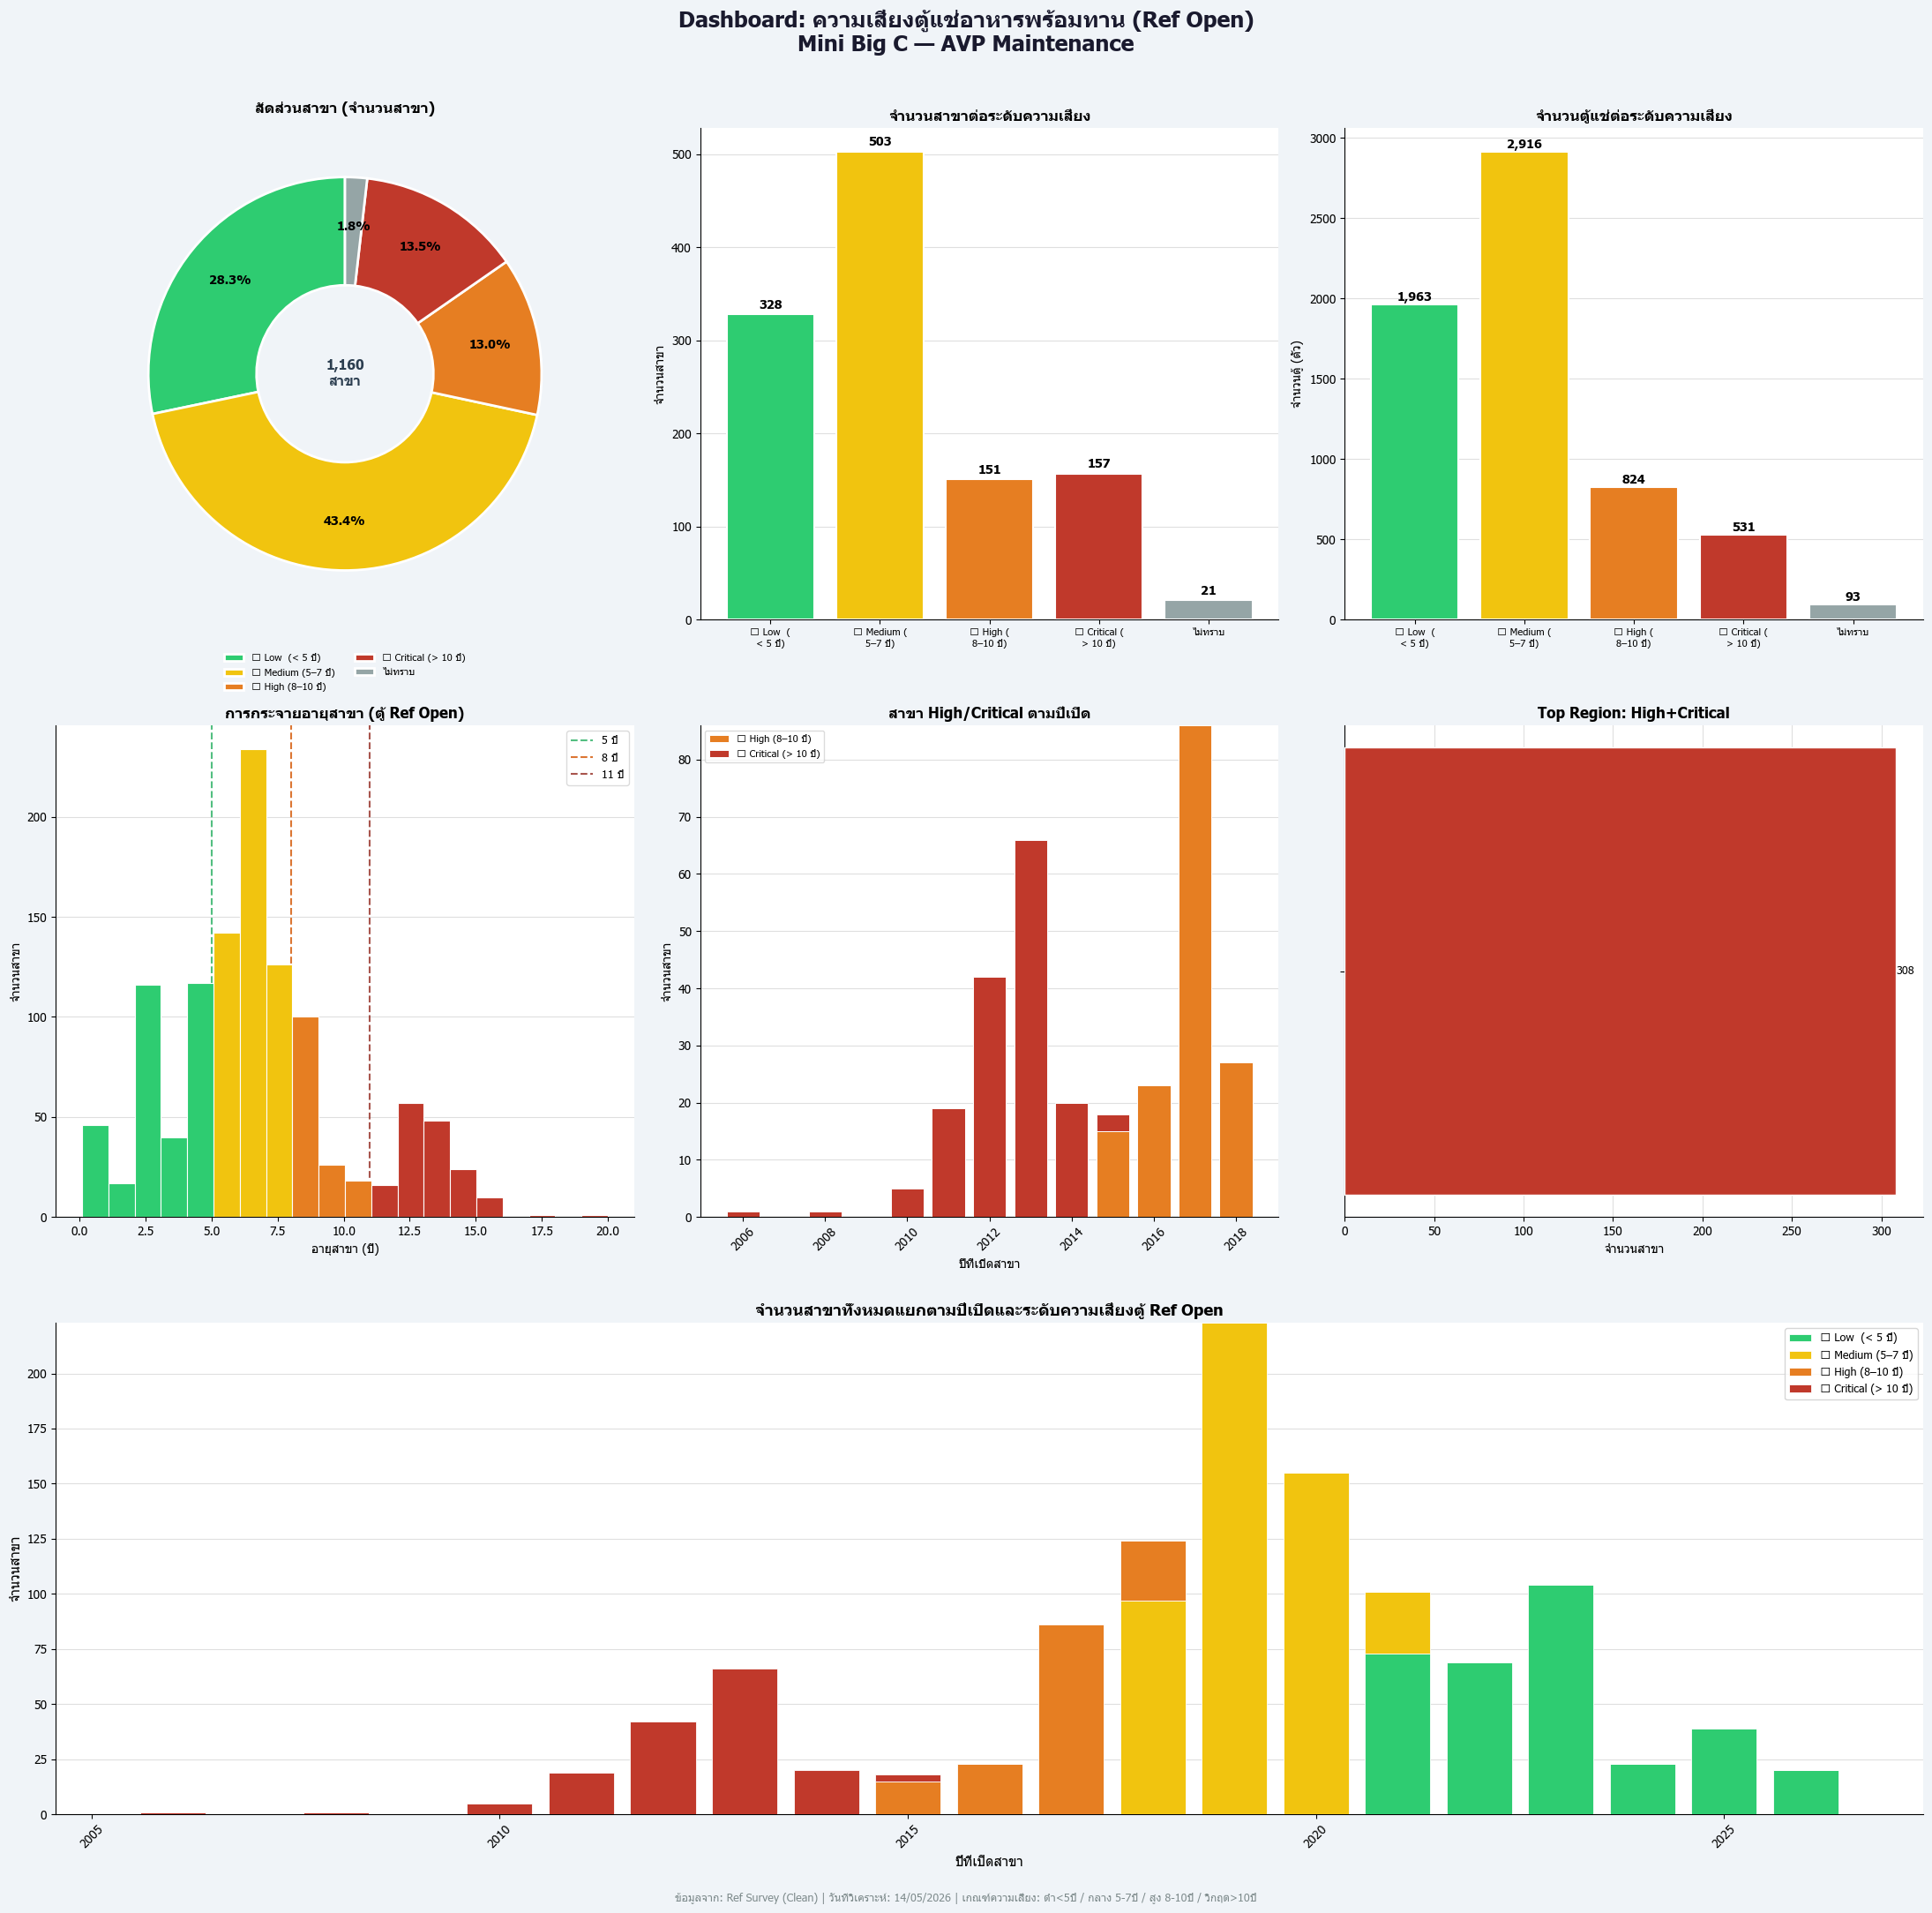

✅ Dashboard saved


In [14]:
# ═══════════════════════════════════════════════════════════
# 5.  Dashboard — 6 Charts
# ═══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 22), facecolor='#f0f4f8')
fig.suptitle('Dashboard: ความเสี่ยงตู้แช่อาหารพร้อมทาน (Ref Open)\nMini Big C — AVP Maintenance',
             fontsize=18, fontweight='bold', y=0.98, color='#1a1a2e')

PALETTE = [RISK_COLORS_HEX[k] for k in RISK_ORDER_KEYS if k in analysis_df['Risk Key'].unique()]
LABELS  = risk_summary['Label'].tolist()
RISK_KEY_LIST = [k for k in RISK_ORDER_KEYS if k in analysis_df['Risk Key'].unique()]

# ── Chart 1: Donut — สัดส่วนสาขา ──
ax1 = fig.add_subplot(3, 3, 1)
wedges, texts, autotexts = ax1.pie(
    risk_summary['Stores'], labels=None, colors=PALETTE,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
ax1.legend(wedges, LABELS, loc='upper center', bbox_to_anchor=(0.5, -0.05),
           fontsize=8, ncol=2, frameon=False)
ax1.set_title('สัดส่วนสาขา (จำนวนสาขา)', fontsize=12, fontweight='bold', pad=12)
total_stores = risk_summary['Stores'].sum()
ax1.text(0, 0, f'{total_stores:,}\nสาขา', ha='center', va='center',
         fontsize=11, fontweight='bold', color='#2c3e50')

# ── Chart 2: Bar — จำนวนสาขาต่อ Risk ──
ax2 = fig.add_subplot(3, 3, 2)
bars = ax2.bar(range(len(risk_summary)), risk_summary['Stores'], color=PALETTE,
               edgecolor='white', linewidth=1.5, zorder=3)
for bar, v in zip(bars, risk_summary['Stores']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
             f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_xticks(range(len(LABELS)))
ax2.set_xticklabels([l.replace('(','(\n') for l in LABELS], fontsize=8)
ax2.set_ylabel('จำนวนสาขา', fontsize=10); ax2.set_title('จำนวนสาขาต่อระดับความเสี่ยง', fontsize=12, fontweight='bold')
ax2.yaxis.grid(True, alpha=0.4, zorder=0); ax2.set_axisbelow(True)
ax2.spines[['top','right']].set_visible(False)

# ── Chart 3: Bar — จำนวนตู้ต่อ Risk ──
ax3 = fig.add_subplot(3, 3, 3)
bars3 = ax3.bar(range(len(risk_summary)), risk_summary['Units'], color=PALETTE,
                edgecolor='white', linewidth=1.5, zorder=3)
for bar, v in zip(bars3, risk_summary['Units']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_xticks(range(len(LABELS)))
ax3.set_xticklabels([l.replace('(','(\n') for l in LABELS], fontsize=8)
ax3.set_ylabel('จำนวนตู้ (ตัว)', fontsize=10); ax3.set_title('จำนวนตู้แช่ต่อระดับความเสี่ยง', fontsize=12, fontweight='bold')
ax3.yaxis.grid(True, alpha=0.4, zorder=0); ax3.set_axisbelow(True)
ax3.spines[['top','right']].set_visible(False)

# ── Chart 4: Histogram — การกระจายอายุ ──
ax4 = fig.add_subplot(3, 3, 4)
ages = analysis_df['Store Age (yrs)'].dropna()
n, bins, patches = ax4.hist(ages, bins=20, edgecolor='white', linewidth=0.8, color='#3498db', zorder=3)
# ระบายสีตาม risk zone
for patch, left in zip(patches, bins[:-1]):
    if left < 5:    patch.set_facecolor('#2ecc71')
    elif left < 8:  patch.set_facecolor('#f1c40f')
    elif left < 11: patch.set_facecolor('#e67e22')
    else:           patch.set_facecolor('#c0392b')
ax4.axvline(5,  color='#27ae60', linestyle='--', lw=1.5, alpha=0.8, label='5 ปี')
ax4.axvline(8,  color='#d35400', linestyle='--', lw=1.5, alpha=0.8, label='8 ปี')
ax4.axvline(11, color='#922b21', linestyle='--', lw=1.5, alpha=0.8, label='11 ปี')
ax4.set_xlabel('อายุสาขา (ปี)', fontsize=10); ax4.set_ylabel('จำนวนสาขา', fontsize=10)
ax4.set_title('การกระจายอายุสาขา (ตู้ Ref Open)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9, framealpha=0.7)
ax4.yaxis.grid(True, alpha=0.4, zorder=0); ax4.set_axisbelow(True)
ax4.spines[['top','right']].set_visible(False)

# ── Chart 5: Open Year Bar (สาขาที่เปิดแต่ละปี ของกลุ่ม High+Critical) ──
ax5 = fig.add_subplot(3, 3, 5)
hc_df = analysis_df[analysis_df['Risk Key'].isin(['3_High', '4_Critical'])].copy()
hc_df['Open Year'] = hc_df['Open Year'].fillna(0).astype(int)
yr_counts = hc_df[hc_df['Open Year'] > 2000].groupby(['Open Year','Risk Key']).size().unstack(fill_value=0)
yr_counts = yr_counts.reindex(columns=[k for k in RISK_ORDER_KEYS if k in yr_counts.columns])
bottom = np.zeros(len(yr_counts))
for key in yr_counts.columns:
    color = RISK_COLORS_HEX[key]
    ax5.bar(yr_counts.index, yr_counts[key], bottom=bottom, color=color,
            edgecolor='white', linewidth=0.7, label=RISK_LABEL[key], zorder=3)
    bottom += yr_counts[key].values
ax5.set_xlabel('ปีที่เปิดสาขา'); ax5.set_ylabel('จำนวนสาขา')
ax5.set_title('สาขา High/Critical ตามปีเปิด', fontsize=12, fontweight='bold')
ax5.legend(fontsize=8, framealpha=0.7)
ax5.tick_params(axis='x', rotation=45)
ax5.yaxis.grid(True, alpha=0.4, zorder=0); ax5.set_axisbelow(True)
ax5.spines[['top','right']].set_visible(False)

# ── Chart 6: Top 15 Region/Area — High+Critical ──
ax6 = fig.add_subplot(3, 3, 6)
region_col = 'BCM CM Region' if 'BCM CM Region' in analysis_df.columns else 'CM Area'
hc_region = (hc_df.groupby(region_col).size().sort_values(ascending=True).tail(15))
colors6 = ['#c0392b' if v >= hc_region.quantile(0.75) else '#e67e22'
           for v in hc_region.values]
ax6.barh(hc_region.index, hc_region.values, color=colors6, edgecolor='white', zorder=3)
for i, v in enumerate(hc_region.values):
    ax6.text(v+0.3, i, str(v), va='center', fontsize=9)
ax6.set_xlabel('จำนวนสาขา'); ax6.set_title('Top Region: High+Critical', fontsize=12, fontweight='bold')
ax6.xaxis.grid(True, alpha=0.4, zorder=0); ax6.set_axisbelow(True)
ax6.spines[['top','right']].set_visible(False)

# ── Chart 7–8: Box plot อายุตาม region + Scatter ──
ax7 = fig.add_subplot(3, 1, 3)
open_yr_all = analysis_df[analysis_df['Open Year'] > 2000].copy()
yr_risk = open_yr_all.groupby(['Open Year','Risk Key']).size().unstack(fill_value=0)
yr_risk = yr_risk.reindex(columns=[k for k in RISK_ORDER_KEYS if k in yr_risk.columns])
bottom7 = np.zeros(len(yr_risk))
for key in yr_risk.columns:
    color = RISK_COLORS_HEX[key]
    ax7.bar(yr_risk.index, yr_risk[key], bottom=bottom7, color=color,
            edgecolor='white', linewidth=0.6, label=RISK_LABEL[key], zorder=3, width=0.8)
    bottom7 += yr_risk[key].values
ax7.set_xlabel('ปีที่เปิดสาขา', fontsize=11); ax7.set_ylabel('จำนวนสาขา', fontsize=11)
ax7.set_title('จำนวนสาขาทั้งหมดแยกตามปีเปิดและระดับความเสี่ยงตู้ Ref Open',
              fontsize=13, fontweight='bold')
ax7.legend(fontsize=9, framealpha=0.8, loc='upper right')
ax7.tick_params(axis='x', rotation=45)
ax7.yaxis.grid(True, alpha=0.4, zorder=0); ax7.set_axisbelow(True)
ax7.spines[['top','right']].set_visible(False)

# ── footnote ──
fig.text(0.5, 0.005,
         f'ข้อมูลจาก: Ref Survey (Clean) | วันที่วิเคราะห์: {TODAY.strftime("%d/%m/%Y")} | '
         f'เกณฑ์ความเสี่ยง: ต่ำ<5ปี / กลาง 5-7ปี / สูง 8-10ปี / วิกฤต>10ปี',
         ha='center', fontsize=9, color='#7f8c8d', style='italic')

plt.tight_layout(rect=[0, 0.015, 1, 0.97])
plt.savefig(r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\RefOpen_Risk_Dashboard.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Dashboard saved")

In [15]:
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.worksheet.table import Table, TableStyleInfo
from openpyxl.drawing.image import Image as XLImage
import os

OUT_XL = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\RefOpen_Risk_Report.xlsx'

# ── Style helpers ──
def xfill(hex_str):   return PatternFill("solid", fgColor=hex_str.lstrip('#'))
def xfont(bold=False, color="000000", size=10): return Font(bold=bold, color=color, size=size)
BORDER = Border(
    left=Side(style='thin'), right=Side(style='thin'),
    top=Side(style='thin'),  bottom=Side(style='thin'))

RISK_HEX = {'1_Low':'2ecc71','2_Medium':'f1c40f','3_High':'e67e22','4_Critical':'c0392b','Unknown':'95a5a6'}
RISK_FONT_COLOR = {'1_Low':'FFFFFF','2_Medium':'1a1a1a','3_High':'FFFFFF','4_Critical':'FFFFFF','Unknown':'FFFFFF'}

def write_cell(ws, row, col, val, fill=None, bold=False, font_color='000000',
               size=10, center=False, wrap=False, num_fmt=None, border=True):
    c = ws.cell(row=row, column=col, value=val)
    if fill:  c.fill = fill
    c.font  = Font(bold=bold, color=font_color, size=size)
    c.alignment = Alignment(horizontal='center' if center else 'left',
                            vertical='center', wrap_text=wrap)
    if border: c.border = BORDER
    if num_fmt: c.number_format = num_fmt
    return c

wb = Workbook()

# ═══════════════════════════════════════════════════════════
# SHEET 1 : Dashboard Image
# ═══════════════════════════════════════════════════════════
ws_dash = wb.active
ws_dash.title = "Dashboard"
ws_dash.sheet_view.showGridLines = False
IMG_PATH = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\RefOpen_Risk_Dashboard.png'
if os.path.exists(IMG_PATH):
    img = XLImage(IMG_PATH)
    img.anchor = 'A1'
    ws_dash.add_image(img)
    ws_dash.column_dimensions['A'].width = 160
    ws_dash.row_dimensions[1].height = 900

# ═══════════════════════════════════════════════════════════
# SHEET 2 : Summary
# ═══════════════════════════════════════════════════════════
ws_s = wb.create_sheet("Risk Summary")
ws_s.sheet_view.showGridLines = False

# Title
ws_s.merge_cells("A1:H1")
write_cell(ws_s, 1, 1,
    f'สรุปความเสี่ยงตู้แช่อาหารพร้อมทาน (Ref Open) — Mini Big C  |  วันที่: {TODAY.strftime("%d/%m/%Y")}',
    fill=xfill('1F4E79'), bold=True, font_color='FFFFFF', size=14, center=True)
ws_s.row_dimensions[1].height = 32

# Sub-title
for c, txt in enumerate(['ระดับความเสี่ยง','คำอธิบาย','จำนวนสาขา','สัดส่วน (%)','จำนวนตู้ (ตัว)','สัดส่วนตู้ (%)','อายุเฉลี่ย (ปี)','Action แนะนำ'], 1):
    write_cell(ws_s, 2, c, txt, fill=xfill('2E75B6'), bold=True, font_color='FFFFFF', size=10, center=True)
ws_s.row_dimensions[2].height = 20

total_stores2 = risk_summary['Stores'].sum()
total_units2  = risk_summary['Units'].sum()

actions = {
    '1_Low':      'Monitor ปกติ — Survey ปีละ 1 ครั้ง',
    '2_Medium':   'Preventive Maintenance ก่อนครบ 8 ปี',
    '3_High':     'PM เร่งด่วน + วางแผน Replace ภายใน 1-2 ปี',
    '4_Critical': 'Replace ทันที — ความเสี่ยงสูง (เกิน 10 ปี)',
    'Unknown':    'ตรวจสอบ Date Open Store'
}
desc = {
    '1_Low':      'อายุ < 5 ปี — ยังอยู่ในช่วงใช้งานปกติ',
    '2_Medium':   'อายุ 5–7 ปี — เริ่มเข้าสู่ช่วงเฝ้าระวัง',
    '3_High':     'อายุ 8–10 ปี — ใกล้ถึงอายุการใช้งานมาตรฐาน',
    '4_Critical': 'อายุ > 10 ปี — เกินอายุการใช้งานมาตรฐาน',
    'Unknown':    'ไม่มีข้อมูลวันเปิดสาขา'
}

row3 = 3
for _, r in risk_summary.iterrows():
    k = r['Risk Key']
    pct_s = r['Stores'] / total_stores2 * 100
    pct_u = r['Units']  / total_units2  * 100
    fg = xfill(RISK_HEX[k])
    fc = RISK_FONT_COLOR[k]
    write_cell(ws_s, row3, 1, r['Label'],    fill=fg, bold=True, font_color=fc, center=True)
    write_cell(ws_s, row3, 2, desc[k],       fill=fg, font_color=fc, wrap=True)
    write_cell(ws_s, row3, 3, r['Stores'],   fill=fg, bold=True, font_color=fc, center=True, num_fmt='#,##0')
    write_cell(ws_s, row3, 4, round(pct_s,1),fill=fg, font_color=fc, center=True, num_fmt='0.0"%"')
    write_cell(ws_s, row3, 5, r['Units'],    fill=fg, bold=True, font_color=fc, center=True, num_fmt='#,##0')
    write_cell(ws_s, row3, 6, round(pct_u,1),fill=fg, font_color=fc, center=True, num_fmt='0.0"%"')
    write_cell(ws_s, row3, 7, r['AvgAge'],   fill=fg, font_color=fc, center=True, num_fmt='0.0')
    write_cell(ws_s, row3, 8, actions[k],    fill=fg, font_color=fc, wrap=True)
    ws_s.row_dimensions[row3].height = 28
    row3 += 1

# Total row
write_cell(ws_s, row3, 1, 'รวมทั้งหมด', fill=xfill('BDD7EE'), bold=True, center=True)
write_cell(ws_s, row3, 2, '', fill=xfill('BDD7EE'))
write_cell(ws_s, row3, 3, total_stores2, fill=xfill('BDD7EE'), bold=True, center=True, num_fmt='#,##0')
write_cell(ws_s, row3, 4, 100.0, fill=xfill('BDD7EE'), center=True, num_fmt='0.0"%"')
write_cell(ws_s, row3, 5, total_units2, fill=xfill('BDD7EE'), bold=True, center=True, num_fmt='#,##0')
write_cell(ws_s, row3, 6, 100.0, fill=xfill('BDD7EE'), center=True, num_fmt='0.0"%"')
write_cell(ws_s, row3, 7, '', fill=xfill('BDD7EE'))
write_cell(ws_s, row3, 8, '', fill=xfill('BDD7EE'))
ws_s.row_dimensions[row3].height = 22

# column widths
for ci, w in zip(range(1,9), [28, 40, 14, 12, 14, 12, 14, 45]):
    ws_s.column_dimensions[get_column_letter(ci)].width = w

# ═══════════════════════════════════════════════════════════
# SHEET 3 : High & Critical Store List (Action List)
# ═══════════════════════════════════════════════════════════
ws_hc = wb.create_sheet("Action List (High+Critical)")
hc_export = analysis_df[analysis_df['Risk Key'].isin(['3_High','4_Critical'])].copy()
hc_export = hc_export.sort_values(['Risk Key','Store Age (yrs)'], ascending=[True, False])

hc_cols = ['Branch Code','Branch Name','Store Name(th) (2)','CM Area','DM Area',
           'Province','HUB (18)','Date Open Store','Store Age (yrs)',
           'Ref Open Qty Num','Risk Level']
hc_out = hc_export[[c for c in hc_cols if c in hc_export.columns]].copy()
hc_out['Date Open Store'] = hc_out['Date Open Store'].dt.strftime('%d/%m/%Y') if hasattr(hc_out['Date Open Store'].dtype, 'tz') else hc_out['Date Open Store'].astype(str)

col_headers = {
    'Branch Code':'รหัสสาขา','Branch Name':'ชื่อสาขา','Store Name(th) (2)':'ชื่อสาขา (Master)',
    'CM Area':'CM Area','DM Area':'DM Area','Province':'จังหวัด','HUB (18)':'HUB',
    'Date Open Store':'วันเปิดสาขา','Store Age (yrs)':'อายุ (ปี)',
    'Ref Open Qty Num':'จำนวนตู้ Ref Open','Risk Level':'ระดับความเสี่ยง'
}
display_cols = [c for c in hc_cols if c in hc_out.columns]
header_labels = [col_headers.get(c, c) for c in display_cols]

# Header row
for ci, h_label in enumerate(header_labels, 1):
    write_cell(ws_hc, 1, ci, h_label, fill=xfill('1F4E79'), bold=True,
               font_color='FFFFFF', size=10, center=True)
ws_hc.row_dimensions[1].height = 22

# Data rows
for ri, (_, row_data) in enumerate(hc_out.iterrows(), 2):
    k = row_data.get('Risk Key', '') if 'Risk Key' in row_data else ''
    risk_str = str(row_data.get('Risk Level', ''))
    if '4_Critical' in str(hc_export.loc[row_data.name, 'Risk Key'] if row_data.name in hc_export.index else '') or 'Critical' in risk_str:
        row_fill = xfill('FADBD8')
    else:
        row_fill = xfill('FDEBD0') if ri % 2 == 0 else xfill('FEF9E7')
    for ci, col_name in enumerate(display_cols, 1):
        val = row_data.get(col_name, '')
        nf = '#,##0.0' if col_name == 'Store Age (yrs)' else ('#,##0' if col_name == 'Ref Open Qty Num' else None)
        write_cell(ws_hc, ri, ci, val, fill=row_fill, num_fmt=nf,
                   center=(col_name in ['Branch Code','Store Age (yrs)','Ref Open Qty Num','Date Open Store']))

# Excel Table
tbl_ref = f"A1:{get_column_letter(len(display_cols))}{len(hc_out)+1}"
tbl_hc = Table(displayName="ActionList", ref=tbl_ref)
tbl_hc.tableStyleInfo = TableStyleInfo(name="TableStyleMedium3",
    showRowStripes=True, showFirstColumn=False, showLastColumn=False)
ws_hc.add_table(tbl_hc)
ws_hc.freeze_panes = "A2"

# auto width
for ci, col_name in enumerate(display_cols, 1):
    vals = [str(col_headers.get(col_name, col_name))] + [str(v) for v in hc_out[col_name].head(100)]
    w = min(max(len(v) for v in vals) + 2, 40)
    ws_hc.column_dimensions[get_column_letter(ci)].width = w

print(f"Action List: {len(hc_out)} สาขา (High: {(hc_export['Risk Key']=='3_High').sum()}, Critical: {(hc_export['Risk Key']=='4_Critical').sum()})")

# ═══════════════════════════════════════════════════════════
# SHEET 4 : Full Data — All stores with risk
# ═══════════════════════════════════════════════════════════
ws_all = wb.create_sheet("All Stores - Ref Open")
all_export = analysis_df.sort_values(['Risk Key','Store Age (yrs)'], ascending=[True, False]).copy()
all_export = all_export[[c for c in hc_cols if c in all_export.columns]]

all_display = [c for c in hc_cols if c in all_export.columns]
all_labels  = [col_headers.get(c, c) for c in all_display]

for ci, h_label in enumerate(all_labels, 1):
    write_cell(ws_all, 1, ci, h_label, fill=xfill('1F4E79'), bold=True,
               font_color='FFFFFF', size=10, center=True)
ws_all.row_dimensions[1].height = 22

for ri, (_, row_data) in enumerate(all_export.iterrows(), 2):
    rl = str(row_data.get('Risk Level', ''))
    if 'Critical' in rl:   rf = xfill('FADBD8')
    elif 'High' in rl:     rf = xfill('FDEBD0')
    elif 'Medium' in rl:   rf = xfill('FEFDE7') if ri%2==0 else None
    else:                   rf = xfill('EAFAF1') if ri%2==0 else None
    for ci, col_name in enumerate(all_display, 1):
        val = row_data.get(col_name, '')
        nf = '#,##0.0' if col_name == 'Store Age (yrs)' else ('#,##0' if col_name == 'Ref Open Qty Num' else None)
        write_cell(ws_all, ri, ci, val, fill=rf, num_fmt=nf,
                   center=(col_name in ['Branch Code','Store Age (yrs)','Ref Open Qty Num','Date Open Store']))

tbl_all_ref = f"A1:{get_column_letter(len(all_display))}{len(all_export)+1}"
tbl_all = Table(displayName="AllStoresRefOpen", ref=tbl_all_ref)
tbl_all.tableStyleInfo = TableStyleInfo(name="TableStyleMedium2", showRowStripes=True)
ws_all.add_table(tbl_all)
ws_all.freeze_panes = "A2"
for ci, col_name in enumerate(all_display, 1):
    vals = [str(all_labels[ci-1])] + [str(v) for v in all_export[col_name].head(100)]
    ws_all.column_dimensions[get_column_letter(ci)].width = min(max(len(v) for v in vals)+2, 40)

# ── Save ──
wb.save(OUT_XL)
print(f"\n✅ Saved: {OUT_XL}")
print(f"   Sheet 'Dashboard'           : รูป Dashboard")
print(f"   Sheet 'Risk Summary'        : สรุปความเสี่ยง 4 ระดับ")
print(f"   Sheet 'Action List'         : {len(hc_out)} สาขา High+Critical")
print(f"   Sheet 'All Stores - Ref Open': {len(all_export)} สาขา ทุก Risk Level")

Action List: 308 สาขา (High: 151, Critical: 157)

✅ Saved: G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\RefOpen_Risk_Report.xlsx
   Sheet 'Dashboard'           : รูป Dashboard
   Sheet 'Risk Summary'        : สรุปความเสี่ยง 4 ระดับ
   Sheet 'Action List'         : 308 สาขา High+Critical
   Sheet 'All Stores - Ref Open': 1160 สาขา ทุก Risk Level


In [16]:
# ── ตรวจ merge key ──
print("energy_data Store ID sample:", energy_data['Store ID'].dropna().head(5).tolist())
print("df_refig_survey Branch Code sample:", df_refig_survey_Clean['Branch Code'].head(5).tolist())
print("master_active GOLD Code sample:", master_active['GOLD Code'].head(5).tolist())
print("energy_data rows:", len(energy_data))
print("energy_data kWh 2025 non-null:", energy_data['kWh 2025'].notna().sum())
print("Frozen Status cols:", [c for c in df_refig_survey_Clean.columns if 'Frozen' in c and 'Status' in c][:5])
print("Frozen Status sample:")
st_cols = [c for c in df_refig_survey_Clean.columns if 'Frozen' in c and 'Status' in c]
print(df_refig_survey_Clean[df_refig_survey_Clean['Ref Frozen1 Door Qty'].astype(str).str.extract(r'(\d+)', expand=False).fillna('0').astype(int) > 0][st_cols[:3]].head(5).to_string())

# จำนวนตู้ทั้งหมดต่อ store
all_ref_qty_cols = [c for c in df_refig_survey_Clean.columns if c.endswith('Qty') and c.startswith('Ref')]
print("\nAll Ref Qty cols:", all_ref_qty_cols)

energy_data Store ID sample: [21718.0, 22696.0, 22520.0, 22697.0, 22406.0]
df_refig_survey Branch Code sample: [11235, 21002, 21005, 21007, 21009]
master_active GOLD Code sample: ['21002', '21005', '21007', '21008', '21009']
energy_data rows: 1582
energy_data kWh 2025 non-null: 1582
Frozen Status cols: ['Ref Frozen Status_2', 'Ref Frozen Status_4', 'Ref Frozen Status_1', 'Ref Frozen Status_3', 'Ref Frozen Status_6']
Frozen Status sample:
   Ref Frozen Status_2 Ref Frozen Status_4 Ref Frozen Status_1
2               ใช้งาน                                  ใช้งาน
4                                                       ใช้งาน
8               ใช้งาน                                  ใช้งาน
12              ใช้งาน              ใช้งาน              ใช้งาน
13              ใช้งาน                                  ใช้งาน

All Ref Qty cols: ['Ref Open Qty', 'Ref Bev Walk In Qty', 'Ref Frozen3 Door Qty', 'Ref Ice Cream Qty', 'Ref Ice Qty', 'Ref Frozen1 Door Qty', 'Ref Bev Plugin Qty', 'Ref Frozen2 Do

In [17]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib import rcParams
from scipy import stats
rcParams['font.family'] = 'Tahoma'
rcParams['axes.unicode_minus'] = False

TODAY = pd.Timestamp.today().normalize()

# ═══════════════════════════════════════════════════════════════════
# PART A — FROZEN RISK ANALYSIS
# ═══════════════════════════════════════════════════════════════════

# ── Risk classification (Frozen อายุมาตรฐาน 12 ปี) ──
def classify_frozen_risk(age):
    if pd.isna(age):   return 'Unknown'
    if age < 5:        return '1_Low'
    elif age < 9:      return '2_Medium'
    elif age < 13:     return '3_High'
    else:              return '4_Critical'

F_LABEL = {
    '1_Low':      '🟢 Low  (< 5 ปี)',
    '2_Medium':   '🟡 Medium (5–8 ปี)',
    '3_High':     '🔴 High (9–12 ปี)',
    '4_Critical': '⛔ Critical (> 12 ปี)',
    'Unknown':    'ไม่ทราบ'
}
F_COLOR = {'1_Low':'#2ecc71','2_Medium':'#f1c40f','3_High':'#e67e22','4_Critical':'#c0392b','Unknown':'#95a5a6'}
F_ORDER = ['1_Low','2_Medium','3_High','4_Critical','Unknown']

# ── Frozen stores: มี Frozen ≥ 1 ตู้ ──
ref_f = df_refig_survey_Clean.copy()
for qc in ['Ref Frozen1 Door Qty','Ref Frozen2 Door Qty','Ref Frozen3 Door Qty']:
    ref_f[qc] = pd.to_numeric(ref_f[qc], errors='coerce').fillna(0)

ref_f['Frozen Total Qty'] = ref_f['Ref Frozen1 Door Qty'] + ref_f['Ref Frozen2 Door Qty'] + ref_f['Ref Frozen3 Door Qty']
frozen_stores = ref_f[ref_f['Frozen Total Qty'] >= 1][
    ['Branch Code','Branch Name','DM Area','CM Area',
     'Ref Frozen1 Door Qty','Ref Frozen2 Door Qty','Ref Frozen3 Door Qty','Frozen Total Qty']].copy()
frozen_stores['Branch Code'] = frozen_stores['Branch Code'].astype(str).str.strip()
print(f"สาขาที่มี Frozen ≥ 1 ตัว: {len(frozen_stores)} สาขา  |  ตู้รวม: {int(frozen_stores['Frozen Total Qty'].sum())} ตัว")

# ── Merge กับ Master ──
frozen_df = frozen_stores.merge(
    master_active[['GOLD Code','Store Name(th) (2)','Date Open Store','Already open Month',
                   'Store Age (yrs)','Open Year','BCM CM Region','HUB (18)','Province']],
    left_on='Branch Code', right_on='GOLD Code', how='left'
).drop(columns=['GOLD Code'])

no_date_f = frozen_df['Store Age (yrs)'].isna()
frozen_df.loc[no_date_f,'Store Age (yrs)'] = (
    pd.to_numeric(frozen_df.loc[no_date_f,'Already open Month'], errors='coerce') / 12).round(1)
frozen_df['Store Age (yrs)'] = pd.to_numeric(frozen_df['Store Age (yrs)'], errors='coerce')

frozen_df['Risk Key']   = frozen_df['Store Age (yrs)'].apply(classify_frozen_risk)
frozen_df['Risk Level'] = frozen_df['Risk Key'].map(F_LABEL)

# ── Frozen Risk Summary ──
f_risk_sum = (frozen_df.groupby('Risk Key', sort=True)
    .agg(Stores=('Branch Code','count'),
         Units=('Frozen Total Qty','sum'),
         U_1D=('Ref Frozen1 Door Qty','sum'),
         U_2D=('Ref Frozen2 Door Qty','sum'),
         U_3D=('Ref Frozen3 Door Qty','sum'),
         AvgAge=('Store Age (yrs)','mean'))
    .reindex([k for k in F_ORDER if k in frozen_df['Risk Key'].unique()])
    .reset_index())
f_risk_sum['AvgAge'] = f_risk_sum['AvgAge'].round(1)
for c in ['Units','U_1D','U_2D','U_3D']: f_risk_sum[c] = f_risk_sum[c].astype(int)
f_risk_sum['Label'] = f_risk_sum['Risk Key'].map(F_LABEL)

print("\n=== Frozen Risk Summary ===")
for _, r in f_risk_sum.iterrows():
    print(f"  {r['Label']:32s}  {r['Stores']:4d} สาขา | {r['Units']:5d} ตัว (1D:{r['U_1D']} 2D:{r['U_2D']} 3D:{r['U_3D']}) | อายุเฉลี่ย {r['AvgAge']:.1f} ปี")

สาขาที่มี Frozen ≥ 1 ตัว: 1137 สาขา  |  ตู้รวม: 3312 ตัว

=== Frozen Risk Summary ===
  🟢 Low  (< 5 ปี)                    325 สาขา |  1238 ตัว (1D:1202 2D:18 3D:18) | อายุเฉลี่ย 3.0 ปี
  🟡 Medium (5–8 ปี)                  586 สาขา |  1664 ตัว (1D:1514 2D:64 3D:86) | อายุเฉลี่ย 6.8 ปี
  🔴 High (9–12 ปี)                   118 สาขา |   204 ตัว (1D:114 2D:54 3D:36) | อายุเฉลี่ย 11.4 ปี
  ⛔ Critical (> 12 ปี)                87 สาขา |   164 ตัว (1D:87 2D:52 3D:25) | อายุเฉลี่ย 14.1 ปี
  ไม่ทราบ                             21 สาขา |    42 ตัว (1D:35 2D:4 3D:3) | อายุเฉลี่ย nan ปี


In [18]:
# ═══════════════════════════════════════════════════════════════════
# PART B — ENERGY + REFRIG MASTER TABLE
# ═══════════════════════════════════════════════════════════════════

# ── normalise keys ──
energy = energy_data.copy()
energy['Store ID'] = pd.to_numeric(energy['Store ID'], errors='coerce').astype('Int64').astype(str).str.strip()
energy['kWh 2025']     = pd.to_numeric(energy['kWh 2025'],    errors='coerce')
energy['kWh 2024']     = pd.to_numeric(energy['kWh 2024'],    errors='coerce')
energy['kWh/sqm 2025'] = pd.to_numeric(energy['kWh/sqm 2025'],errors='coerce')
energy['Net sqm']      = pd.to_numeric(energy['Net sqm'],      errors='coerce')

# ── รวมจำนวนตู้แช่ทุกประเภทต่อสาขา ──
ref_qty_cols = [c for c in df_refig_survey_Clean.columns if c.endswith('Qty') and c.startswith('Ref')]
refig_sum = df_refig_survey_Clean[['Branch Code'] + ref_qty_cols].copy()
for c in ref_qty_cols:
    refig_sum[c] = pd.to_numeric(refig_sum[c], errors='coerce').fillna(0)
refig_sum['Total Ref Units'] = refig_sum[ref_qty_cols].sum(axis=1)
refig_sum['Frozen Total']    = (refig_sum['Ref Frozen1 Door Qty'] + refig_sum['Ref Frozen2 Door Qty'] + refig_sum['Ref Frozen3 Door Qty'])
refig_sum['Ref Open Qty_n']  = refig_sum['Ref Open Qty']
refig_sum['Branch Code']     = refig_sum['Branch Code'].astype(str).str.strip()

# ── Merge: energy ← refig survey ← master_active ──
master_key = master_active[['GOLD Code','Store Age (yrs)','Date Open Store','Open Year','BCM CM Region',
                             'Province','HUB (18)','AMM MTN (23)','Store Name(th) (2)']].copy()
master_key['GOLD Code'] = master_key['GOLD Code'].astype(str).str.strip()

energy_ref = (energy
    .merge(refig_sum[['Branch Code','Total Ref Units','Frozen Total','Ref Open Qty_n'] + ref_qty_cols],
           left_on='Store ID', right_on='Branch Code', how='left')
    .merge(master_key, left_on='Store ID', right_on='GOLD Code', how='left')
    .drop(columns=['Branch Code','GOLD Code'], errors='ignore'))

energy_ref['Total Ref Units'] = energy_ref['Total Ref Units'].fillna(0)
energy_ref['Frozen Total']    = energy_ref['Frozen Total'].fillna(0)
energy_ref['Store Age (yrs)'] = pd.to_numeric(energy_ref['Store Age (yrs)'], errors='coerce')

# ── เพิ่ม Risk Level ──
energy_ref['Risk Key']   = energy_ref['Store Age (yrs)'].apply(
    lambda x: '1_Low' if (pd.notna(x) and x<5) else ('2_Medium' if (pd.notna(x) and x<9) else
              ('3_High' if (pd.notna(x) and x<13) else ('4_Critical' if pd.notna(x) else 'Unknown'))))
energy_ref['Risk Level'] = energy_ref['Risk Key'].map(F_LABEL)

# ── filter: only stores with kWh > 0 and survey data ──
energy_valid = energy_ref[
    (energy_ref['kWh 2025'] > 0) &
    (energy_ref['Total Ref Units'] > 0) &
    (energy_ref['Store Age (yrs)'].notna())
].copy()

print(f"Energy x Refig valid records: {len(energy_valid)} สาขา")
print(f"  kWh 2025 range: {energy_valid['kWh 2025'].min():,.0f} – {energy_valid['kWh 2025'].max():,.0f}")
print(f"  Store Age: {energy_valid['Store Age (yrs)'].min():.1f} – {energy_valid['Store Age (yrs)'].max():.1f} ปี")
print(f"  Total Ref Units: {energy_valid['Total Ref Units'].min():.0f} – {energy_valid['Total Ref Units'].max():.0f}")
print(f"\nCorrelation matrix:")
corr = energy_valid[['kWh 2025','kWh/sqm 2025','Store Age (yrs)','Total Ref Units','Frozen Total','Net sqm']].corr()
print(corr.round(3))

Energy x Refig valid records: 1202 สาขา
  kWh 2025 range: 5,315 – 429,964
  Store Age: 0.2 – 20.0 ปี
  Total Ref Units: 1 – 45

Correlation matrix:
                 kWh 2025  kWh/sqm 2025  Store Age (yrs)  Total Ref Units  \
kWh 2025            1.000         0.587            0.326            0.065   
kWh/sqm 2025        0.587         1.000            0.205           -0.121   
Store Age (yrs)     0.326         0.205            1.000           -0.371   
Total Ref Units     0.065        -0.121           -0.371            1.000   
Frozen Total       -0.015        -0.160           -0.445            0.650   
Net sqm             0.412        -0.354            0.092            0.212   

                 Frozen Total  Net sqm  
kWh 2025               -0.015    0.412  
kWh/sqm 2025           -0.160   -0.354  
Store Age (yrs)        -0.445    0.092  
Total Ref Units         0.650    0.212  
Frozen Total            1.000    0.184  
Net sqm                 0.184    1.000  


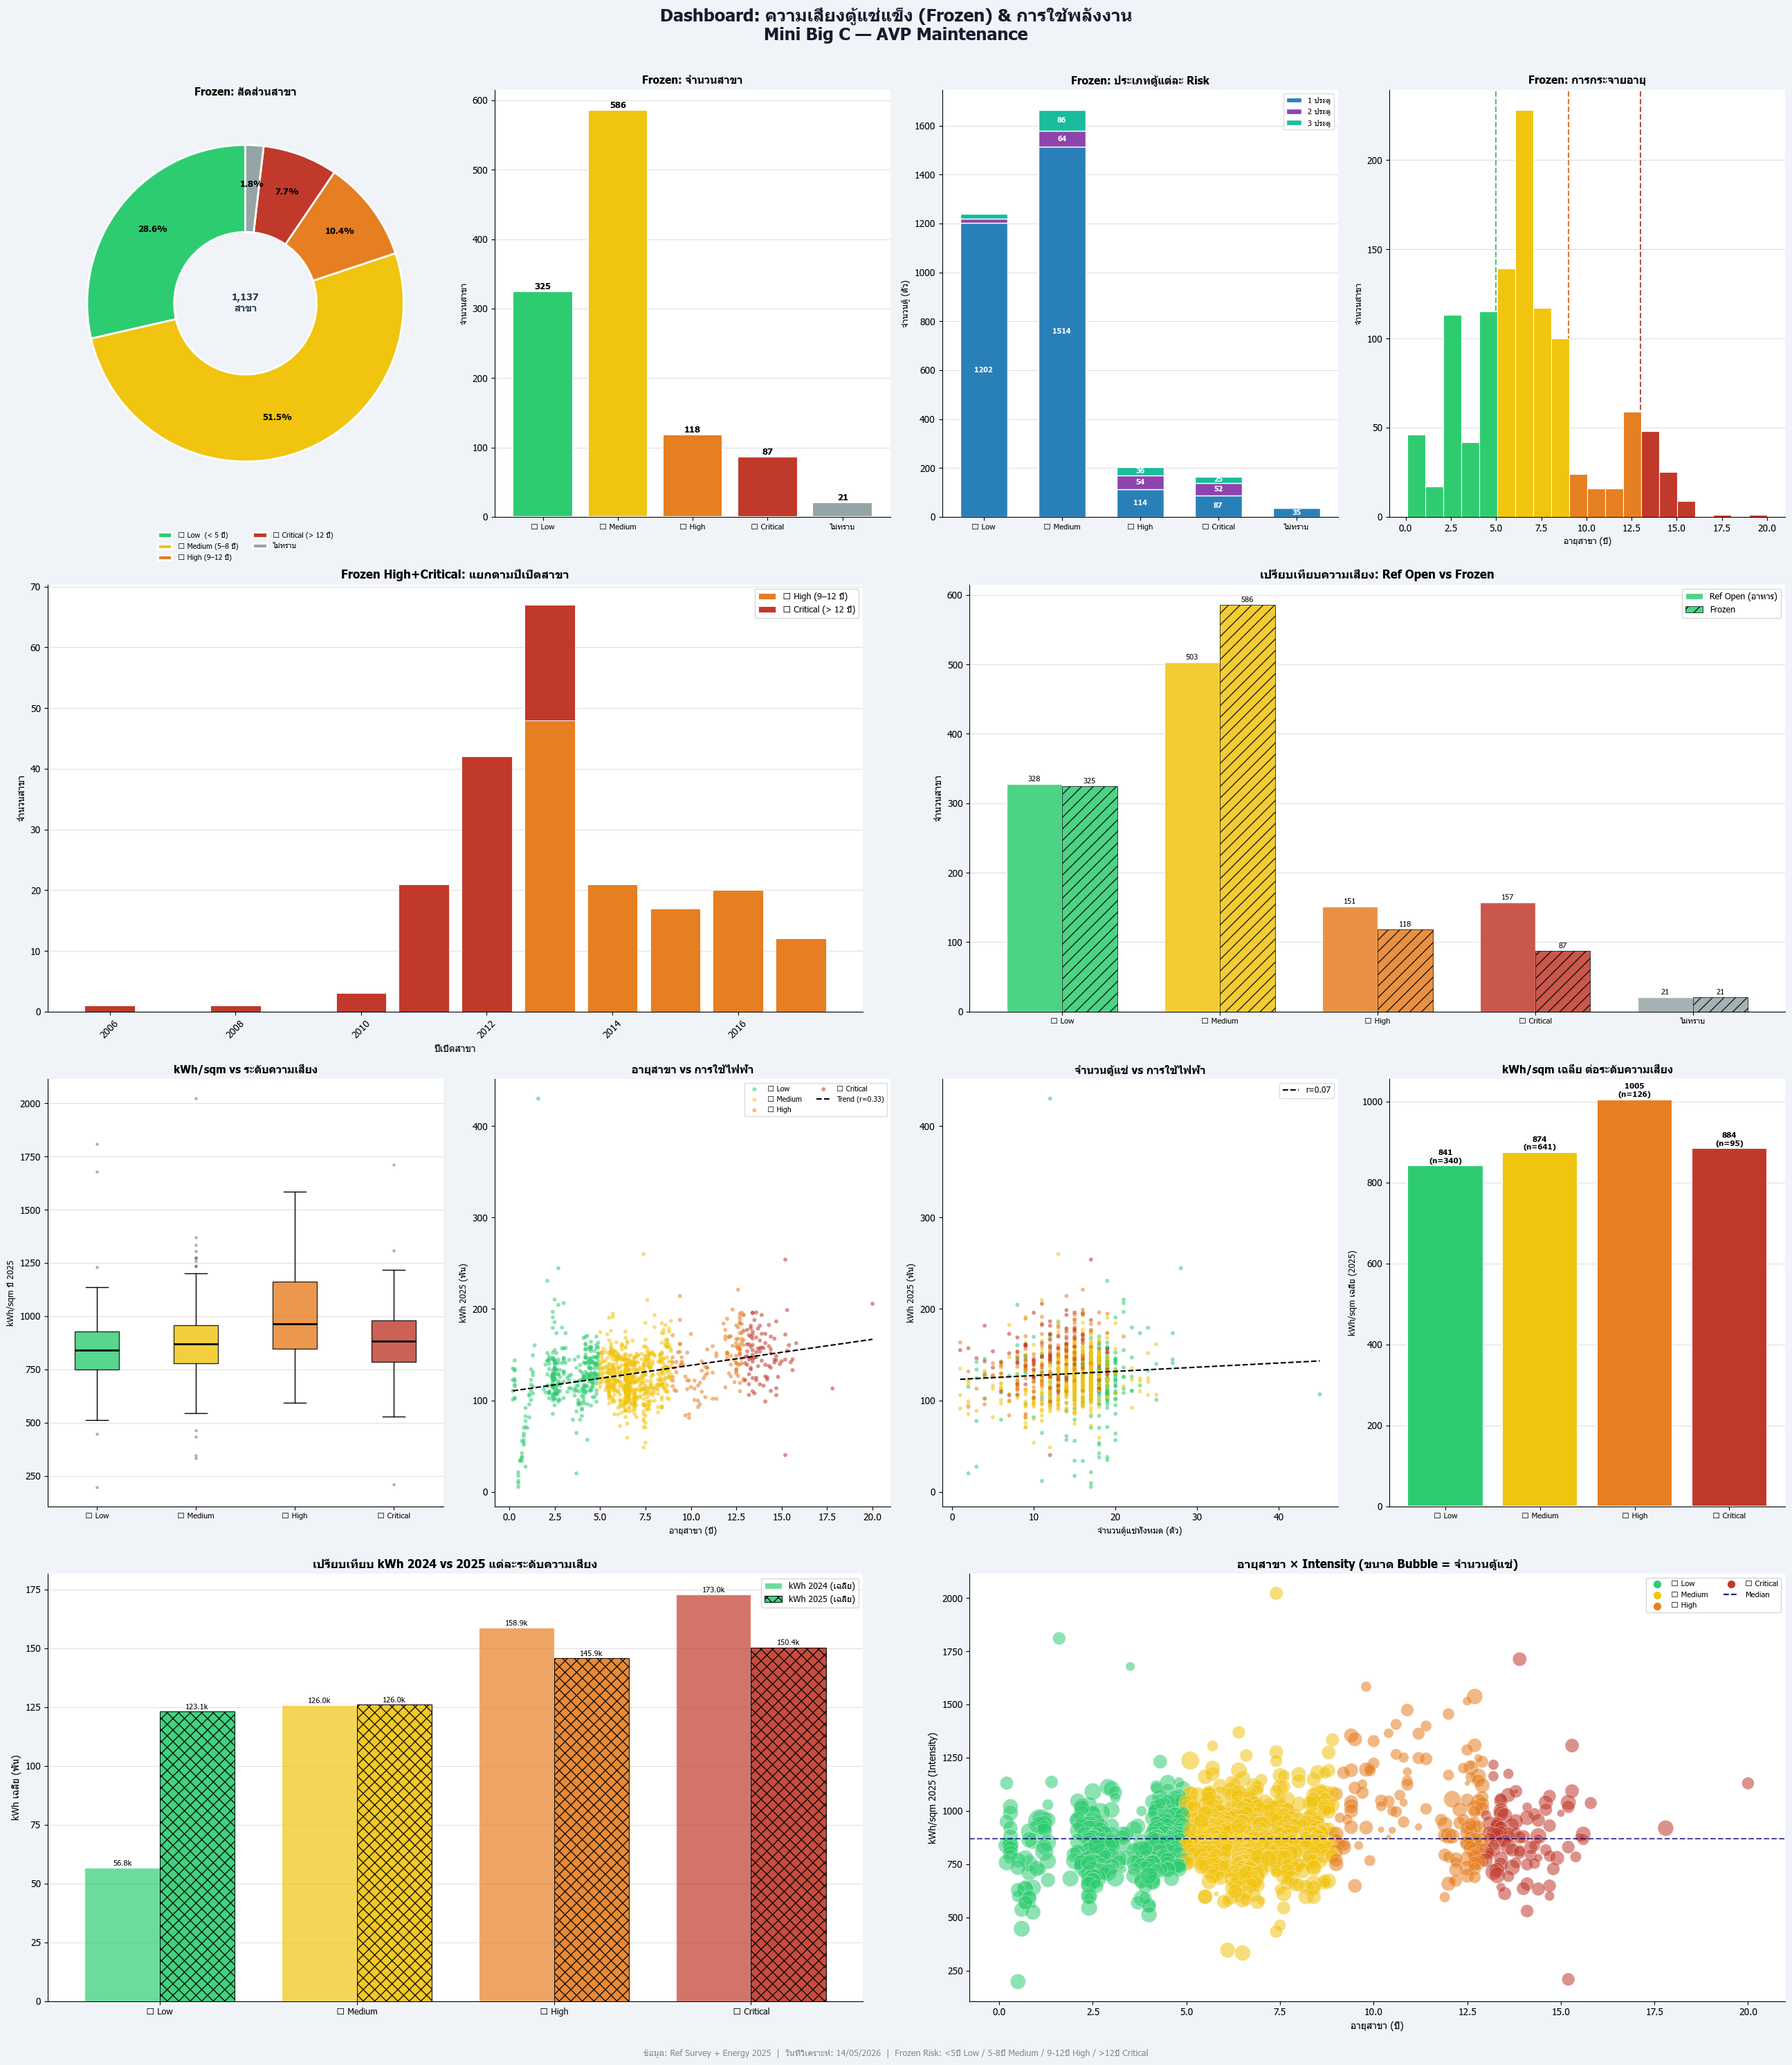

✅ Dashboard saved


In [19]:
# ═══════════════════════════════════════════════════════════════════
# PART C — COMBINED DASHBOARD  (Frozen Risk + Energy Analysis)
# ═══════════════════════════════════════════════════════════════════
F_PALETTE = [F_COLOR[k] for k in F_ORDER if k in frozen_df['Risk Key'].unique()]
F_LABELS  = [F_LABEL[k] for k in F_ORDER if k in frozen_df['Risk Key'].unique()]
valid_keys = [k for k in F_ORDER if k in frozen_df['Risk Key'].unique()]

fig = plt.figure(figsize=(26, 30), facecolor='#f0f4f8')
fig.suptitle('Dashboard: ความเสี่ยงตู้แช่แข็ง (Frozen) & การใช้พลังงาน\nMini Big C — AVP Maintenance',
             fontsize=18, fontweight='bold', y=0.99, color='#1a1a2e')

# ─── ROW 1: Frozen Risk (4 charts) ─────────────────────────────────
# [1-1] Donut — สัดส่วนสาขา
ax1 = fig.add_subplot(4, 4, 1)
wedges, texts, autotexts = ax1.pie(
    f_risk_sum['Stores'], colors=F_PALETTE, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontsize(9); at.set_fontweight('bold')
ax1.legend(wedges, F_LABELS, loc='upper center', bbox_to_anchor=(0.5,-0.06), fontsize=7.5, ncol=2, frameon=False)
total_f = f_risk_sum['Stores'].sum()
ax1.text(0,0, f'{total_f:,}\nสาขา', ha='center', va='center', fontsize=10, fontweight='bold', color='#2c3e50')
ax1.set_title('Frozen: สัดส่วนสาขา', fontsize=11, fontweight='bold', pad=10)

# [1-2] Bar — จำนวนสาขา Frozen
ax2 = fig.add_subplot(4, 4, 2)
b2 = ax2.bar(range(len(f_risk_sum)), f_risk_sum['Stores'], color=F_PALETTE, edgecolor='white', linewidth=1.5, zorder=3)
for bar, v in zip(b2, f_risk_sum['Stores']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(range(len(F_LABELS))); ax2.set_xticklabels([l.split('(')[0].strip() for l in F_LABELS], fontsize=8)
ax2.set_ylabel('จำนวนสาขา', fontsize=9); ax2.set_title('Frozen: จำนวนสาขา', fontsize=11, fontweight='bold')
ax2.yaxis.grid(True, alpha=0.4, zorder=0); ax2.set_axisbelow(True); ax2.spines[['top','right']].set_visible(False)

# [1-3] Stacked Bar — ประเภท Frozen (1D/2D/3D) ต่อ Risk
ax3 = fig.add_subplot(4, 4, 3)
x3 = range(len(f_risk_sum))
w3 = 0.6
bot = np.zeros(len(f_risk_sum))
d_cols = [('U_1D','1 ประตู','#2980b9'),('U_2D','2 ประตู','#8e44ad'),('U_3D','3 ประตู','#1abc9c')]
for col, lbl, clr in d_cols:
    v3 = f_risk_sum[col].values.astype(float)
    ax3.bar(x3, v3, bottom=bot, color=clr, width=w3, edgecolor='white', label=lbl, zorder=3)
    for xi, (bv, vv) in enumerate(zip(bot, v3)):
        if vv > 20: ax3.text(xi, bv+vv/2, str(int(vv)), ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    bot += v3
ax3.set_xticks(x3); ax3.set_xticklabels([l.split('(')[0].strip() for l in F_LABELS], fontsize=8)
ax3.set_ylabel('จำนวนตู้ (ตัว)', fontsize=9); ax3.set_title('Frozen: ประเภทตู้แต่ละ Risk', fontsize=11, fontweight='bold')
ax3.legend(fontsize=8, framealpha=0.7); ax3.yaxis.grid(True, alpha=0.4, zorder=0); ax3.set_axisbelow(True)
ax3.spines[['top','right']].set_visible(False)

# [1-4] Histogram อายุ Frozen stores
ax4 = fig.add_subplot(4, 4, 4)
ages_f = frozen_df['Store Age (yrs)'].dropna()
n4, bins4, patches4 = ax4.hist(ages_f, bins=20, edgecolor='white', linewidth=0.8, zorder=3)
for patch, left in zip(patches4, bins4[:-1]):
    if left < 5:     patch.set_facecolor('#2ecc71')
    elif left < 9:   patch.set_facecolor('#f1c40f')
    elif left < 13:  patch.set_facecolor('#e67e22')
    else:            patch.set_facecolor('#c0392b')
ax4.axvline(5,  color='#27ae60', ls='--', lw=1.5, alpha=0.8)
ax4.axvline(9,  color='#d35400', ls='--', lw=1.5, alpha=0.8)
ax4.axvline(13, color='#922b21', ls='--', lw=1.5, alpha=0.8)
ax4.set_xlabel('อายุสาขา (ปี)', fontsize=9); ax4.set_ylabel('จำนวนสาขา', fontsize=9)
ax4.set_title('Frozen: การกระจายอายุ', fontsize=11, fontweight='bold')
ax4.yaxis.grid(True, alpha=0.4, zorder=0); ax4.set_axisbelow(True); ax4.spines[['top','right']].set_visible(False)

# ─── ROW 2: Open vs Frozen Combined Risk (2 wide charts) ───────────
# [2-1] Open Year bar (Frozen High+Critical)
ax5 = fig.add_subplot(4, 2, 3)
fhc = frozen_df[frozen_df['Risk Key'].isin(['3_High','4_Critical'])].copy()
fhc['Open Year'] = fhc['Open Year'].fillna(0).astype(int)
yr_fhc = fhc[fhc['Open Year']>2000].groupby(['Open Year','Risk Key']).size().unstack(fill_value=0)
yr_fhc = yr_fhc.reindex(columns=[k for k in F_ORDER if k in yr_fhc.columns])
bot5 = np.zeros(len(yr_fhc))
for key in yr_fhc.columns:
    ax5.bar(yr_fhc.index, yr_fhc[key], bottom=bot5, color=F_COLOR[key], edgecolor='white', lw=0.6,
            label=F_LABEL[key], zorder=3)
    bot5 += yr_fhc[key].values.astype(float)
ax5.set_title('Frozen High+Critical: แยกตามปีเปิดสาขา', fontsize=12, fontweight='bold')
ax5.set_xlabel('ปีเปิดสาขา', fontsize=10); ax5.set_ylabel('จำนวนสาขา', fontsize=10)
ax5.legend(fontsize=9, framealpha=0.8); ax5.tick_params(axis='x', rotation=45)
ax5.yaxis.grid(True, alpha=0.4, zorder=0); ax5.set_axisbelow(True); ax5.spines[['top','right']].set_visible(False)

# [2-2] Comparison: Ref Open vs Frozen Risk distribution
ax6 = fig.add_subplot(4, 2, 4)
open_risk_cnt = analysis_df['Risk Key'].value_counts().reindex(F_ORDER, fill_value=0)
froz_risk_cnt = frozen_df['Risk Key'].value_counts().reindex(F_ORDER, fill_value=0)
x6 = np.arange(len(F_ORDER))
w6 = 0.35
bars6a = ax6.bar(x6 - w6/2, open_risk_cnt.values, width=w6, color=[F_COLOR[k] for k in F_ORDER],
                 edgecolor='white', label='Ref Open (อาหาร)', zorder=3, alpha=0.85)
bars6b = ax6.bar(x6 + w6/2, froz_risk_cnt.values, width=w6, color=[F_COLOR[k] for k in F_ORDER],
                 edgecolor='black', linewidth=0.6, label='Frozen', zorder=3, hatch='//', alpha=0.85)
for b, v in zip(bars6a, open_risk_cnt.values):
    if v > 0: ax6.text(b.get_x()+b.get_width()/2, b.get_height()+2, str(v), ha='center', va='bottom', fontsize=8)
for b, v in zip(bars6b, froz_risk_cnt.values):
    if v > 0: ax6.text(b.get_x()+b.get_width()/2, b.get_height()+2, str(v), ha='center', va='bottom', fontsize=8)
ax6.set_xticks(x6); ax6.set_xticklabels([F_LABEL[k].split('(')[0].strip() for k in F_ORDER], fontsize=8)
ax6.set_ylabel('จำนวนสาขา', fontsize=10); ax6.set_title('เปรียบเทียบความเสี่ยง: Ref Open vs Frozen', fontsize=12, fontweight='bold')
ax6.legend(fontsize=9, framealpha=0.8); ax6.yaxis.grid(True, alpha=0.4, zorder=0)
ax6.set_axisbelow(True); ax6.spines[['top','right']].set_visible(False)

# ─── ROW 3: Energy Analysis ─────────────────────────────────────────
# [3-1] Box plot kWh/sqm vs Risk Level
ax7 = fig.add_subplot(4, 4, 9)
risk_groups = [energy_valid[energy_valid['Risk Key']==k]['kWh/sqm 2025'].dropna()
               for k in F_ORDER if k in energy_valid['Risk Key'].unique()]
valid_keys7  = [k for k in F_ORDER if k in energy_valid['Risk Key'].unique()]
bp = ax7.boxplot(risk_groups, patch_artist=True, notch=False, showfliers=True,
                 flierprops=dict(marker='o', markersize=2, alpha=0.4))
for patch, key in zip(bp['boxes'], valid_keys7):
    patch.set_facecolor(F_COLOR[key]); patch.set_alpha(0.8)
for med in bp['medians']: med.set(color='black', linewidth=2)
ax7.set_xticklabels([F_LABEL[k].split('(')[0].strip() for k in valid_keys7], fontsize=8)
ax7.set_ylabel('kWh/sqm ปี 2025', fontsize=9); ax7.set_title('kWh/sqm vs ระดับความเสี่ยง', fontsize=11, fontweight='bold')
ax7.yaxis.grid(True, alpha=0.4); ax7.set_axisbelow(True); ax7.spines[['top','right']].set_visible(False)

# [3-2] Scatter: Store Age vs kWh 2025
ax8 = fig.add_subplot(4, 4, 10)
for key in valid_keys7:
    sub = energy_valid[energy_valid['Risk Key']==key]
    ax8.scatter(sub['Store Age (yrs)'], sub['kWh 2025']/1000, c=F_COLOR[key],
                alpha=0.55, s=18, label=F_LABEL[key].split('(')[0].strip(), edgecolors='none')
# trend line
x_trend = energy_valid['Store Age (yrs)']
y_trend = energy_valid['kWh 2025']/1000
m, b_val, r, p, se = stats.linregress(x_trend.dropna(), y_trend[x_trend.notna()])
x_line = np.linspace(x_trend.min(), x_trend.max(), 100)
ax8.plot(x_line, m*x_line+b_val, 'k--', lw=1.5, label=f'Trend (r={r:.2f})')
ax8.set_xlabel('อายุสาขา (ปี)', fontsize=9); ax8.set_ylabel('kWh 2025 (พัน)', fontsize=9)
ax8.set_title('อายุสาขา vs การใช้ไฟฟ้า', fontsize=11, fontweight='bold')
ax8.legend(fontsize=7.5, framealpha=0.7, ncol=2); ax8.spines[['top','right']].set_visible(False)

# [3-3] Scatter: Total Ref Units vs kWh 2025
ax9 = fig.add_subplot(4, 4, 11)
for key in valid_keys7:
    sub = energy_valid[energy_valid['Risk Key']==key]
    ax9.scatter(sub['Total Ref Units'], sub['kWh 2025']/1000, c=F_COLOR[key],
                alpha=0.55, s=18, edgecolors='none')
x_t = energy_valid['Total Ref Units']
y_t = energy_valid['kWh 2025']/1000
m2, b2v, r2, p2, se2 = stats.linregress(x_t.dropna(), y_t[x_t.notna()])
x_l2 = np.linspace(x_t.min(), x_t.max(), 100)
ax9.plot(x_l2, m2*x_l2+b2v, 'k--', lw=1.5, label=f'r={r2:.2f}')
ax9.set_xlabel('จำนวนตู้แช่ทั้งหมด (ตัว)', fontsize=9); ax9.set_ylabel('kWh 2025 (พัน)', fontsize=9)
ax9.set_title('จำนวนตู้แช่ vs การใช้ไฟฟ้า', fontsize=11, fontweight='bold')
ax9.legend(fontsize=8.5, framealpha=0.7); ax9.spines[['top','right']].set_visible(False)

# [3-4] Bar: kWh/sqm เฉลี่ย ต่อ Risk Level
ax10 = fig.add_subplot(4, 4, 12)
energy_risk_avg = energy_valid.groupby('Risk Key').agg(
    avg_kwh_sqm=('kWh/sqm 2025','mean'), cnt=('Store ID','count')).reindex(valid_keys7).reset_index()
b10 = ax10.bar(range(len(energy_risk_avg)), energy_risk_avg['avg_kwh_sqm'],
               color=[F_COLOR[k] for k in energy_risk_avg['Risk Key']],
               edgecolor='white', lw=1.5, zorder=3)
for bar, v, c in zip(b10, energy_risk_avg['avg_kwh_sqm'], energy_risk_avg['cnt']):
    ax10.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
              f'{v:.0f}\n(n={c})', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax10.set_xticks(range(len(energy_risk_avg)))
ax10.set_xticklabels([F_LABEL[k].split('(')[0].strip() for k in energy_risk_avg['Risk Key']], fontsize=8)
ax10.set_ylabel('kWh/sqm เฉลี่ย (2025)', fontsize=9)
ax10.set_title('kWh/sqm เฉลี่ย ต่อระดับความเสี่ยง', fontsize=11, fontweight='bold')
ax10.yaxis.grid(True, alpha=0.4, zorder=0); ax10.set_axisbelow(True); ax10.spines[['top','right']].set_visible(False)

# ─── ROW 4: Wide Charts ──────────────────────────────────────────────
# [4-1] kWh 2024 vs 2025 per Risk (YoY trend)
ax11 = fig.add_subplot(4, 2, 7)
e_yoy = energy_valid.groupby('Risk Key').agg(
    kWh_2024=('kWh 2024','mean'), kWh_2025=('kWh 2025','mean')).reindex(valid_keys7).reset_index()
x11 = np.arange(len(e_yoy)); w11 = 0.38
b11a = ax11.bar(x11 - w11/2, e_yoy['kWh_2024']/1000, width=w11, color=[F_COLOR[k] for k in e_yoy['Risk Key']],
                edgecolor='white', label='kWh 2024 (เฉลี่ย)', alpha=0.7, zorder=3)
b11b = ax11.bar(x11 + w11/2, e_yoy['kWh_2025']/1000, width=w11, color=[F_COLOR[k] for k in e_yoy['Risk Key']],
                edgecolor='black', lw=0.8, label='kWh 2025 (เฉลี่ย)', hatch='xx', alpha=0.9, zorder=3)
for b, v in zip(b11a, e_yoy['kWh_2024']/1000):
    ax11.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.1f}k', ha='center', va='bottom', fontsize=8)
for b, v in zip(b11b, e_yoy['kWh_2025']/1000):
    ax11.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.1f}k', ha='center', va='bottom', fontsize=8)
ax11.set_xticks(x11); ax11.set_xticklabels([F_LABEL[k].split('(')[0].strip() for k in e_yoy['Risk Key']], fontsize=9)
ax11.set_ylabel('kWh เฉลี่ย (พัน)', fontsize=10); ax11.set_title('เปรียบเทียบ kWh 2024 vs 2025 แต่ละระดับความเสี่ยง', fontsize=12, fontweight='bold')
ax11.legend(fontsize=9, framealpha=0.8); ax11.yaxis.grid(True, alpha=0.4, zorder=0)
ax11.set_axisbelow(True); ax11.spines[['top','right']].set_visible(False)

# [4-2] Scatter: Store Age + #Units bubble → kWh/sqm intensity
ax12 = fig.add_subplot(4, 2, 8)
scatter_data = energy_valid.dropna(subset=['Store Age (yrs)','kWh/sqm 2025','Total Ref Units'])
sc = ax12.scatter(scatter_data['Store Age (yrs)'], scatter_data['kWh/sqm 2025'],
                  c=[F_COLOR[k] for k in scatter_data['Risk Key']],
                  s=scatter_data['Total Ref Units']*15, alpha=0.55, edgecolors='white', linewidths=0.4)
ax12.axhline(scatter_data['kWh/sqm 2025'].median(), color='navy', ls='--', lw=1.5, alpha=0.7,
             label=f'Median = {scatter_data["kWh/sqm 2025"].median():.0f}')
ax12.set_xlabel('อายุสาขา (ปี)', fontsize=10); ax12.set_ylabel('kWh/sqm 2025 (Intensity)', fontsize=10)
ax12.set_title('อายุสาขา × Intensity (ขนาด Bubble = จำนวนตู้แช่)', fontsize=12, fontweight='bold')
patches_legend = [plt.scatter([],[], c=F_COLOR[k], s=50, label=F_LABEL[k].split('(')[0].strip()) for k in valid_keys7]
ax12.legend(handles=patches_legend + [plt.Line2D([],[], color='navy', ls='--', label='Median')],
            fontsize=8, framealpha=0.8, ncol=2)
ax12.spines[['top','right']].set_visible(False)

fig.text(0.5, 0.003,
         f'ข้อมูล: Ref Survey + Energy 2025  |  วันที่วิเคราะห์: {TODAY.strftime("%d/%m/%Y")}  |  '
         f'Frozen Risk: <5ปี Low / 5-8ปี Medium / 9-12ปี High / >12ปี Critical',
         ha='center', fontsize=9, color='#7f8c8d', style='italic')

plt.tight_layout(rect=[0, 0.01, 1, 0.985])
DASH2 = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\Frozen_Energy_Dashboard.png'
plt.savefig(DASH2, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Dashboard saved")

In [20]:
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.worksheet.table import Table, TableStyleInfo
from openpyxl.drawing.image import Image as XLImage
import os

OUT_XL2 = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\Frozen_Energy_Risk_Report.xlsx'

# ── helpers ──
def xfill(h): return PatternFill("solid", fgColor=h.lstrip('#'))
BORDER = Border(left=Side(style='thin'), right=Side(style='thin'),
                top=Side(style='thin'),  bottom=Side(style='thin'))
def wcell(ws, row, col, val, fill=None, bold=False, fc='000000', size=10,
          center=False, wrap=False, nf=None, border=True):
    c = ws.cell(row=row, column=col, value=val)
    if fill: c.fill = fill
    c.font = Font(bold=bold, color=fc, size=size)
    c.alignment = Alignment(horizontal='center' if center else 'left', vertical='center', wrap_text=wrap)
    if border: c.border = BORDER
    if nf: c.number_format = nf
    return c

F_HEX2 = {'1_Low':'2ecc71','2_Medium':'f1c40f','3_High':'e67e22','4_Critical':'c0392b','Unknown':'95a5a6'}
F_FC2  = {'1_Low':'FFFFFF','2_Medium':'1a1a1a','3_High':'FFFFFF','4_Critical':'FFFFFF','Unknown':'FFFFFF'}

wb2 = Workbook()

# ══════════════════════════════════════════════════════
# Sheet 1: Dashboard image
# ══════════════════════════════════════════════════════
ws_d = wb2.active; ws_d.title = "Dashboard"
ws_d.sheet_view.showGridLines = False
if os.path.exists(DASH2):
    img2 = XLImage(DASH2)
    img2.anchor = 'A1'
    ws_d.add_image(img2)
    ws_d.column_dimensions['A'].width = 160
    ws_d.row_dimensions[1].height = 1100

# ══════════════════════════════════════════════════════
# Sheet 2: Frozen Risk Summary
# ══════════════════════════════════════════════════════
ws_fs = wb2.create_sheet("Frozen Risk Summary")
ws_fs.sheet_view.showGridLines = False
ws_fs.merge_cells("A1:I1")
wcell(ws_fs, 1, 1, f'สรุปความเสี่ยงตู้แช่แข็ง Frozen — Mini Big C  |  {TODAY.strftime("%d/%m/%Y")}',
      fill=xfill('1F4E79'), bold=True, fc='FFFFFF', size=14, center=True)
ws_fs.row_dimensions[1].height = 32

hdrs_f = ['ระดับความเสี่ยง','คำอธิบาย','สาขา','สัดส่วน%','ตู้รวม','1 ประตู','2 ประตู','3 ประตู','อายุเฉลี่ย (ปี)','Action แนะนำ']
for ci, h in enumerate(hdrs_f, 1):
    wcell(ws_fs, 2, ci, h, fill=xfill('2E75B6'), bold=True, fc='FFFFFF', size=10, center=True)
ws_fs.row_dimensions[2].height = 20

f_desc = {
    '1_Low':      'อายุ < 5 ปี — ปกติ',
    '2_Medium':   'อายุ 5–8 ปี — เฝ้าระวัง',
    '3_High':     'อายุ 9–12 ปี — ใกล้ End-of-Life',
    '4_Critical': 'อายุ > 12 ปี — เกิน EOL',
    'Unknown':    'ไม่มีข้อมูล'
}
f_actions = {
    '1_Low':      'Monitor + Survey ปีละ 1 ครั้ง',
    '2_Medium':   'Preventive Maintenance ก่อนครบ 9 ปี',
    '3_High':     'PM เร่งด่วน + วางแผน Replace ภายใน 1-2 ปี',
    '4_Critical': 'Replace ทันที — Risk ของแช่เสีย / ค่าไฟสูง',
    'Unknown':    'ตรวจสอบ Date Open Store'
}
total_fs = f_risk_sum['Stores'].sum(); total_fu = f_risk_sum['Units'].sum()
row_f = 3
for _, r in f_risk_sum.iterrows():
    k = r['Risk Key']
    fg2 = xfill(F_HEX2[k]); fc2 = F_FC2[k]
    wcell(ws_fs, row_f, 1,  r['Label'],                       fill=fg2, bold=True, fc=fc2, center=True)
    wcell(ws_fs, row_f, 2,  f_desc[k],                        fill=fg2, fc=fc2, wrap=True)
    wcell(ws_fs, row_f, 3,  r['Stores'],                      fill=fg2, bold=True, fc=fc2, center=True, nf='#,##0')
    wcell(ws_fs, row_f, 4,  round(r['Stores']/total_fs*100,1),fill=fg2, fc=fc2, center=True, nf='0.0"%"')
    wcell(ws_fs, row_f, 5,  r['Units'],                       fill=fg2, bold=True, fc=fc2, center=True, nf='#,##0')
    wcell(ws_fs, row_f, 6,  r['U_1D'],                        fill=fg2, fc=fc2, center=True, nf='#,##0')
    wcell(ws_fs, row_f, 7,  r['U_2D'],                        fill=fg2, fc=fc2, center=True, nf='#,##0')
    wcell(ws_fs, row_f, 8,  r['U_3D'],                        fill=fg2, fc=fc2, center=True, nf='#,##0')
    wcell(ws_fs, row_f, 9,  r['AvgAge'],                      fill=fg2, fc=fc2, center=True, nf='0.0')
    wcell(ws_fs, row_f, 10, f_actions[k],                     fill=fg2, fc=fc2, wrap=True)
    ws_fs.row_dimensions[row_f].height = 26
    row_f += 1
# total
for ci, v in zip(range(1,11), ['รวมทั้งหมด','',total_fs,100.0,total_fu,'','','','','']):
    wcell(ws_fs, row_f, ci, v if v!='' else None,
          fill=xfill('BDD7EE'), bold=(ci in [1,3,5]), center=(ci!=2), nf=('#,##0' if ci in [3,5] else None))
ws_fs.row_dimensions[row_f].height = 22

for ci, w in zip(range(1,11),[26,34,10,10,10,10,10,10,14,44]):
    ws_fs.column_dimensions[get_column_letter(ci)].width = w

# ══════════════════════════════════════════════════════
# Sheet 3: Energy Summary per Risk Level
# ══════════════════════════════════════════════════════
ws_en = wb2.create_sheet("Energy x Risk Summary")
ws_en.sheet_view.showGridLines = False
ws_en.merge_cells("A1:J1")
wcell(ws_en, 1, 1, f'สรุปการใช้พลังงาน vs ความเสี่ยงตู้แช่  |  {TODAY.strftime("%d/%m/%Y")}',
      fill=xfill('1F4E79'), bold=True, fc='FFFFFF', size=14, center=True)
ws_en.row_dimensions[1].height = 32

en_hdrs = ['ระดับความเสี่ยง','จำนวนสาขา (energy)','kWh 2024 เฉลี่ย',
           'kWh 2025 เฉลี่ย','YoY% เฉลี่ย','kWh/sqm เฉลี่ย',
           'kWh/sqm Median','% Critical (Intensity Status)',
           'ตู้รวมเฉลี่ย/สาขา','Frozen เฉลี่ย/สาขา']
for ci, h in enumerate(en_hdrs, 1):
    wcell(ws_en, 2, ci, h, fill=xfill('2E75B6'), bold=True, fc='FFFFFF', size=10, center=True, wrap=True)
ws_en.row_dimensions[2].height = 30

valid_risk_list = [k for k in F_ORDER if k in energy_valid['Risk Key'].unique()]
en_row = 3
for k in valid_risk_list:
    sub = energy_valid[energy_valid['Risk Key']==k]
    pct_crit = (sub['Intensity Status'].str.lower()=='high').sum() / len(sub) * 100 if len(sub)>0 else 0
    fg2 = xfill(F_HEX2[k]); fc2 = F_FC2[k]
    yoy_mean = pd.to_numeric(sub['YoY % (2024-2025)'], errors='coerce').mean()
    wcell(ws_en, en_row, 1,  F_LABEL[k],                       fill=fg2, bold=True, fc=fc2, center=True)
    wcell(ws_en, en_row, 2,  len(sub),                          fill=fg2, fc=fc2, center=True, nf='#,##0')
    wcell(ws_en, en_row, 3,  round(sub['kWh 2024'].mean(),0),   fill=fg2, fc=fc2, center=True, nf='#,##0')
    wcell(ws_en, en_row, 4,  round(sub['kWh 2025'].mean(),0),   fill=fg2, bold=True, fc=fc2, center=True, nf='#,##0')
    wcell(ws_en, en_row, 5,  round(yoy_mean,1) if pd.notna(yoy_mean) else '',
                                                                 fill=fg2, fc=fc2, center=True, nf='0.0"%"')
    wcell(ws_en, en_row, 6,  round(sub['kWh/sqm 2025'].mean(),0),fill=fg2, bold=True, fc=fc2, center=True, nf='#,##0')
    wcell(ws_en, en_row, 7,  round(sub['kWh/sqm 2025'].median(),0),fill=fg2, fc=fc2, center=True, nf='#,##0')
    wcell(ws_en, en_row, 8,  round(pct_crit,1),                 fill=fg2, fc=fc2, center=True, nf='0.0"%"')
    wcell(ws_en, en_row, 9,  round(sub['Total Ref Units'].mean(),1),fill=fg2, fc=fc2, center=True, nf='0.0')
    wcell(ws_en, en_row, 10, round(sub['Frozen Total'].mean(),1),fill=fg2, fc=fc2, center=True, nf='0.0')
    ws_en.row_dimensions[en_row].height = 26
    en_row += 1
for ci, w in zip(range(1,11),[28,16,18,18,14,16,16,22,18,18]):
    ws_en.column_dimensions[get_column_letter(ci)].width = w

# ══════════════════════════════════════════════════════
# Sheet 4: Frozen Action List (High+Critical)
# ══════════════════════════════════════════════════════
ws_fa = wb2.create_sheet("Frozen Action List")
fhc_exp = frozen_df[frozen_df['Risk Key'].isin(['3_High','4_Critical'])].copy()
fhc_exp = fhc_exp.sort_values(['Risk Key','Store Age (yrs)'], ascending=[True, False])
fa_cols = ['Branch Code','Branch Name','Store Name(th) (2)','CM Area','DM Area','Province',
           'HUB (18)','Date Open Store','Store Age (yrs)',
           'Ref Frozen1 Door Qty','Ref Frozen2 Door Qty','Ref Frozen3 Door Qty',
           'Frozen Total Qty','Risk Level']
fa_out  = fhc_exp[[c for c in fa_cols if c in fhc_exp.columns]].copy()
fa_out['Date Open Store'] = fa_out['Date Open Store'].astype(str)
fa_disp = [c for c in fa_cols if c in fa_out.columns]
fa_labels = {'Branch Code':'รหัสสาขา','Branch Name':'ชื่อสาขา','Store Name(th) (2)':'ชื่อ (Master)',
             'CM Area':'CM','DM Area':'DM','Province':'จังหวัด','HUB (18)':'HUB',
             'Date Open Store':'วันเปิด','Store Age (yrs)':'อายุ (ปี)',
             'Ref Frozen1 Door Qty':'1D','Ref Frozen2 Door Qty':'2D','Ref Frozen3 Door Qty':'3D',
             'Frozen Total Qty':'รวมตู้ Frozen','Risk Level':'ระดับความเสี่ยง'}
for ci, c in enumerate(fa_disp, 1):
    wcell(ws_fa, 1, ci, fa_labels.get(c, c), fill=xfill('1F4E79'), bold=True, fc='FFFFFF', size=10, center=True)
ws_fa.row_dimensions[1].height = 22
for ri, (_, rd) in enumerate(fa_out.iterrows(), 2):
    rl = str(rd.get('Risk Level',''))
    rf2 = xfill('FADBD8') if 'Critical' in rl else (xfill('FDEBD0') if ri%2==0 else xfill('FEF9E7'))
    for ci, c in enumerate(fa_disp, 1):
        nf = '#,##0.0' if c=='Store Age (yrs)' else ('#,##0' if 'Qty' in c else None)
        wcell(ws_fa, ri, ci, rd.get(c,''), fill=rf2, nf=nf,
              center=(c in ['Branch Code','Store Age (yrs)','Date Open Store'] or 'Qty' in c))
tref_fa = f"A1:{get_column_letter(len(fa_disp))}{len(fa_out)+1}"
tfa = Table(displayName="FrozenActionList", ref=tref_fa)
tfa.tableStyleInfo = TableStyleInfo(name="TableStyleMedium3", showRowStripes=True)
ws_fa.add_table(tfa); ws_fa.freeze_panes = "A2"
for ci, c in enumerate(fa_disp,1):
    vv = [str(fa_labels.get(c,c))] + [str(fa_out.iloc[r,ci-1]) for r in range(min(100,len(fa_out)))]
    ws_fa.column_dimensions[get_column_letter(ci)].width = min(max(len(v) for v in vv)+2, 35)

# ══════════════════════════════════════════════════════
# Sheet 5: Energy x Refig Raw Data
# ══════════════════════════════════════════════════════
ws_er = wb2.create_sheet("Energy x Refig Raw")
er_cols = ['Store ID','Site Name (Eng)','Province','DM Region','Net sqm',
           'kWh 2024','kWh 2025','kWh/sqm 2024','kWh/sqm 2025',
           'YoY % (2024-2025)','Intensity Status','YoY Status','Risk_Flag',
           'Store Age (yrs)','Total Ref Units','Frozen Total',
           'Ref Open Qty','Ref Frozen1 Door Qty','Ref Frozen2 Door Qty','Ref Frozen3 Door Qty',
           'Ref Ice Cream Qty','Ref Ice Qty','Risk Level']
er_out  = energy_ref[[c for c in er_cols if c in energy_ref.columns]].copy()
er_disp = [c for c in er_cols if c in er_out.columns]
for ci, c in enumerate(er_disp, 1):
    wcell(ws_er, 1, ci, c, fill=xfill('1F4E79'), bold=True, fc='FFFFFF', size=10, center=True)
ws_er.row_dimensions[1].height = 22
for ri, (_, rd) in enumerate(er_out.iterrows(), 2):
    rl = str(rd.get('Risk Level',''))
    if 'Critical' in rl:   rf3 = xfill('FADBD8')
    elif 'High' in rl:     rf3 = xfill('FDEBD0')
    elif 'Medium' in rl:   rf3 = xfill('FEFDE7') if ri%2==0 else None
    else:                  rf3 = xfill('EAFAF1') if ri%2==0 else None
    for ci, c in enumerate(er_disp, 1):
        val = rd.get(c,'')
        nf = ('#,##0' if any(k in c for k in ['kWh','sqm','Qty','Units','Total']) else None)
        wcell(ws_er, ri, ci, val, fill=rf3, nf=nf)
tref_er = f"A1:{get_column_letter(len(er_disp))}{len(er_out)+1}"
ter = Table(displayName="EnergyRefigRaw", ref=tref_er)
ter.tableStyleInfo = TableStyleInfo(name="TableStyleMedium6", showRowStripes=True)
ws_er.add_table(ter); ws_er.freeze_panes = "A2"
for ci, c in enumerate(er_disp,1):
    vv = [c] + [str(er_out.iloc[r,ci-1]) for r in range(min(100,len(er_out)))]
    ws_er.column_dimensions[get_column_letter(ci)].width = min(max(len(v) for v in vv)+2, 35)

# ── Save ──
wb2.save(OUT_XL2)
print(f"✅ Saved: {OUT_XL2}")
print(f"   Sheet 'Dashboard'             : รูป Dashboard")
print(f"   Sheet 'Frozen Risk Summary'   : {len(f_risk_sum)} risk levels")
print(f"   Sheet 'Energy x Risk Summary' : {len(valid_risk_list)} risk levels")
print(f"   Sheet 'Frozen Action List'    : {len(fa_out)} สาขา (High+Critical)")
print(f"   Sheet 'Energy x Refig Raw'    : {len(er_out)} สาขา × {len(er_disp)} คอลัมน์")

✅ Saved: G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\Frozen_Energy_Risk_Report.xlsx
   Sheet 'Dashboard'             : รูป Dashboard
   Sheet 'Frozen Risk Summary'   : 5 risk levels
   Sheet 'Energy x Risk Summary' : 4 risk levels
   Sheet 'Frozen Action List'    : 205 สาขา (High+Critical)
   Sheet 'Energy x Refig Raw'    : 1582 สาขา × 22 คอลัมน์


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib import rcParams
from scipy import stats
from scipy.optimize import curve_fit
import warnings; warnings.filterwarnings('ignore')

try:
    import statsmodels.api as sm
    HAS_SM = True
except ImportError:
    HAS_SM = False

rcParams['font.family'] = 'Tahoma'
rcParams['axes.unicode_minus'] = False

# ═══════════════════════════════════════════════════════════════════
# 1.  Prepare regression dataset
#     Y  = kWh/sqm 2025  (intensity — normalised by store size)
#     X1 = Store Age (yrs)
#     Controls = จำนวนตู้แต่ละประเภท
# ═══════════════════════════════════════════════════════════════════
QTY_CTRL = ['Ref Open Qty','Ref Frozen1 Door Qty','Ref Frozen2 Door Qty',
            'Ref Frozen3 Door Qty','Ref Ice Cream Qty','Ref Ice Qty',
            'Ref Bev Plugin Qty','Ref Bev Remote Qty','Ref Ss4 Door Qty',
            'Ref Bev Walk In Qty']

reg_df = energy_valid[['Store Age (yrs)','kWh/sqm 2025','kWh 2025',
                        'Net sqm','Total Ref Units','Frozen Total',
                        'Risk Key'] + QTY_CTRL].dropna(subset=['Store Age (yrs)','kWh/sqm 2025']).copy()

# fill remaining NaN in Qty with 0
for c in QTY_CTRL:
    reg_df[c] = pd.to_numeric(reg_df[c], errors='coerce').fillna(0)

Y = reg_df['kWh/sqm 2025'].values
X_age = reg_df['Store Age (yrs)'].values
X_ctrl = reg_df[QTY_CTRL].values   # shape (n, 10)

print(f"Regression dataset: {len(reg_df)} stores")
print(f"Y (kWh/sqm): mean={Y.mean():.1f}, std={Y.std():.1f}")
print(f"Age range  : {X_age.min():.1f} – {X_age.max():.1f} ปี")

# ═══════════════════════════════════════════════════════════════════
# 2.  OLS: Partial regression of Age → kWh/sqm
#     Step a) Regress Y on controls only → residual e_Y
#     Step b) Regress Age on controls    → residual e_Age
#     Step c) Plot e_Age vs e_Y  = pure age effect
# ═══════════════════════════════════════════════════════════════════
def ols_residuals(X, y):
    """OLS residuals of y regressed on X (with intercept)."""
    Xb = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(Xb, y, rcond=None)
    return y - Xb @ beta, beta

e_Y,   beta_ctrl_Y   = ols_residuals(X_ctrl, Y)
e_Age, beta_ctrl_Age = ols_residuals(X_ctrl, X_age)

# Partial slope of Age in full model
m_partial, b_partial, r_partial, p_partial, se_partial = stats.linregress(e_Age, e_Y)
print(f"\nPartial effect of Age on kWh/sqm (controlling for all unit counts):")
print(f"  Slope = {m_partial:.3f} kWh/sqm per year")
print(f"  r     = {r_partial:.3f}  |  p = {p_partial:.4f}")

# Full model R²
if HAS_SM:
    X_full = sm.add_constant(np.column_stack([X_age, X_ctrl]))
    model  = sm.OLS(Y, X_full).fit()
    print(f"\nFull OLS model  R² = {model.rsquared:.3f}  |  adj-R² = {model.rsquared_adj:.3f}")
    print(model.summary().tables[1])

Regression dataset: 1202 stores
Y (kWh/sqm): mean=879.4, std=166.3
Age range  : 0.2 – 20.0 ปี

Partial effect of Age on kWh/sqm (controlling for all unit counts):
  Slope = 7.910 kWh/sqm per year
  r     = 0.132  |  p = 0.0000

Full OLS model  R² = 0.057  |  adj-R² = 0.048
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        865.7466     25.671     33.725      0.000     815.381     916.112
x1             7.9100      1.723      4.591      0.000       4.530      11.291
x2            -3.7604      2.636     -1.427      0.154      -8.932       1.411
x3            -8.9460      4.419     -2.024      0.043     -17.617      -0.275
x4           -24.7537     10.527     -2.351      0.019     -45.407      -4.100
x5            13.9000     12.344      1.126      0.260     -10.319      38.119
x6            -8.9603      7.065     -1.268      0.205     -22.821       4.900
x7             

In [22]:
# ═══════════════════════════════════════════════════════════════════
# 3.  Helper: Polynomial fit + 95% Confidence Band
# ═══════════════════════════════════════════════════════════════════
def poly_fit_ci(x, y, deg=2, n_pts=200, ci=0.95):
    """Fit polynomial, return x_line, y_fit, y_lo, y_hi."""
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    n = len(x)
    coeffs = np.polyfit(x, y, deg)
    p_fn   = np.poly1d(coeffs)
    x_line = np.linspace(x.min(), x.max(), n_pts)
    y_fit  = p_fn(x_line)

    # Residual std → t-based CI
    y_pred_all = p_fn(x)
    residuals  = y - y_pred_all
    s2 = np.sum(residuals**2) / (n - deg - 1)

    # Vandermonde for CI
    V  = np.vander(x, deg+1)
    cov = np.linalg.inv(V.T @ V) * s2
    V_new = np.vander(x_line, deg+1)
    var_fit = np.einsum('ij,jk,ik->i', V_new, cov, V_new)
    t_val   = stats.t.ppf((1+ci)/2, df=n-deg-1)
    margin  = t_val * np.sqrt(var_fit)
    r_val   = np.corrcoef(x, y)[0,1]
    return x_line, y_fit, y_fit-margin, y_fit+margin, r_val, coeffs

def exp_fit(x, a, b, c):
    return a * np.exp(b * x) + c

# ═══════════════════════════════════════════════════════════════════
# 4.  Stratify stores by Total Ref Units bins
#     (เทียบสาขาที่มีตู้แช่ปริมาณใกล้เคียงกัน)
# ═══════════════════════════════════════════════════════════════════
# bin by total units: 1-5 / 6-10 / 11-15 / 16+
bins_units = [0, 5, 10, 15, 100]
bin_labels = ['1–5 ตัว','6–10 ตัว','11–15 ตัว','16+ ตัว']
bin_colors = ['#2196F3','#4CAF50','#FF9800','#E91E63']
reg_df['Units Bin'] = pd.cut(reg_df['Total Ref Units'], bins=bins_units,
                              labels=bin_labels, right=True)

# also bin by Frozen count
bins_frozen = [-1, 0, 3, 6, 100]
frozen_labels = ['ไม่มี Frozen','Frozen 1–3','Frozen 4–6','Frozen 7+']
frozen_colors = ['#78909C','#42A5F5','#AB47BC','#EF5350']
reg_df['Frozen Bin'] = pd.cut(reg_df['Frozen Total'], bins=bins_frozen,
                               labels=frozen_labels, right=True)

# ═══════════════════════════════════════════════════════════════════
# 5.  Predicted kWh/sqm vs Age for "Standard Store" scenarios
#     using full OLS model (hold qty at fixed values)
# ═══════════════════════════════════════════════════════════════════
# Scenario: mean qty profile (= typical Mini Big C)
qty_mean = reg_df[QTY_CTRL].mean().values
qty_p25  = reg_df[QTY_CTRL].quantile(0.25).values
qty_p75  = reg_df[QTY_CTRL].quantile(0.75).values

if HAS_SM:
    age_range = np.linspace(0.5, 20, 100)
    scenario_labels = [
        ('สาขาทั่วไป (mean qty)',    qty_mean,  '#2E75B6', '-'),
        ('สาขาตู้น้อย (Q1 qty)',     qty_p25,   '#2ecc71', '--'),
        ('สาขาตู้มาก (Q3 qty)',     qty_p75,   '#e74c3c', '--'),
    ]
    pred_scenarios = []
    for lbl, qtys, col, ls in scenario_labels:
        X_pred = np.column_stack([
            np.ones(len(age_range)),
            age_range,
            np.tile(qtys, (len(age_range),1))
        ])
        pred_y = X_pred @ model.params
        se_pred = np.sqrt(np.einsum('ij,jk,ik->i', X_pred, model.cov_params(), X_pred))
        t95 = stats.t.ppf(0.975, df=model.df_resid)
        pred_scenarios.append((lbl, age_range, pred_y, pred_y-t95*se_pred, pred_y+t95*se_pred, col, ls))

print("Scenarios prepared:", len(pred_scenarios))
for p in pred_scenarios:
    print(f"  {p[0]}: age=1yr → {p[2][0]:.1f}, age=10yr → {p[2][int(9/20*100)]:.1f}, age=20yr → {p[2][-1]:.1f} kWh/sqm")

Scenarios prepared: 3
  สาขาทั่วไป (mean qty): age=1yr → 829.4, age=10yr → 899.5, age=20yr → 983.7 kWh/sqm
  สาขาตู้น้อย (Q1 qty): age=1yr → 831.4, age=10yr → 901.5, age=20yr → 985.6 kWh/sqm
  สาขาตู้มาก (Q3 qty): age=1yr → 824.6, age=10yr → 894.7, age=20yr → 978.8 kWh/sqm


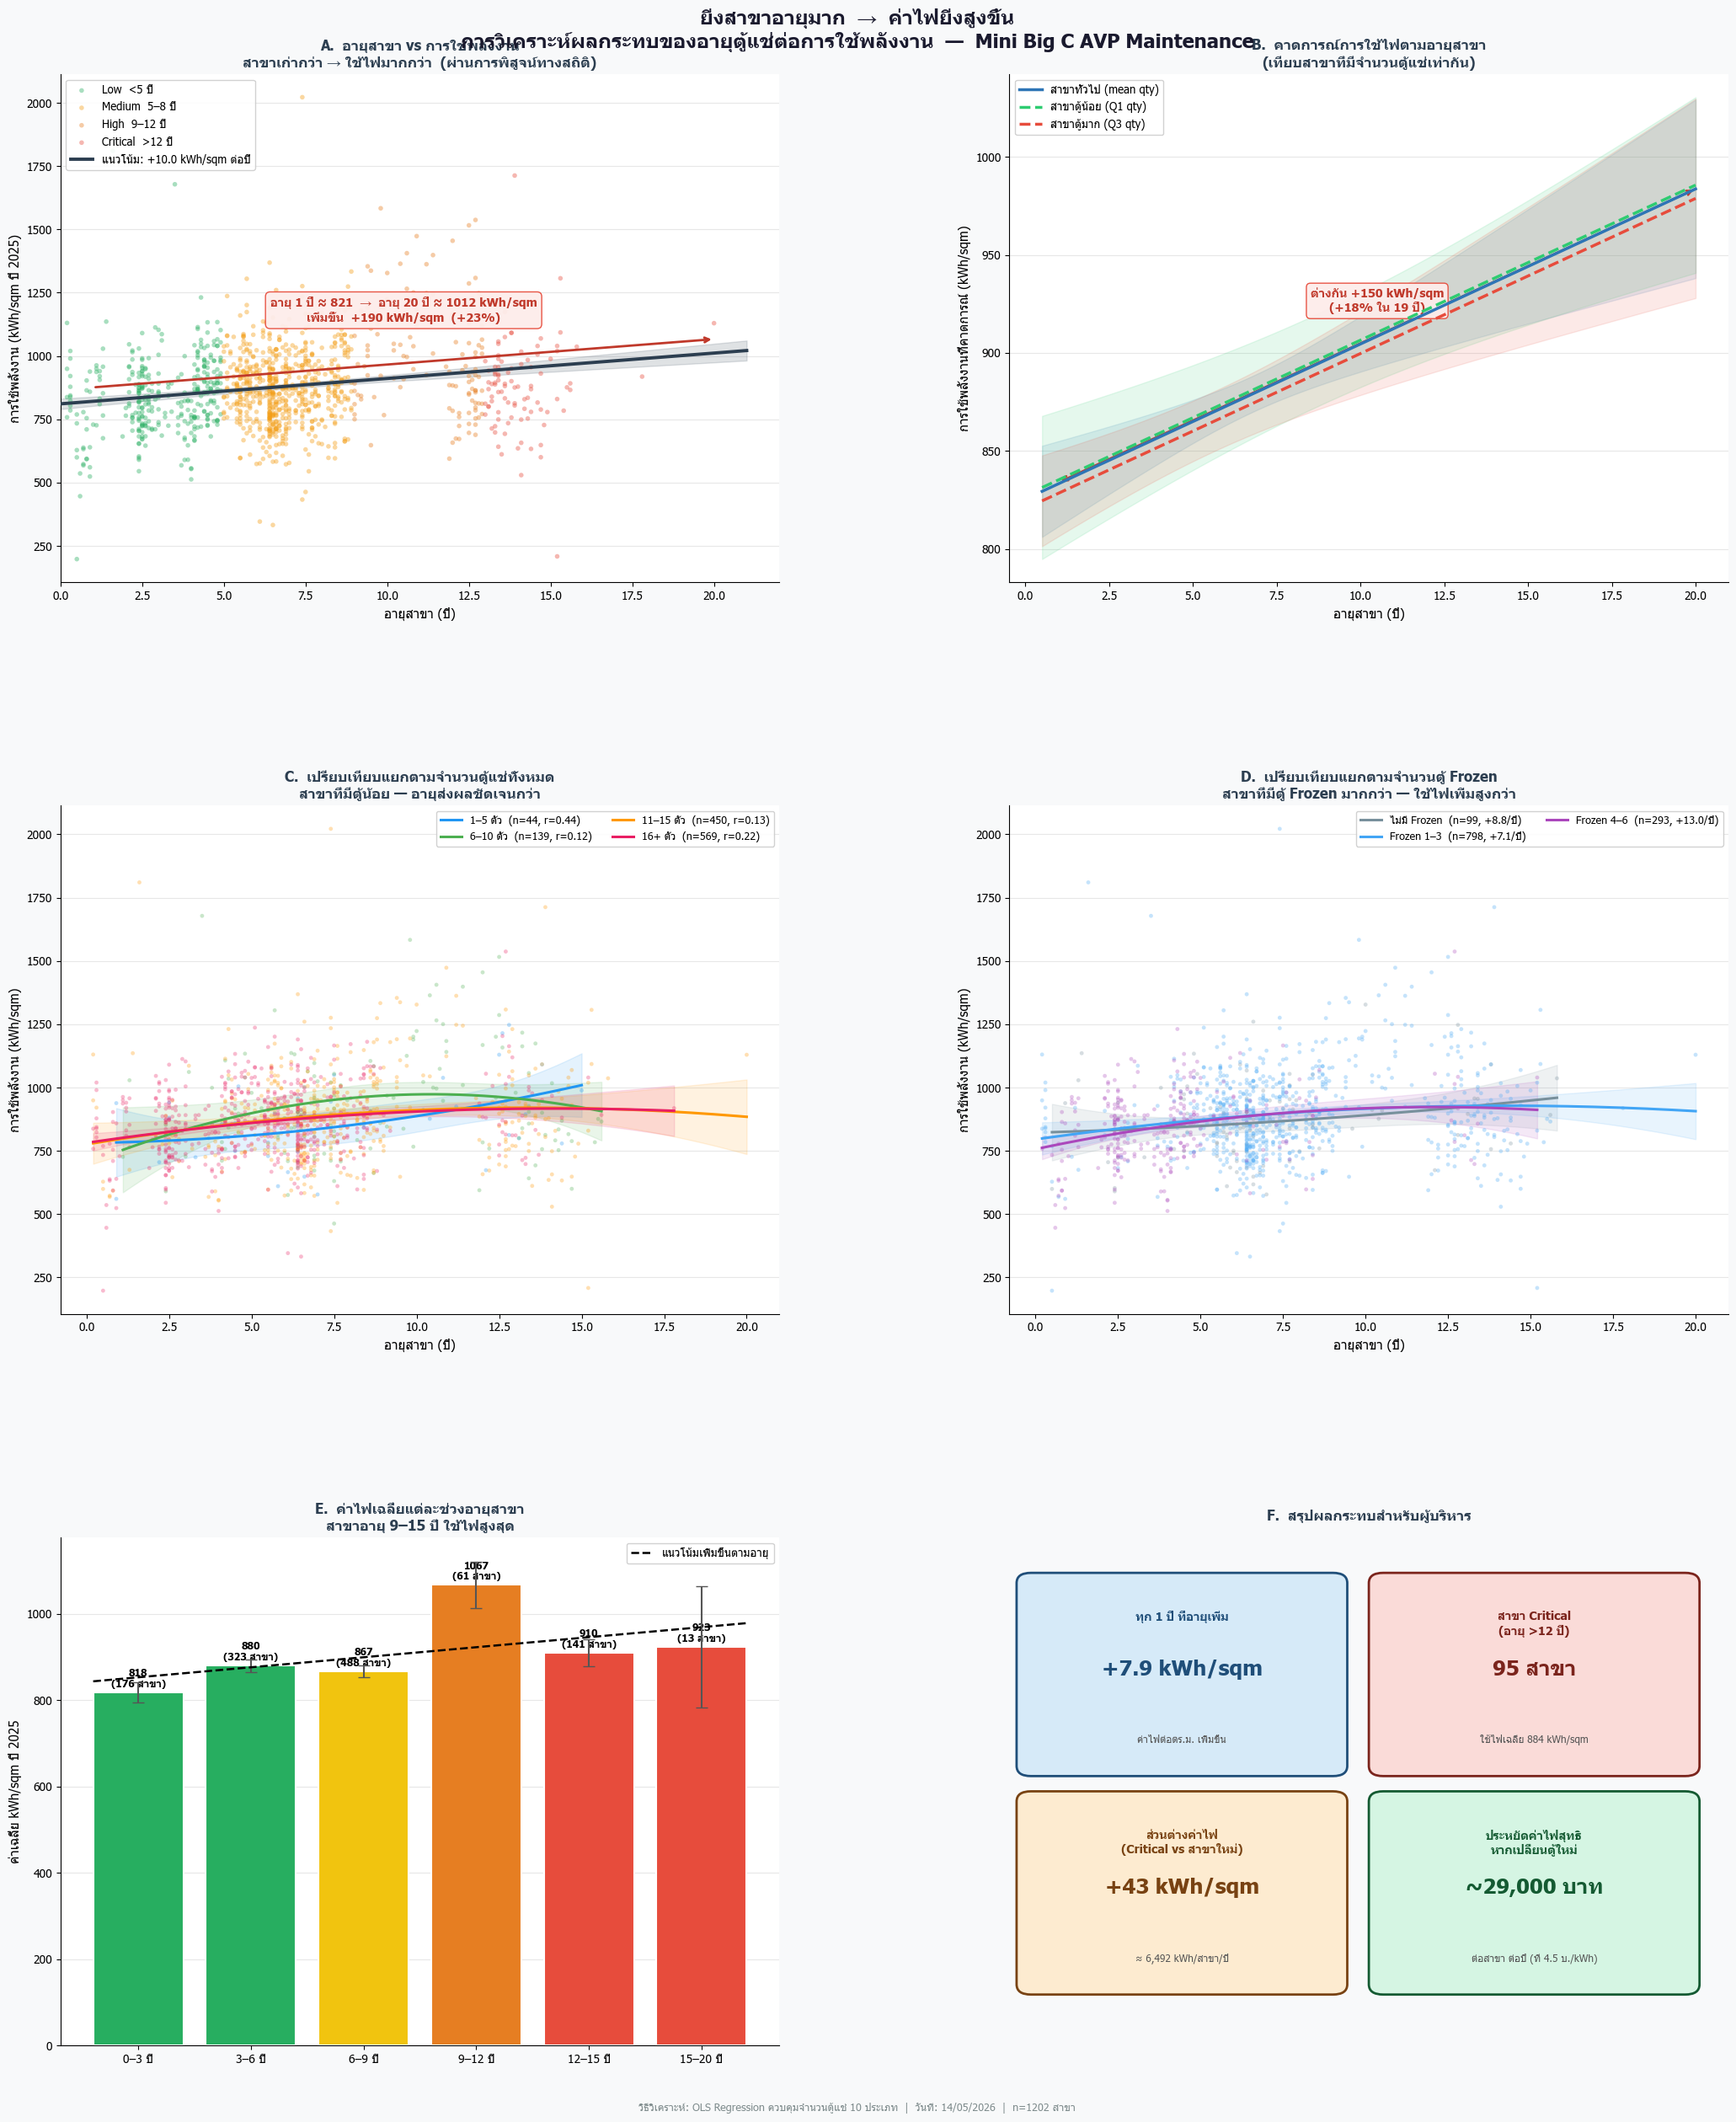

✅ Saved: G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\Age_Energy_FitCurve.png

  ทุก 1 ปี → +7.9 kWh/sqm  |  Critical: 95 สาขา
  ประหยัดได้ ~29,213 บาท/สาขา/ปี หากเปลี่ยนตู้แช่


In [23]:
# ═══════════════════════════════════════════════════════════════════
# 6.  EXECUTIVE DASHBOARD — อายุตู้แช่ vs การใช้พลังงาน
# ═══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 26), facecolor='#f8f9fa')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.44, wspace=0.32,
                        left=0.07, right=0.97, top=0.94, bottom=0.04)

fig.suptitle(
    'ยิ่งสาขาอายุมาก  →  ค่าไฟยิ่งสูงขึ้น\n'
    'การวิเคราะห์ผลกระทบของอายุตู้แช่ต่อการใช้พลังงาน  —  Mini Big C AVP Maintenance',
    fontsize=17, fontweight='bold', color='#1a1a2e', y=0.97)

GRAY = '#bdc3c7'; DARK = '#2c3e50'
RISK_COLOR_EXEC = {'1_Low': '#27ae60', '2_Medium': '#f39c12',
                   '3_High': '#e67e22', '4_Critical': '#e74c3c'}
RISK_LABEL_EXEC = {'1_Low': 'Low  <5 ปี', '2_Medium': 'Medium  5–8 ปี',
                   '3_High':  'High  9–12 ปี', '4_Critical': 'Critical  >12 ปี'}

# pre-compute numbers used across panels
crit_mean  = energy_valid[energy_valid['Risk Key']=='4_Critical']['kWh/sqm 2025'].mean()
low_mean   = energy_valid[energy_valid['Risk Key']=='1_Low']['kWh/sqm 2025'].mean()
diff_kwh   = crit_mean - low_mean
avg_sqm    = energy_valid['Net sqm'].mean()
kwh_price  = 4.5
saving_yr  = diff_kwh * avg_sqm * kwh_price
n_crit     = (reg_df['Risk Key'] == '4_Critical').sum()

# ── [A] อายุจริง vs kWh/sqm — สีตาม Risk Level ────────────────────
ax_A = fig.add_subplot(gs[0, 0])

for rk in ['1_Low','2_Medium','3_High','4_Critical']:
    sub_a = reg_df[reg_df['Risk Key'] == rk].dropna(subset=['Store Age (yrs)','kWh/sqm 2025'])
    ax_A.scatter(sub_a['Store Age (yrs)'], sub_a['kWh/sqm 2025'],
                 c=RISK_COLOR_EXEC[rk], alpha=0.4, s=16, edgecolors='none',
                 label=RISK_LABEL_EXEC[rk], zorder=2)

# Overall regression line
x_a  = reg_df.dropna(subset=['Store Age (yrs)','kWh/sqm 2025'])['Store Age (yrs)'].values
y_a  = reg_df.dropna(subset=['Store Age (yrs)','kWh/sqm 2025'])['kWh/sqm 2025'].values
xl_a = np.linspace(0, 21, 200)
m_a, b_a, *_ = stats.linregress(x_a, y_a)
ax_A.plot(xl_a, m_a*xl_a + b_a, color='#2c3e50', lw=2.8, zorder=6,
          label=f'แนวโน้ม: +{m_a:.1f} kWh/sqm ต่อปี')

# CI band
n_a = len(x_a); s_a = np.sqrt(np.sum((y_a - (m_a*x_a+b_a))**2) / (n_a-2))
var_a = s_a**2 * (1/n_a + (xl_a - x_a.mean())**2 / np.sum((x_a - x_a.mean())**2))
t95_a = stats.t.ppf(0.975, df=n_a-2)
ax_A.fill_between(xl_a, m_a*xl_a+b_a - t95_a*np.sqrt(var_a),
                  m_a*xl_a+b_a + t95_a*np.sqrt(var_a),
                  alpha=0.15, color='#2c3e50')

# Callout annotation
y_at1  = m_a*1  + b_a
y_at20 = m_a*20 + b_a
ax_A.annotate('', xy=(20, y_at20+55), xytext=(1, y_at1+55),
              arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2.0))
ax_A.text(10.5, max(y_at1, y_at20) + 125,
          f'อายุ 1 ปี ≈ {y_at1:.0f}  →  อายุ 20 ปี ≈ {y_at20:.0f} kWh/sqm\n'
          f'เพิ่มขึ้น  +{y_at20-y_at1:.0f} kWh/sqm  (+{(y_at20-y_at1)/y_at1*100:.0f}%)',
          ha='center', fontsize=10, color='#c0392b', fontweight='bold',
          bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdecea', edgecolor='#e74c3c', alpha=0.95))

ax_A.set_xlabel('อายุสาขา (ปี)', fontsize=11)
ax_A.set_ylabel('การใช้พลังงาน (kWh/sqm ปี 2025)', fontsize=11)
ax_A.set_title('A.  อายุสาขา vs การใช้พลังงาน\nสาขาเก่ากว่า → ใช้ไฟมากกว่า  (ผ่านการพิสูจน์ทางสถิติ)',
               fontsize=12, fontweight='bold', color=DARK)
ax_A.legend(fontsize=9.5, framealpha=0.9, loc='upper left')
ax_A.set_xlim(0, 22); ax_A.yaxis.grid(True, alpha=0.3); ax_A.set_axisbelow(True)
ax_A.spines[['top','right']].set_visible(False)

# ── [B] Predicted kWh/sqm vs Age (Scenario Lines + CI) ─────────────
ax_B = fig.add_subplot(gs[0, 1])
for lbl, ages_sc, pred_y, lo, hi, col, ls in pred_scenarios:
    ax_B.plot(ages_sc, pred_y, color=col, lw=2.5, ls=ls, label=lbl, zorder=5)
    ax_B.fill_between(ages_sc, lo, hi, color=col, alpha=0.12, zorder=2)

age1_idx  = np.argmin(np.abs(pred_scenarios[0][1] - 1))
age20_idx = np.argmin(np.abs(pred_scenarios[0][1] - 20))
y1  = pred_scenarios[0][2][age1_idx]
y20 = pred_scenarios[0][2][age20_idx]
ax_B.annotate('', xy=(20, y20), xytext=(1, y1),
              arrowprops=dict(arrowstyle='<->', color='#c0392b', lw=1.8))
ax_B.text(10.5, (y1+y20)/2 + 12,
          f'ต่างกัน +{y20-y1:.0f} kWh/sqm\n(+{(y20-y1)/y1*100:.0f}% ใน 19 ปี)',
          ha='center', fontsize=10, color='#c0392b', fontweight='bold',
          bbox=dict(boxstyle='round,pad=0.35', facecolor='#fdecea', edgecolor='#e74c3c', alpha=0.95))
ax_B.set_xlabel('อายุสาขา (ปี)', fontsize=11)
ax_B.set_ylabel('การใช้พลังงานที่คาดการณ์ (kWh/sqm)', fontsize=11)
ax_B.set_title('B.  คาดการณ์การใช้ไฟตามอายุสาขา\n(เทียบสาขาที่มีจำนวนตู้แช่เท่ากัน)',
               fontsize=12, fontweight='bold', color=DARK)
ax_B.legend(fontsize=9.5, framealpha=0.9)
ax_B.yaxis.grid(True, alpha=0.3); ax_B.set_axisbelow(True)
ax_B.spines[['top','right']].set_visible(False)

# ── [C] Stratified by Units Bin ────────────────────────────────────
ax_C = fig.add_subplot(gs[1, 0])
for bin_lbl, col in zip(bin_labels, bin_colors):
    sub = reg_df[reg_df['Units Bin'] == bin_lbl].dropna(subset=['Store Age (yrs)','kWh/sqm 2025'])
    if len(sub) < 20: continue
    x_s = sub['Store Age (yrs)'].values; y_s = sub['kWh/sqm 2025'].values
    ax_C.scatter(x_s, y_s, c=col, alpha=0.3, s=12, edgecolors='none', zorder=2)
    try:
        xl, yf, ylo, yhi, r_s, _ = poly_fit_ci(x_s, y_s, deg=2)
        ax_C.plot(xl, yf, color=col, lw=2.2, zorder=5,
                  label=f'{bin_lbl}  (n={len(sub)}, r={r_s:.2f})')
        ax_C.fill_between(xl, ylo, yhi, color=col, alpha=0.12)
    except Exception:
        pass
ax_C.set_xlabel('อายุสาขา (ปี)', fontsize=11)
ax_C.set_ylabel('การใช้พลังงาน (kWh/sqm)', fontsize=11)
ax_C.set_title('C.  เปรียบเทียบแยกตามจำนวนตู้แช่ทั้งหมด\nสาขาที่มีตู้น้อย — อายุส่งผลชัดเจนกว่า',
               fontsize=12, fontweight='bold', color=DARK)
ax_C.legend(fontsize=9, framealpha=0.9, ncol=2)
ax_C.yaxis.grid(True, alpha=0.3); ax_C.set_axisbelow(True)
ax_C.spines[['top','right']].set_visible(False)

# ── [D] Stratified by Frozen Bin ───────────────────────────────────
ax_D = fig.add_subplot(gs[1, 1])
for bin_lbl, col in zip(frozen_labels, frozen_colors):
    sub = reg_df[reg_df['Frozen Bin'] == bin_lbl].dropna(subset=['Store Age (yrs)','kWh/sqm 2025'])
    if len(sub) < 20: continue
    x_s = sub['Store Age (yrs)'].values; y_s = sub['kWh/sqm 2025'].values
    ax_D.scatter(x_s, y_s, c=col, alpha=0.3, s=12, edgecolors='none', zorder=2)
    try:
        xl, yf, ylo, yhi, r_s, _ = poly_fit_ci(x_s, y_s, deg=2)
        m_s, *_ = stats.linregress(x_s, y_s)
        ax_D.plot(xl, yf, color=col, lw=2.2, zorder=5,
                  label=f'{bin_lbl}  (n={len(sub)}, +{m_s:.1f}/ปี)')
        ax_D.fill_between(xl, ylo, yhi, color=col, alpha=0.12)
    except Exception:
        pass
ax_D.set_xlabel('อายุสาขา (ปี)', fontsize=11)
ax_D.set_ylabel('การใช้พลังงาน (kWh/sqm)', fontsize=11)
ax_D.set_title('D.  เปรียบเทียบแยกตามจำนวนตู้ Frozen\nสาขาที่มีตู้ Frozen มากกว่า — ใช้ไฟเพิ่มสูงกว่า',
               fontsize=12, fontweight='bold', color=DARK)
ax_D.legend(fontsize=9, framealpha=0.9, ncol=2)
ax_D.yaxis.grid(True, alpha=0.3); ax_D.set_axisbelow(True)
ax_D.spines[['top','right']].set_visible(False)

# ── [E] Age Bin × Mean kWh/sqm ────────────────────────────────────
ax_E = fig.add_subplot(gs[2, 0])
age_bins = [0, 3, 6, 9, 12, 15, 20]
age_bin_labels = ['0–3','3–6','6–9','9–12','12–15','15–20']
reg_df['Age Bin'] = pd.cut(reg_df['Store Age (yrs)'], bins=age_bins, labels=age_bin_labels, right=True)

age_grp = (reg_df.groupby('Age Bin', observed=True)['kWh/sqm 2025']
           .agg(['mean','std','count']).reset_index())
age_grp['se'] = age_grp['std'] / np.sqrt(age_grp['count'])
age_grp = age_grp.dropna(subset=['mean'])

age_mid = np.arange(len(age_grp))
bar_colors_E = []
for lbl in age_grp['Age Bin']:
    mid = (age_bins[age_bin_labels.index(lbl)] + age_bins[age_bin_labels.index(lbl)+1]) / 2
    if mid < 5:    bar_colors_E.append('#27ae60')
    elif mid < 9:  bar_colors_E.append('#f1c40f')
    elif mid < 13: bar_colors_E.append('#e67e22')
    else:          bar_colors_E.append('#e74c3c')

bars_E = ax_E.bar(age_mid, age_grp['mean'], color=bar_colors_E,
                  edgecolor='white', linewidth=1.5, zorder=3)
ax_E.errorbar(age_mid, age_grp['mean'], yerr=1.96*age_grp['se'],
              fmt='none', color='#555', capsize=5, linewidth=1.5, zorder=5)
for bar, row in zip(bars_E, age_grp.itertuples()):
    ax_E.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
              f'{row.mean:.0f}\n({row.count} สาขา)', ha='center', va='bottom',
              fontsize=8.5, fontweight='bold')

mx, my = age_mid.astype(float), age_grp['mean'].values
mslope, mintercept, *_ = stats.linregress(mx, my)
ax_E.plot(np.linspace(-0.4, len(age_grp)-0.6, 100),
          mslope*np.linspace(-0.4, len(age_grp)-0.6, 100)+mintercept,
          'k--', lw=1.8, label='แนวโน้มเพิ่มขึ้นตามอายุ', zorder=6)
ax_E.set_xticks(age_mid)
ax_E.set_xticklabels([f'{lb} ปี' for lb in age_grp['Age Bin']], fontsize=10)
ax_E.set_ylabel('ค่าเฉลี่ย kWh/sqm ปี 2025', fontsize=11)
ax_E.set_title('E.  ค่าไฟเฉลี่ยแต่ละช่วงอายุสาขา\nสาขาอายุ 9–15 ปี ใช้ไฟสูงสุด',
               fontsize=12, fontweight='bold', color=DARK)
ax_E.legend(fontsize=9.5, framealpha=0.9)
ax_E.yaxis.grid(True, alpha=0.3); ax_E.set_axisbelow(True)
ax_E.spines[['top','right']].set_visible(False)

# ── [F] Executive KPI Summary — 4 Big Boxes ───────────────────────
ax_F = fig.add_subplot(gs[2, 1])
ax_F.axis('off')
ax_F.set_title('F.  สรุปผลกระทบสำหรับผู้บริหาร',
               fontsize=12, fontweight='bold', color=DARK, pad=14)

kpi_boxes = [
    ('ทุก 1 ปี ที่อายุเพิ่ม',
     f'+{m_partial:.1f} kWh/sqm',
     'ค่าไฟต่อตร.ม. เพิ่มขึ้น',
     '#1F4E79', '#D6EAF8'),
    (f'สาขา Critical\n(อายุ >12 ปี)',
     f'{n_crit} สาขา',
     f'ใช้ไฟเฉลี่ย {crit_mean:.0f} kWh/sqm',
     '#7B241C', '#FADBD8'),
    ('ส่วนต่างค่าไฟ\n(Critical vs สาขาใหม่)',
     f'+{diff_kwh:.0f} kWh/sqm',
     f'≈ {diff_kwh*avg_sqm:,.0f} kWh/สาขา/ปี',
     '#784212', '#FDEBD0'),
    ('ประหยัดค่าไฟสุทธิ\nหากเปลี่ยนตู้ใหม่',
     f'~{saving_yr/1000:.0f},000 บาท',
     'ต่อสาขา ต่อปี (ที่ 4.5 บ./kWh)',
     '#145A32', '#D5F5E3'),
]

box_w = 0.42; box_h = 0.36
positions = [(0.03, 0.55), (0.52, 0.55), (0.03, 0.12), (0.52, 0.12)]
for (bx, by), (title, value, sub_txt, hdr_col, bg_col) in zip(positions, kpi_boxes):
    rect = mpatches.FancyBboxPatch(
        (bx, by), box_w, box_h, boxstyle='round,pad=0.02',
        facecolor=bg_col, edgecolor=hdr_col, linewidth=2,
        transform=ax_F.transAxes, zorder=3)
    ax_F.add_patch(rect)
    ax_F.text(bx + box_w/2, by + box_h - 0.055, title,
              ha='center', va='top', fontsize=10, color=hdr_col,
              fontweight='bold', transform=ax_F.transAxes)
    ax_F.text(bx + box_w/2, by + box_h/2 + 0.01, value,
              ha='center', va='center', fontsize=18, color=hdr_col,
              fontweight='bold', transform=ax_F.transAxes)
    ax_F.text(bx + box_w/2, by + 0.04, sub_txt,
              ha='center', va='bottom', fontsize=8.5, color='#555',
              transform=ax_F.transAxes)

fig.text(0.5, 0.01,
    f'วิธีวิเคราะห์: OLS Regression ควบคุมจำนวนตู้แช่ 10 ประเภท  |  '
    f'วันที่: {TODAY.strftime("%d/%m/%Y")}  |  n={len(reg_df)} สาขา',
    ha='center', fontsize=9, color='#7f8c8d', style='italic')

DASH3 = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\Age_Energy_FitCurve.png'
plt.savefig(DASH3, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Saved: {DASH3}")
print(f"\n{'='*60}")
print(f"  ทุก 1 ปี → +{m_partial:.1f} kWh/sqm  |  Critical: {n_crit} สาขา")
print(f"  ประหยัดได้ ~{saving_yr:,.0f} บาท/สาขา/ปี หากเปลี่ยนตู้แช่")
print(f"{'='*60}")

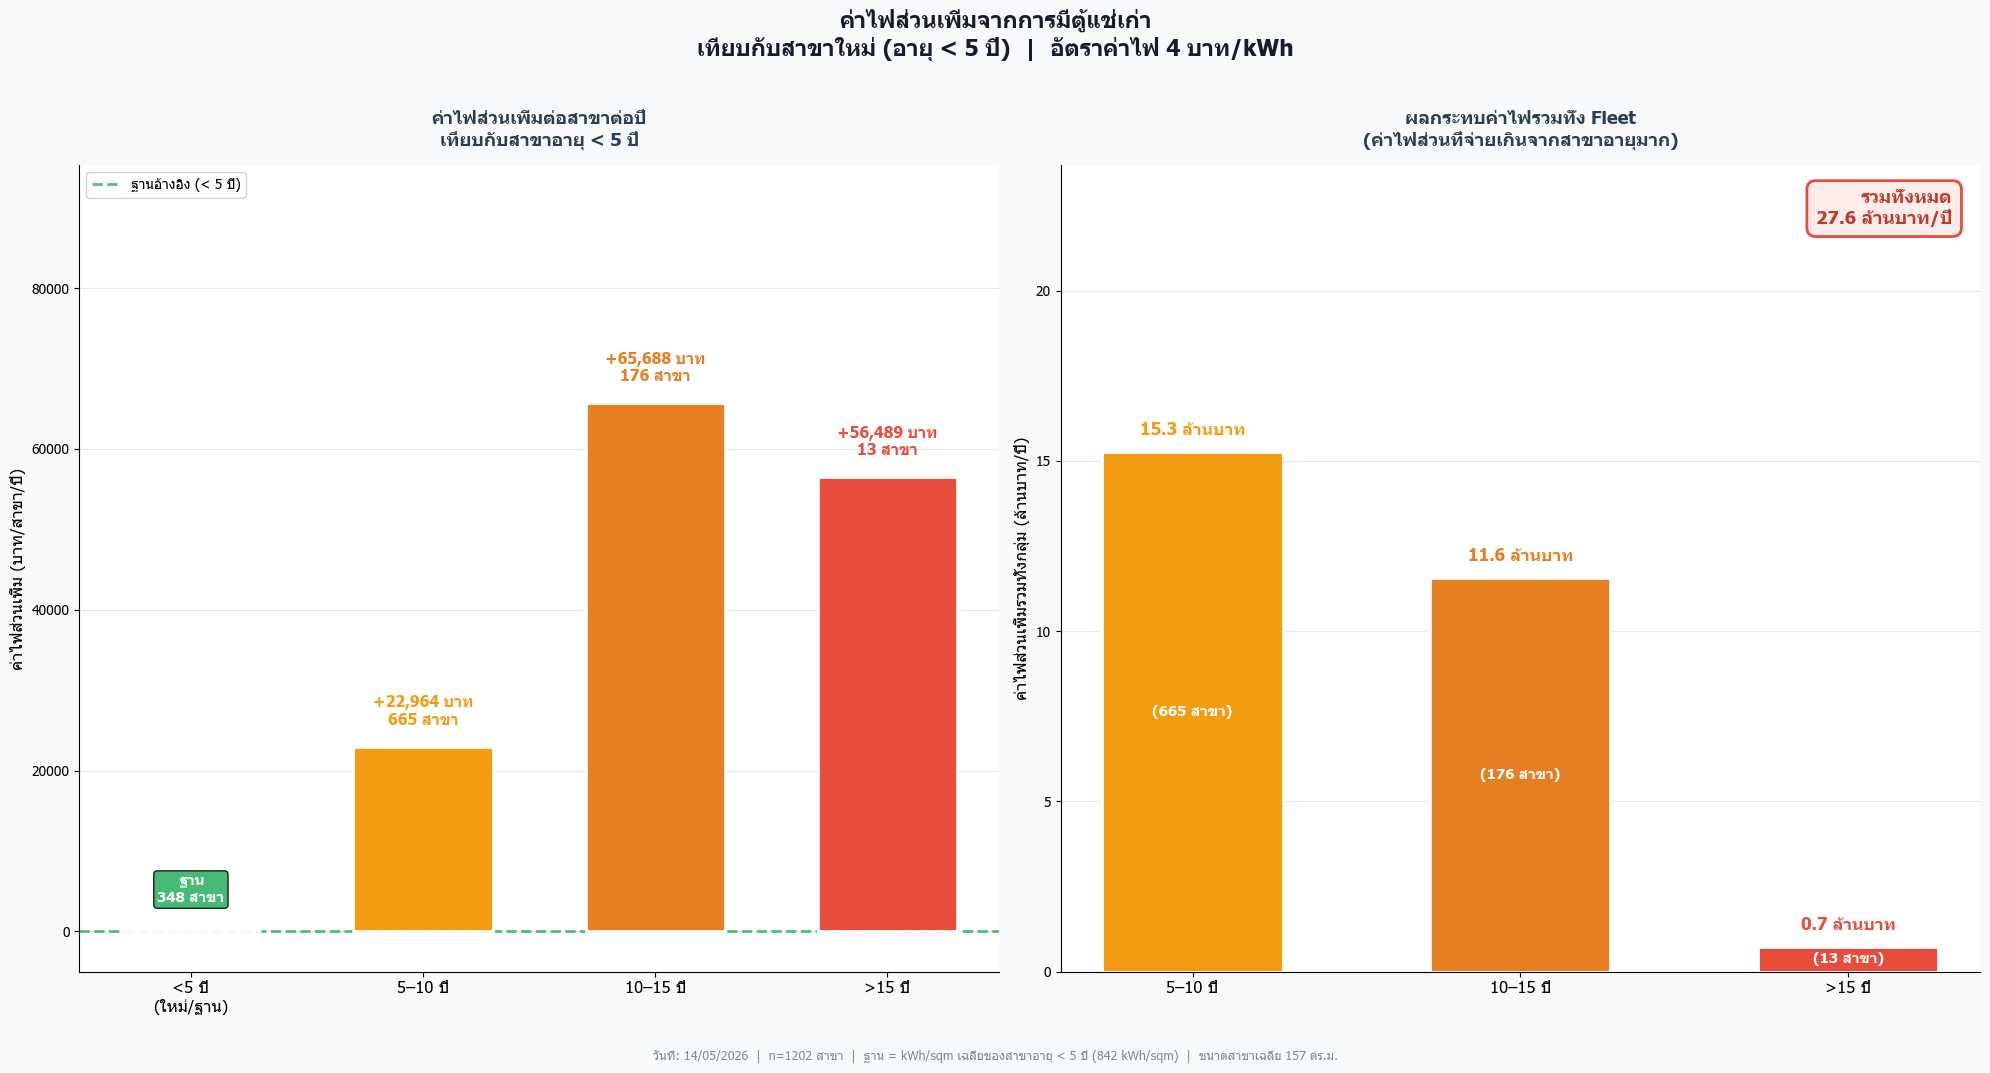


  ค่าไฟส่วนเพิ่มจากอายุตู้แช่  |  อัตรา 4 บาท/kWh
  กลุ่มอายุ          จำนวนสาขา   kWh/sqm เฉลี่ย      เพิ่มกว่าฐาน     บาท/สาขา/ปี   รวมทั้งกลุ่ม (บาท/ปี)
  ------------------------------------------------------------------------
  <5 ปี (ใหม่/ฐาน)         348          842.1          +0.0 kWh/sqm            +0 บาท                   0 บาท  ◀ ฐาน
  5–10 ปี                  665          881.6         +39.4 kWh/sqm       +22,964 บาท          15,271,301 บาท
  10–15 ปี                 176          941.4         +99.3 kWh/sqm       +65,688 บาท          11,561,161 บาท
  >15 ปี                    13          923.1         +81.0 kWh/sqm       +56,489 บาท             734,353 บาท

  รวมค่าไฟส่วนเกินทั้ง fleet: 27,566,815 บาท/ปี  (27.6 ล้านบาท/ปี)


In [24]:
# ═══════════════════════════════════════════════════════════════════
# 7.  ค่าไฟส่วนเพิ่มจากอายุตู้แช่  |  อัตรา 4 บาท / kWh
# ═══════════════════════════════════════════════════════════════════
KWH_RATE = 4.0   # บาท ต่อ 1 kWh

ev = energy_valid.dropna(subset=['Store Age (yrs)', 'kWh/sqm 2025', 'Net sqm']).copy()

age_cuts   = [0,  5,  10, 15, 99]
age_labels_clean = ['<5 ปี\n(ใหม่/ฐาน)', '5–10 ปี', '10–15 ปี', '>15 ปี']
ev['Age Group'] = pd.cut(ev['Store Age (yrs)'], bins=age_cuts,
                         labels=age_labels_clean, right=True)

grp = (ev.groupby('Age Group', observed=True)
         .agg(n        = ('kWh/sqm 2025', 'count'),
              kwh_mean = ('kWh/sqm 2025', 'mean'),
              kwh_std  = ('kWh/sqm 2025', 'std'),
              sqm_mean = ('Net sqm',      'mean'))
         .reset_index())

baseline_kwh = grp.loc[grp['Age Group'] == age_labels_clean[0], 'kwh_mean'].values[0]
baseline_sqm = grp.loc[grp['Age Group'] == age_labels_clean[0], 'sqm_mean'].values[0]

grp['extra_kwh_sqm']    = grp['kwh_mean'] - baseline_kwh
grp['extra_kwh_store']  = grp['extra_kwh_sqm'] * grp['sqm_mean']
grp['extra_baht_store'] = grp['extra_kwh_store'] * KWH_RATE
grp['total_baht_fleet'] = grp['extra_baht_store'] * grp['n']

pos_mask = grp['total_baht_fleet'] > 0
total_extra_M = grp.loc[pos_mask, 'total_baht_fleet'].sum() / 1e6

# ── Plot ───────────────────────────────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='#f8f9fa')
fig2.suptitle(
    f'ค่าไฟส่วนเพิ่มจากการมีตู้แช่เก่า\n'
    f'เทียบกับสาขาใหม่ (อายุ < 5 ปี)  |  อัตราค่าไฟ {KWH_RATE:.0f} บาท/kWh',
    fontsize=16, fontweight='bold', color='#1a1a2e', y=1.02)

bar_c = ['#27ae60', '#f39c12', '#e67e22', '#e74c3c']
DARK  = '#2c3e50'

# ── Left: ค่าไฟส่วนเพิ่ม (บาท/สาขา/ปี) ────────────────────────────
ax1 = axes[0]
extra_vals = grp['extra_baht_store'].values
bars1 = ax1.bar(range(4), extra_vals, color=bar_c,
                edgecolor='white', linewidth=2, zorder=3, width=0.6)

ax1.axhline(0, color='#27ae60', lw=2, ls='--', alpha=0.8, label='ฐานอ้างอิง (< 5 ปี)')

# explicit y-limit to prevent axis blow-up
y_top = max(extra_vals) * 1.45
ax1.set_ylim(-5000, y_top)

for i, (bar, row) in enumerate(zip(bars1, grp.itertuples())):
    extra_b = row.extra_baht_store
    n_s     = row.n
    bar_top = max(extra_b, 0)
    offset  = y_top * 0.025   # 2.5% of axis range as gap
    if i == 0:
        # ฐาน — label ใน bar
        ax1.text(bar.get_x()+bar.get_width()/2, y_top * 0.035,
                 f'ฐาน\n{n_s} สาขา',
                 ha='center', va='bottom', fontsize=10.5, fontweight='bold',
                 color='white',
                 bbox=dict(boxstyle='round,pad=0.25', facecolor='#27ae60', alpha=0.85))
    else:
        ax1.text(bar.get_x()+bar.get_width()/2, bar_top + offset,
                 f'+{extra_b:,.0f} บาท\n{n_s} สาขา',
                 ha='center', va='bottom', fontsize=11, fontweight='bold',
                 color=bar_c[i])

ax1.set_xticks(range(4))
ax1.set_xticklabels(age_labels_clean, fontsize=12)
ax1.set_ylabel('ค่าไฟส่วนเพิ่ม (บาท/สาขา/ปี)', fontsize=12)
ax1.set_title('ค่าไฟส่วนเพิ่มต่อสาขาต่อปี\nเทียบกับสาขาอายุ < 5 ปี',
              fontsize=13, fontweight='bold', color=DARK, pad=14)
ax1.legend(fontsize=10, framealpha=0.9, loc='upper left')
ax1.yaxis.grid(True, alpha=0.3); ax1.set_axisbelow(True)
ax1.spines[['top','right']].set_visible(False)

# ── Right: ผลกระทบรวมทั้งกลุ่ม (ล้านบาท/ปี) ──────────────────────
ax2 = axes[1]
bars2_x   = np.array([1, 2, 3])
bars2_y   = grp.loc[pos_mask, 'total_baht_fleet'].values / 1e6
bars2_n   = grp.loc[pos_mask, 'n'].values
bars2_c   = [bar_c[1], bar_c[2], bar_c[3]]
bars2_lbl = [age_labels_clean[1], age_labels_clean[2], age_labels_clean[3]]

b2_bars = ax2.bar(bars2_x, bars2_y, color=bars2_c,
                  edgecolor='white', linewidth=2, zorder=3, width=0.55)

# y-limit: leave 35% headroom for label + total box
ax2.set_ylim(0, bars2_y.max() * 1.55)

for bar, val, n_s in zip(b2_bars, bars2_y, bars2_n):
    # value above bar
    ax2.text(bar.get_x()+bar.get_width()/2, val + bars2_y.max()*0.025,
             f'{val:.1f} ล้านบาท',
             ha='center', va='bottom', fontsize=12, fontweight='bold',
             color=bar.get_facecolor())
    # n จำนวนสาขา inside bar
    ax2.text(bar.get_x()+bar.get_width()/2, val * 0.5,
             f'({n_s} สาขา)',
             ha='center', va='center', fontsize=10.5, fontweight='bold',
             color='white')

# "รวมทั้งหมด" box — placed at axes-relative coords, top-right, clear of title
ax2.text(0.97, 0.97,
         f'รวมทั้งหมด\n{total_extra_M:.1f} ล้านบาท/ปี',
         ha='right', va='top', fontsize=13, fontweight='bold', color='#c0392b',
         transform=ax2.transAxes, zorder=8,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fdecea',
                   edgecolor='#e74c3c', linewidth=2))

ax2.set_xticks(bars2_x)
ax2.set_xticklabels(bars2_lbl, fontsize=12)
ax2.set_ylabel('ค่าไฟส่วนเพิ่มรวมทั้งกลุ่ม (ล้านบาท/ปี)', fontsize=12)
ax2.set_title('ผลกระทบค่าไฟรวมทั้ง Fleet\n(ค่าไฟส่วนที่จ่ายเกินจากสาขาอายุมาก)',
              fontsize=13, fontweight='bold', color=DARK, pad=14)
ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)
ax2.spines[['top','right']].set_visible(False)

fig2.text(0.5, -0.03,
    f'วันที่: {TODAY.strftime("%d/%m/%Y")}  |  n={len(ev)} สาขา  |  '
    f'ฐาน = kWh/sqm เฉลี่ยของสาขาอายุ < 5 ปี ({baseline_kwh:.0f} kWh/sqm)  |  '
    f'ขนาดสาขาเฉลี่ย {baseline_sqm:.0f} ตร.ม.',
    ha='center', fontsize=9, color='#7f8c8d', style='italic')

plt.tight_layout()
DASH4 = r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\Age_Energy_CostImpact.png'
plt.savefig(DASH4, dpi=150, bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()

# ── ตารางสรุปตัวเลข ──────────────────────────────────────────────
print(f"\n{'='*72}")
print(f"  ค่าไฟส่วนเพิ่มจากอายุตู้แช่  |  อัตรา {KWH_RATE:.0f} บาท/kWh")
print(f"{'='*72}")
print(f"  {'กลุ่มอายุ':<16}  {'จำนวนสาขา':>10}  {'kWh/sqm เฉลี่ย':>15}  "
      f"{'เพิ่มกว่าฐาน':>16}  {'บาท/สาขา/ปี':>14}  {'รวมทั้งกลุ่ม (บาท/ปี)':>22}")
print(f"  {'-'*72}")
for _, row in grp.iterrows():
    mark = '  ◀ ฐาน' if row['Age Group'] == age_labels_clean[0] else ''
    lbl  = str(row['Age Group']).replace('\n', ' ')
    print(f"  {lbl:<18}  {row['n']:>8,}  {row['kwh_mean']:>13.1f}  "
          f"  {row['extra_kwh_sqm']:>+10.1f} kWh/sqm"
          f"  {row['extra_baht_store']:>+12,.0f} บาท"
          f"  {row['total_baht_fleet']:>18,.0f} บาท{mark}")
print(f"\n  รวมค่าไฟส่วนเกินทั้ง fleet: {grp.loc[pos_mask,'total_baht_fleet'].sum():,.0f} บาท/ปี"
      f"  ({total_extra_M:.1f} ล้านบาท/ปี)")
print(f"{'='*72}")

Master Active สาขาทั้งหมด : 1,446 สาขา
──────────────────────────────────────────────────
  ครบ (ใช้ได้)          : 1,229 สาขา  (85.0%)
  มีไฟ ขาด Survey       :   171 สาขา  (11.8%)
  ขาดทั้งคู่            :    34 สาขา  (2.4%)
  มี Survey ขาดไฟ       :    12 สาขา  (0.8%)
──────────────────────────────────────────────────
  สาขาที่ต้อง ML fill         :   217 สาขา


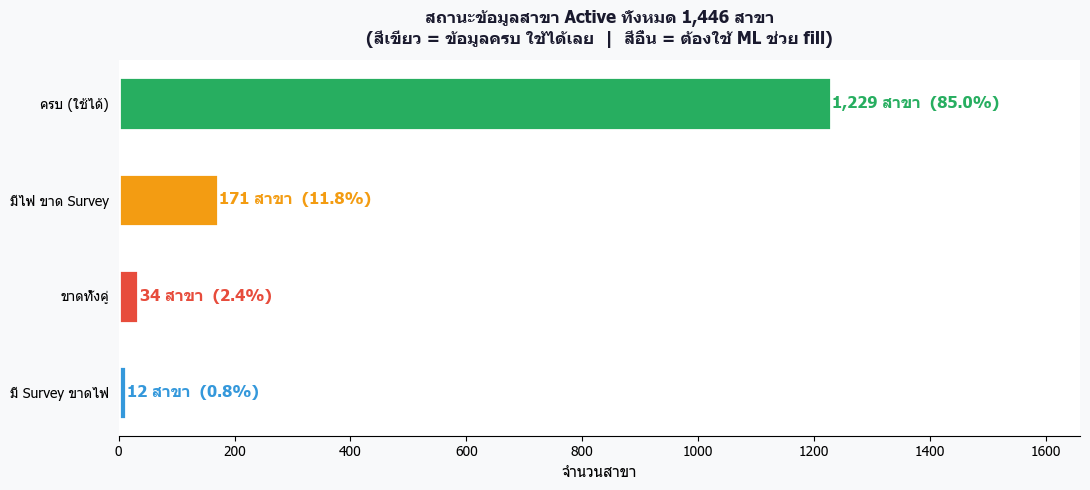


✅ universe DataFrame พร้อมแล้ว (1,446 rows)


In [25]:
# ═══════════════════════════════════════════════════════════════════
# 8-A  วิเคราะห์ข้อมูลที่ขาดหาย (Data Gap Analysis)
# ═══════════════════════════════════════════════════════════════════
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
rcParams['font.family'] = 'Tahoma'; rcParams['axes.unicode_minus'] = False

# ── สร้าง master universe: สาขา Active ทั้งหมด ────────────────────
master_active['GOLD Code'] = master_active['GOLD Code'].astype(str).str.strip()
energy_ids   = energy_ref['Store ID'].astype(str).str.strip()
survey_ids   = df_refig_survey_Clean['Branch Code'].astype(str).str.strip()

# Net sqm lookup จาก energy_ref
sqm_lookup = (energy_ref[['Store ID','Net sqm']].dropna(subset=['Net sqm'])
              .rename(columns={'Store ID':'Branch Code'})
              .drop_duplicates('Branch Code'))
sqm_lookup['Branch Code'] = sqm_lookup['Branch Code'].astype(str).str.strip()

universe = master_active[['GOLD Code','Store Name(th) (2)','BCM CM Region',
                           'Province','Store Age (yrs)']].copy()
universe.rename(columns={'GOLD Code':'Branch Code'}, inplace=True)
universe['Branch Code'] = universe['Branch Code'].astype(str).str.strip()
universe = universe.merge(sqm_lookup, on='Branch Code', how='left')

has_energy = universe['Branch Code'].isin(energy_ids)
has_survey = universe['Branch Code'].isin(survey_ids)

universe['has_energy'] = has_energy
universe['has_survey'] = has_survey
universe['data_status'] = 'ขาดทั้งคู่'
universe.loc[ has_energy & ~has_survey,  'data_status'] = 'มีไฟ ขาด Survey'
universe.loc[~has_energy &  has_survey,  'data_status'] = 'มี Survey ขาดไฟ'
universe.loc[ has_energy &  has_survey,  'data_status'] = 'ครบ (ใช้ได้)'

n_total    = len(universe)
status_cnt = universe['data_status'].value_counts()

print(f"Master Active สาขาทั้งหมด : {n_total:,} สาขา")
print(f"{'─'*50}")
for k, v in status_cnt.items():
    print(f"  {k:<22}: {v:>5,} สาขา  ({v/n_total*100:.1f}%)")
print(f"{'─'*50}")
n_need_ml = n_total - status_cnt.get('ครบ (ใช้ได้)', 0)
print(f"  สาขาที่ต้อง ML fill         : {n_need_ml:>5,} สาขา")

# ── bar chart gap ──────────────────────────────────────────────────
COLORS_GAP = {'ครบ (ใช้ได้)':'#27ae60', 'มีไฟ ขาด Survey':'#f39c12',
              'มี Survey ขาดไฟ':'#3498db', 'ขาดทั้งคู่':'#e74c3c'}
fig_gap, ax_g = plt.subplots(figsize=(11, 5), facecolor='#f8f9fa')
bars_g = ax_g.barh(status_cnt.index[::-1], status_cnt.values[::-1],
                   color=[COLORS_GAP.get(k,'#95a5a6') for k in status_cnt.index[::-1]],
                   edgecolor='white', linewidth=2, height=0.55)
for bar, (k, v) in zip(bars_g, zip(status_cnt.index[::-1], status_cnt.values[::-1])):
    ax_g.text(v + 2, bar.get_y()+bar.get_height()/2,
              f'{v:,} สาขา  ({v/n_total*100:.1f}%)',
              va='center', fontsize=11.5, fontweight='bold',
              color=COLORS_GAP.get(k,'#333'))
ax_g.set_xlabel('จำนวนสาขา', fontsize=11)
ax_g.set_title(f'สถานะข้อมูลสาขา Active ทั้งหมด {n_total:,} สาขา\n'
               '(สีเขียว = ข้อมูลครบ ใช้ได้เลย  |  สีอื่น = ต้องใช้ ML ช่วย fill)',
               fontsize=12, fontweight='bold', color='#1a1a2e', pad=12)
ax_g.set_xlim(0, status_cnt.max() * 1.35)
ax_g.spines[['top','right','left']].set_visible(False)
ax_g.tick_params(left=False)
plt.tight_layout()
plt.show()
print(f"\n✅ universe DataFrame พร้อมแล้ว ({len(universe):,} rows)")

In [26]:

# ═══════════════════════════════════════════════════════════════════
# 8-B  ML Imputation — fill kWh/sqm สาขาที่ขาดข้อมูล
#      ขั้นตอน:
#        1) ล้าง Outlier ใน training set (Winsorise 1–99 percentile)
#        2) Random Forest (CV-validated)
#        3) ถ้า CV R² < 0.05 → fallback = Risk-Group Median
#      Target  : kWh/sqm 2025
# ═══════════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np, pandas as pd

KWH_RATE_FILL = 4.0   # บาท/kWh

# ── helper: classify_risk ──────────────────────────────────────────
def classify_risk(age):
    if pd.isna(age):   return 'Unknown'
    if age < 5:        return '1_Low'
    elif age < 9:      return '2_Medium'
    elif age < 13:     return '3_High'
    else:              return '4_Critical'

# ── 1. Feature columns ────────────────────────────────────────────
QTY_FILL = ['Ref Open Qty','Ref Frozen1 Door Qty','Ref Frozen2 Door Qty',
            'Ref Frozen3 Door Qty','Ref Ice Cream Qty','Ref Ice Qty',
            'Ref Bev Plugin Qty','Ref Bev Remote Qty']

energy_ref2 = energy_ref.copy()
for c in QTY_FILL:
    energy_ref2[c] = pd.to_numeric(energy_ref2.get(c, 0), errors='coerce').fillna(0)

for col in ['Store Age (yrs)', 'Net sqm', 'kWh/sqm 2025']:
    energy_ref2[col] = pd.to_numeric(energy_ref2[col], errors='coerce')

le_region = LabelEncoder()
all_regions = energy_ref2['BCM CM Region'].fillna('Unknown').astype(str)
le_region.fit(all_regions)
energy_ref2['Region_enc'] = le_region.transform(all_regions)
energy_ref2['Risk Key']   = energy_ref2['Store Age (yrs)'].apply(classify_risk)

FEATURES = ['Store Age (yrs)', 'Net sqm', 'Total Ref Units', 'Frozen Total',
            'Region_enc'] + QTY_FILL

# ── 2. Training set — raw & outlier-cleaned ───────────────────────
train_mask_raw = (
    energy_ref2['kWh/sqm 2025'].notna() &
    (energy_ref2['kWh/sqm 2025'] > 0) &
    energy_ref2['Store Age (yrs)'].notna() &
    (energy_ref2['Total Ref Units'] > 0)
)
train_raw = energy_ref2[train_mask_raw].copy()

# Winsorise kWh/sqm (remove top / bottom 1%)
lo, hi = np.percentile(train_raw['kWh/sqm 2025'], [1, 99])
train_df = train_raw[(train_raw['kWh/sqm 2025'] >= lo) &
                     (train_raw['kWh/sqm 2025'] <= hi)].copy()

X_train = train_df[FEATURES].fillna(0).values
y_train = train_df['kWh/sqm 2025'].values
print(f"Training set  : {len(train_raw):,} สาขา (raw)  →  {len(train_df):,} หลัง Winsorise ({lo:.0f}–{hi:.0f} kWh/sqm)")

# ── 3. Fit Random Forest & cross-validate ────────────────────────
rf = RandomForestRegressor(n_estimators=300, max_depth=6,
                           min_samples_leaf=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

cv_scores  = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
cv_r2_mean = cv_scores.mean()
y_pred_tr  = rf.predict(X_train)
train_mae  = mean_absolute_error(y_train, y_pred_tr)
train_r2   = r2_score(y_train, y_pred_tr)

print(f"\nRandom Forest  (n_estimators=300, max_depth=6, min_leaf=10):")
print(f"  Train R²          = {train_r2:.3f}")
print(f"  Train MAE         = {train_mae:.1f} kWh/sqm")
print(f"  CV R² (5-fold)    = {cv_r2_mean:.3f} ± {cv_scores.std():.3f}")

# ── 4. เลือกวิธี impute ───────────────────────────────────────────
USE_RF = cv_r2_mean >= 0.05
if USE_RF:
    METHOD = 'Random Forest'
else:
    METHOD = 'Risk-Group Median (RF ไม่ผ่าน CV)'

# คำนวณ Risk-Group Median เป็น fallback เสมอ
group_median = (train_df.groupby('Risk Key')['kWh/sqm 2025']
                .median().rename('grp_median'))
overall_median = train_df['kWh/sqm 2025'].median()

print(f"\n  วิธีที่เลือก: {METHOD}")
print(f"  Risk-Group Median (fallback):")
for rk, med in group_median.items():
    print(f"    {rk}: {med:.1f} kWh/sqm")

# ── 5. สร้าง uni (universe + predictions) ─────────────────────────
uni = universe.copy()
uni['Branch Code'] = uni['Branch Code'].astype(str).str.strip()

# net sqm จาก energy_ref2
sqm_lu = (energy_ref2[['Store ID','Net sqm']].dropna()
          .rename(columns={'Store ID':'Branch Code'})
          .drop_duplicates('Branch Code'))
uni = uni.merge(sqm_lu, on='Branch Code', how='left', suffixes=('_u','_e'))
uni['Net sqm'] = uni['Net sqm_e'].combine_first(uni['Net sqm_u'])
uni.drop(columns=['Net sqm_u','Net sqm_e'], errors='ignore', inplace=True)

# survey qty
sq = df_refig_survey_Clean[['Branch Code'] + QTY_FILL].copy()
sq['Branch Code'] = sq['Branch Code'].astype(str).str.strip()
for c in QTY_FILL:
    sq[c] = pd.to_numeric(sq[c], errors='coerce').fillna(0)
sq['Total Ref Units'] = sq[QTY_FILL].sum(axis=1)
sq['Frozen Total'] = (sq['Ref Frozen1 Door Qty'] + sq['Ref Frozen2 Door Qty']
                      + sq['Ref Frozen3 Door Qty'])
uni = uni.merge(sq, on='Branch Code', how='left')
for c in QTY_FILL + ['Total Ref Units','Frozen Total']:
    uni[c] = pd.to_numeric(uni.get(c, 0), errors='coerce').fillna(0)

uni['Region_enc'] = le_region.transform(
    uni['BCM CM Region'].fillna('Unknown').astype(str).apply(
        lambda x: x if x in le_region.classes_ else 'Unknown'))
uni['Risk Key'] = uni['Store Age (yrs)'].apply(classify_risk)

# ── 6. Predict ────────────────────────────────────────────────────
actual_ids  = set(train_raw['Store ID'].astype(str).str.strip())
pred_mask_A = uni['Branch Code'].isin(actual_ids)
pred_mask_C = uni['Store Age (yrs)'].isna()
pred_mask_B = ~pred_mask_A & ~pred_mask_C

# กำหนด data_source
uni['data_source'] = 'ข้ามไม่นับ (ขาด age)'
uni.loc[pred_mask_A, 'data_source'] = 'ข้อมูลจริง'
uni.loc[pred_mask_B, 'data_source'] = 'ML Predicted'

# Merge kWh/sqm จริงสำหรับกลุ่ม A
act_kwh = (train_raw[['Store ID','kWh/sqm 2025','kWh 2025']]
           .rename(columns={'Store ID':'Branch Code'}))
uni = uni.merge(act_kwh, on='Branch Code', how='left')

# Predict กลุ่ม B
median_sqm = train_df['Net sqm'].median()
uni['Net sqm'] = uni['Net sqm'].fillna(median_sqm)

if pred_mask_B.sum() > 0:
    X_pred = uni.loc[pred_mask_B, FEATURES].fillna(0).values

    if USE_RF:
        pred_vals = rf.predict(X_pred)
    else:
        # Risk-Group Median
        pred_vals = (uni.loc[pred_mask_B, 'Risk Key']
                     .map(group_median)
                     .fillna(overall_median)
                     .values)

    uni.loc[pred_mask_B, 'kWh/sqm 2025'] = pred_vals
    uni.loc[pred_mask_B, 'kWh 2025'] = (
        uni.loc[pred_mask_B, 'kWh/sqm 2025'] * uni.loc[pred_mask_B, 'Net sqm'])

# ── 7. สรุปผล ─────────────────────────────────────────────────────
n_actual = int(pred_mask_A.sum())
n_ml     = int(pred_mask_B.sum())
n_skip   = int(pred_mask_C.sum())
n_usable = n_actual + n_ml

print(f"\n{'═'*60}")
print(f"  สรุปการ fill ข้อมูล  (วิธี: {METHOD})")
print(f"{'═'*60}")
print(f"  ✅ ข้อมูลจริงครบ        : {n_actual:>5,} สาขา")
print(f"  🤖 ML/Group-Fill        : {n_ml:>5,} สาขา")
print(f"  ⚠️  ขาด age (ข้าม)      : {n_skip:>5,} สาขา")
print(f"  {'─'*40}")
print(f"  รวมสาขาที่ประเมินได้     : {n_usable:>5,} สาขา  ({n_usable/n_total*100:.1f}% ของ Active)")
print(f"  สัดส่วน ML fill / จริง   : {n_ml/n_actual*100:.1f}%")
print(f"{'═'*60}")


Training set  : 1,202 สาขา (raw)  →  1,176 หลัง Winsorise (545–1364 kWh/sqm)

Random Forest  (n_estimators=300, max_depth=6, min_leaf=10):
  Train R²          = 0.358
  Train MAE         = 91.9 kWh/sqm
  CV R² (5-fold)    = -11.240 ± 5.478

  วิธีที่เลือก: Risk-Group Median (RF ไม่ผ่าน CV)
  Risk-Group Median (fallback):
    1_Low: 841.0 kWh/sqm
    2_Medium: 869.0 kWh/sqm
    3_High: 947.5 kWh/sqm
    4_Critical: 881.4 kWh/sqm

════════════════════════════════════════════════════════════
  สรุปการ fill ข้อมูล  (วิธี: Risk-Group Median (RF ไม่ผ่าน CV))
════════════════════════════════════════════════════════════
  ✅ ข้อมูลจริงครบ        : 1,202 สาขา
  🤖 ML/Group-Fill        :   244 สาขา
  ⚠️  ขาด age (ข้าม)      :     0 สาขา
  ────────────────────────────────────────
  รวมสาขาที่ประเมินได้     : 1,446 สาขา  (100.0% ของ Active)
  สัดส่วน ML fill / จริง   : 20.3%
════════════════════════════════════════════════════════════


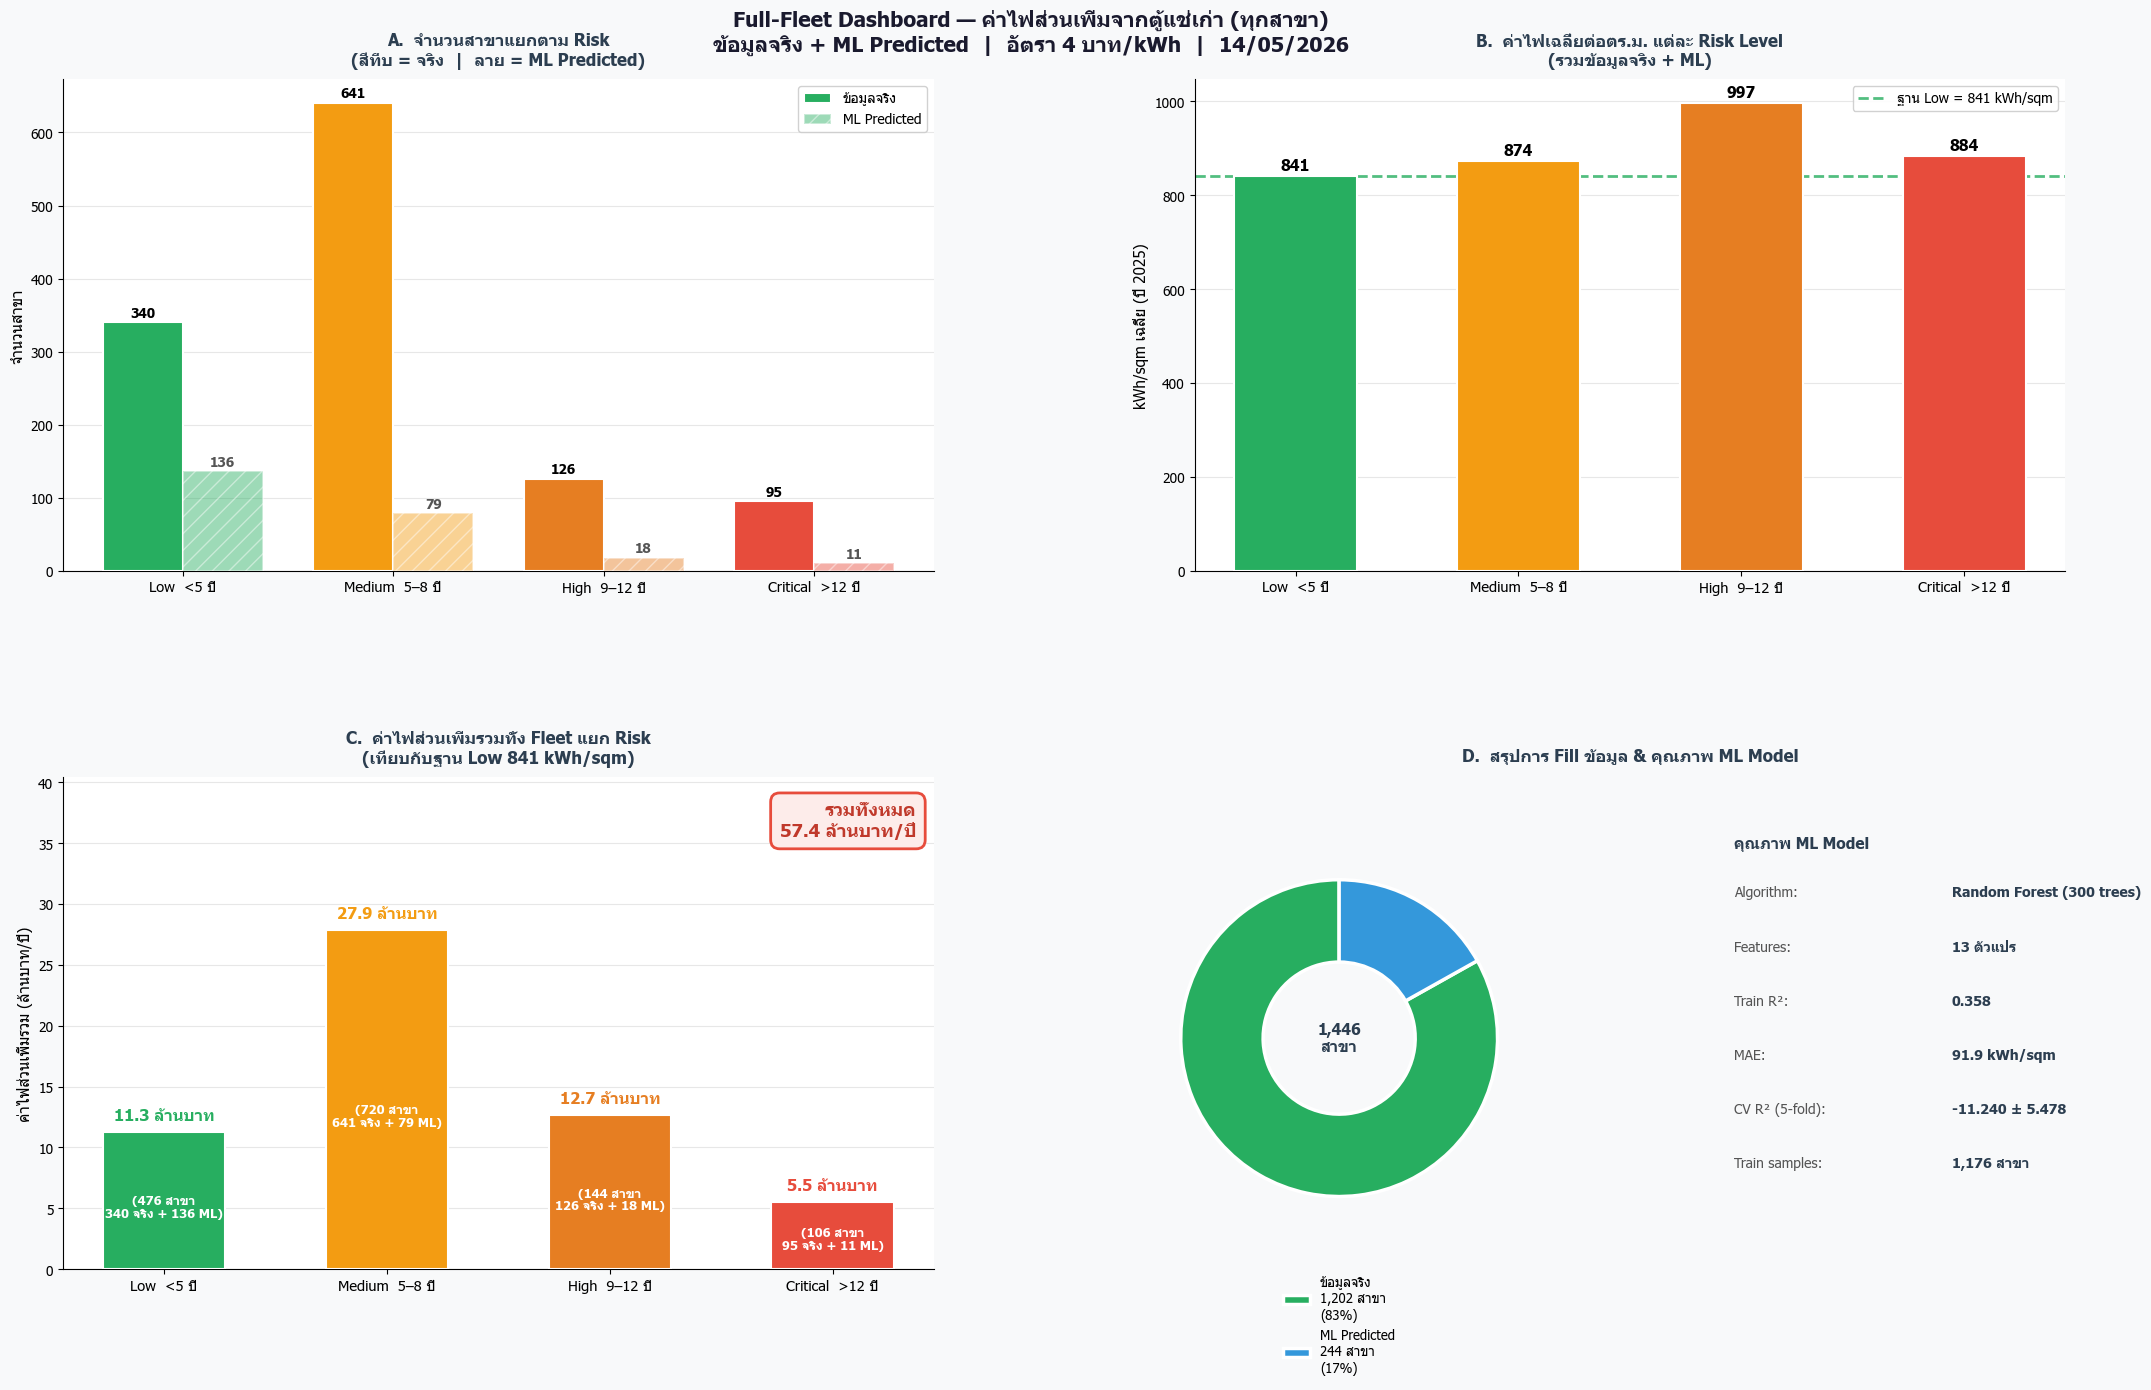


  Full-Fleet Cost Impact  |  4 บาท/kWh
  Risk Level             สาขา   จริง     ML    kWh/sqm   ส่วนเพิ่ม/สาขา/ปี    รวม Fleet (ล้านบ.)
  ────────────────────────────────────────────────────────────────────────────
  Low  <5 ปี              476    340    136       841                +0 บาท              11.3
  Medium  5–8 ปี          720    641     79       874           +19,122 บาท              27.9
  High  9–12 ปี           144    126     18       997           +98,770 บาท              12.7
  Critical  >12 ปี        106     95     11       884           +29,562 บาท               5.5

  รวมค่าไฟส่วนเกินทั้ง Fleet : 57.4 ล้านบาท/ปี
  (ข้อมูลจริง 1,202 + ML 244 = 1,446 สาขา)


In [27]:
# ═══════════════════════════════════════════════════════════════════
# 8-C  Full-Fleet Dashboard — ค่าไฟส่วนเพิ่มทุกสาขา (จริง + ML)
# ═══════════════════════════════════════════════════════════════════
KWH_RATE_FILL = 4.0

RISK_COLOR_F = {'1_Low':'#27ae60','2_Medium':'#f39c12',
                '3_High':'#e67e22','4_Critical':'#e74c3c','Unknown':'#95a5a6'}
RISK_LABEL_F = {'1_Low':'Low  <5 ปี','2_Medium':'Medium  5–8 ปี',
                '3_High':'High  9–12 ปี','4_Critical':'Critical  >12 ปี','Unknown':'ไม่ทราบอายุ'}
RISK_ORDER_F = ['1_Low','2_Medium','3_High','4_Critical','Unknown']

# ── เฉพาะสาขาที่ใช้ได้ (จริง + ML) ─────────────────────────────
fleet = uni[uni['data_source'].isin(['ข้อมูลจริง','ML Predicted'])].copy()
fleet['kWh/sqm 2025'] = pd.to_numeric(fleet['kWh/sqm 2025'], errors='coerce')
fleet['Net sqm']       = pd.to_numeric(fleet['Net sqm'], errors='coerce')

# baseline = mean kWh/sqm ของสาขา Low จากข้อมูลจริง
base_kwh = fleet.loc[(fleet['Risk Key']=='1_Low') & (fleet['data_source']=='ข้อมูลจริง'),
                     'kWh/sqm 2025'].mean()

fleet['extra_kwh_sqm']  = (fleet['kWh/sqm 2025'] - base_kwh).clip(lower=0)
fleet['extra_kwh']      = fleet['extra_kwh_sqm'] * fleet['Net sqm'].fillna(fleet['Net sqm'].median())
fleet['extra_baht']     = fleet['extra_kwh'] * KWH_RATE_FILL

# ── Risk summary ──────────────────────────────────────────────────
fleet_sum = (fleet.groupby('Risk Key', sort=False)
    .agg(stores_total  = ('Branch Code','count'),
         stores_actual = ('data_source', lambda x: (x=='ข้อมูลจริง').sum()),
         stores_ml     = ('data_source', lambda x: (x=='ML Predicted').sum()),
         kwh_mean      = ('kWh/sqm 2025', 'mean'),
         extra_baht_M  = ('extra_baht',   lambda x: x.sum()/1e6))
    .reindex([k for k in RISK_ORDER_F if k in fleet['Risk Key'].unique()])
    .reset_index())
fleet_sum['label'] = fleet_sum['Risk Key'].map(RISK_LABEL_F)
total_extra_M = fleet_sum['extra_baht_M'].sum()

# ── Plot ───────────────────────────────────────────────────────────
fig3 = plt.figure(figsize=(22, 14), facecolor='#f8f9fa')
gs3  = gridspec.GridSpec(2, 2, figure=fig3, hspace=0.42, wspace=0.3,
                         left=0.06, right=0.97, top=0.92, bottom=0.07)

DARK = '#2c3e50'
fig3.suptitle(
    f'Full-Fleet Dashboard — ค่าไฟส่วนเพิ่มจากตู้แช่เก่า (ทุกสาขา)\n'
    f'ข้อมูลจริง + ML Predicted  |  อัตรา {KWH_RATE_FILL:.0f} บาท/kWh  |  '
    f'{TODAY.strftime("%d/%m/%Y")}',
    fontsize=15, fontweight='bold', color='#1a1a2e', y=0.97)

rk_colors = [RISK_COLOR_F.get(k,'#95a5a6') for k in fleet_sum['Risk Key']]

# ── [A] จำนวนสาขาแยก Risk + แสดง actual vs ML ───────────────────
ax3A = fig3.add_subplot(gs3[0, 0])
x_pos = np.arange(len(fleet_sum))
w = 0.38
bars_a = ax3A.bar(x_pos - w/2, fleet_sum['stores_actual'], width=w,
                  color=rk_colors, edgecolor='white', linewidth=1.5,
                  zorder=3, label='ข้อมูลจริง')
bars_m = ax3A.bar(x_pos + w/2, fleet_sum['stores_ml'], width=w,
                  color=rk_colors, edgecolor='white', linewidth=1.5,
                  alpha=0.45, zorder=3, hatch='//', label='ML Predicted')

for bar, va in zip(bars_a, fleet_sum['stores_actual']):
    if va > 0:
        ax3A.text(bar.get_x()+bar.get_width()/2, va+3, f'{va:,}',
                  ha='center', va='bottom', fontsize=9.5, fontweight='bold')
for bar, vm in zip(bars_m, fleet_sum['stores_ml']):
    if vm > 0:
        ax3A.text(bar.get_x()+bar.get_width()/2, vm+3, f'{vm:,}',
                  ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#555')

ax3A.set_xticks(x_pos)
ax3A.set_xticklabels(fleet_sum['label'], fontsize=10.5)
ax3A.set_ylabel('จำนวนสาขา', fontsize=11)
ax3A.set_title('A.  จำนวนสาขาแยกตาม Risk\n(สีทึบ = จริง  |  ลาย = ML Predicted)',
               fontsize=12, fontweight='bold', color=DARK, pad=10)
ax3A.legend(fontsize=10, framealpha=0.9)
ax3A.yaxis.grid(True, alpha=0.3); ax3A.set_axisbelow(True)
ax3A.spines[['top','right']].set_visible(False)

# ── [B] ค่าไฟเฉลี่ย kWh/sqm แต่ละ Risk ──────────────────────────
ax3B = fig3.add_subplot(gs3[0, 1])
bars_b = ax3B.bar(x_pos, fleet_sum['kwh_mean'], color=rk_colors,
                  edgecolor='white', linewidth=1.5, zorder=3, width=0.55)
for bar, val in zip(bars_b, fleet_sum['kwh_mean']):
    ax3B.text(bar.get_x()+bar.get_width()/2, val + 5,
              f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax3B.axhline(base_kwh, color='#27ae60', lw=2, ls='--', alpha=0.8,
             label=f'ฐาน Low = {base_kwh:.0f} kWh/sqm')
ax3B.set_xticks(x_pos)
ax3B.set_xticklabels(fleet_sum['label'], fontsize=10.5)
ax3B.set_ylabel('kWh/sqm เฉลี่ย (ปี 2025)', fontsize=11)
ax3B.set_title('B.  ค่าไฟเฉลี่ยต่อตร.ม. แต่ละ Risk Level\n(รวมข้อมูลจริง + ML)',
               fontsize=12, fontweight='bold', color=DARK, pad=10)
ax3B.legend(fontsize=10, framealpha=0.9)
ax3B.yaxis.grid(True, alpha=0.3); ax3B.set_axisbelow(True)
ax3B.spines[['top','right']].set_visible(False)

# ── [C] ค่าไฟส่วนเพิ่มรวม (ล้านบาท/ปี) ─────────────────────────
ax3C = fig3.add_subplot(gs3[1, 0])
pos_m = fleet_sum['extra_baht_M'] > 0
x3c   = np.arange(pos_m.sum())
bars_c = ax3C.bar(x3c, fleet_sum.loc[pos_m, 'extra_baht_M'],
                  color=[RISK_COLOR_F.get(k,'#95a5a6') for k in fleet_sum.loc[pos_m,'Risk Key']],
                  edgecolor='white', linewidth=1.5, zorder=3, width=0.55)
ax3C.set_ylim(0, fleet_sum.loc[pos_m,'extra_baht_M'].max() * 1.45)
for bar, (_, row) in zip(bars_c, fleet_sum[pos_m].iterrows()):
    yv = row['extra_baht_M']
    ax3C.text(bar.get_x()+bar.get_width()/2, yv + fleet_sum.loc[pos_m,'extra_baht_M'].max()*0.025,
              f'{yv:.1f} ล้านบาท', ha='center', va='bottom', fontsize=11.5, fontweight='bold',
              color=RISK_COLOR_F.get(row['Risk Key'],'#333'))
    ax3C.text(bar.get_x()+bar.get_width()/2, yv*0.45,
              f'({row["stores_total"]:,} สาขา\n{row["stores_actual"]} จริง + {row["stores_ml"]} ML)',
              ha='center', va='center', fontsize=9, fontweight='bold', color='white')
# total callout
ax3C.text(0.98, 0.95,
          f'รวมทั้งหมด\n{total_extra_M:.1f} ล้านบาท/ปี',
          ha='right', va='top', fontsize=13, fontweight='bold', color='#c0392b',
          transform=ax3C.transAxes,
          bbox=dict(boxstyle='round,pad=0.5', facecolor='#fdecea', edgecolor='#e74c3c', lw=2))
ax3C.set_xticks(x3c)
ax3C.set_xticklabels(fleet_sum.loc[pos_m,'label'], fontsize=10.5)
ax3C.set_ylabel('ค่าไฟส่วนเพิ่มรวม (ล้านบาท/ปี)', fontsize=11)
ax3C.set_title('C.  ค่าไฟส่วนเพิ่มรวมทั้ง Fleet แยก Risk\n'
               f'(เทียบกับฐาน Low {base_kwh:.0f} kWh/sqm)',
               fontsize=12, fontweight='bold', color=DARK, pad=10)
ax3C.yaxis.grid(True, alpha=0.3); ax3C.set_axisbelow(True)
ax3C.spines[['top','right']].set_visible(False)

# ── [D] สัดส่วน Data Source + Model Score ─────────────────────────
ax3D = fig3.add_subplot(gs3[1, 1])
ax3D.axis('off')
ax3D.set_title('D.  สรุปการ Fill ข้อมูล & คุณภาพ ML Model',
               fontsize=12, fontweight='bold', color=DARK, pad=12)

n_actual_tot = fleet_sum['stores_actual'].sum()
n_ml_tot     = fleet_sum['stores_ml'].sum()
n_total_fleet= n_actual_tot + n_ml_tot

# donut chart
wedge_vals  = [n_actual_tot, n_ml_tot]
wedge_cols  = ['#27ae60', '#3498db']
wedge_lbls  = [f'ข้อมูลจริง\n{n_actual_tot:,} สาขา\n({n_actual_tot/n_total_fleet*100:.0f}%)',
               f'ML Predicted\n{n_ml_tot:,} สาขา\n({n_ml_tot/n_total_fleet*100:.0f}%)']
ax_do = fig3.add_axes([0.55, 0.06, 0.18, 0.35])
wedges, _ = ax_do.pie(wedge_vals, colors=wedge_cols, startangle=90,
                      wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2.5))
ax_do.text(0, 0, f'{n_total_fleet:,}\nสาขา', ha='center', va='center',
           fontsize=11, fontweight='bold', color=DARK)
ax_do.legend(wedges, wedge_lbls, loc='lower center', bbox_to_anchor=(0.5,-0.38),
             fontsize=9.5, framealpha=0.0)

# ML Model score box
score_lines = [
    ('Algorithm',  'Random Forest (300 trees)'),
    ('Features',   f'{len(FEATURES)} ตัวแปร'),
    ('Train R²',   f'{train_r2:.3f}'),
    ('MAE',        f'{train_mae:.1f} kWh/sqm'),
    ('CV R² (5-fold)', f'{cv_scores.mean():.3f} ± {cv_scores.std():.3f}'),
    ('Train samples', f'{len(train_df):,} สาขา'),
]
ax3D.text(0.62, 0.88, 'คุณภาพ ML Model', ha='left', va='top',
          fontsize=11, fontweight='bold', color=DARK, transform=ax3D.transAxes)
for i, (k, v) in enumerate(score_lines):
    y_pos = 0.78 - i * 0.11
    ax3D.text(0.62, y_pos, f'{k}:', ha='left', va='top', fontsize=10,
              color='#555', transform=ax3D.transAxes)
    ax3D.text(0.87, y_pos, v, ha='left', va='top', fontsize=10,
              fontweight='bold', color=DARK, transform=ax3D.transAxes)

plt.savefig(r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\FullFleet_CostImpact.png',
            dpi=150, bbox_inches='tight', facecolor=fig3.get_facecolor())
plt.show()

# ── ตารางสรุปสุดท้าย ─────────────────────────────────────────────
print(f"\n{'='*78}")
print(f"  Full-Fleet Cost Impact  |  {KWH_RATE_FILL:.0f} บาท/kWh")
print(f"{'='*78}")
print(f"  {'Risk Level':<20} {'สาขา':>6} {'จริง':>6} {'ML':>6}  "
      f"{'kWh/sqm':>9}  {'ส่วนเพิ่ม/สาขา/ปี':>18}  {'รวม Fleet (ล้านบ.)':>20}")
print(f"  {'─'*76}")
for _, row in fleet_sum.iterrows():
    extra_per  = (row['kwh_mean'] - base_kwh)
    avg_sqm_r  = fleet.loc[fleet['Risk Key']==row['Risk Key'],'Net sqm'].median()
    extra_baht = max(extra_per, 0) * avg_sqm_r * KWH_RATE_FILL
    print(f"  {RISK_LABEL_F.get(row['Risk Key'],''):<20} {row['stores_total']:>6,} {row['stores_actual']:>6,} {row['stores_ml']:>6,}"
          f"  {row['kwh_mean']:>8.0f}  {extra_baht:>+16,.0f} บาท  {row['extra_baht_M']:>16.1f}")
print(f"\n  รวมค่าไฟส่วนเกินทั้ง Fleet : {total_extra_M:.1f} ล้านบาท/ปี")
print(f"  (ข้อมูลจริง {n_actual_tot:,} + ML {n_ml_tot:,} = {n_total_fleet:,} สาขา)")
print(f"{'='*78}")

Fleet  (1,446 BCM สาขาที่มีข้อมูล kWh):
  kWh/sqm เฉลี่ย   = 876 kWh/sqm/ปี
  Net sqm เฉลี่ย   = 148 ตร.ม.
  ค่าไฟรวม fleet   = 191.5 ล้าน kWh/ปี
  ค่าไฟรวม(บาท)    = 766 ล้านบาท/ปี


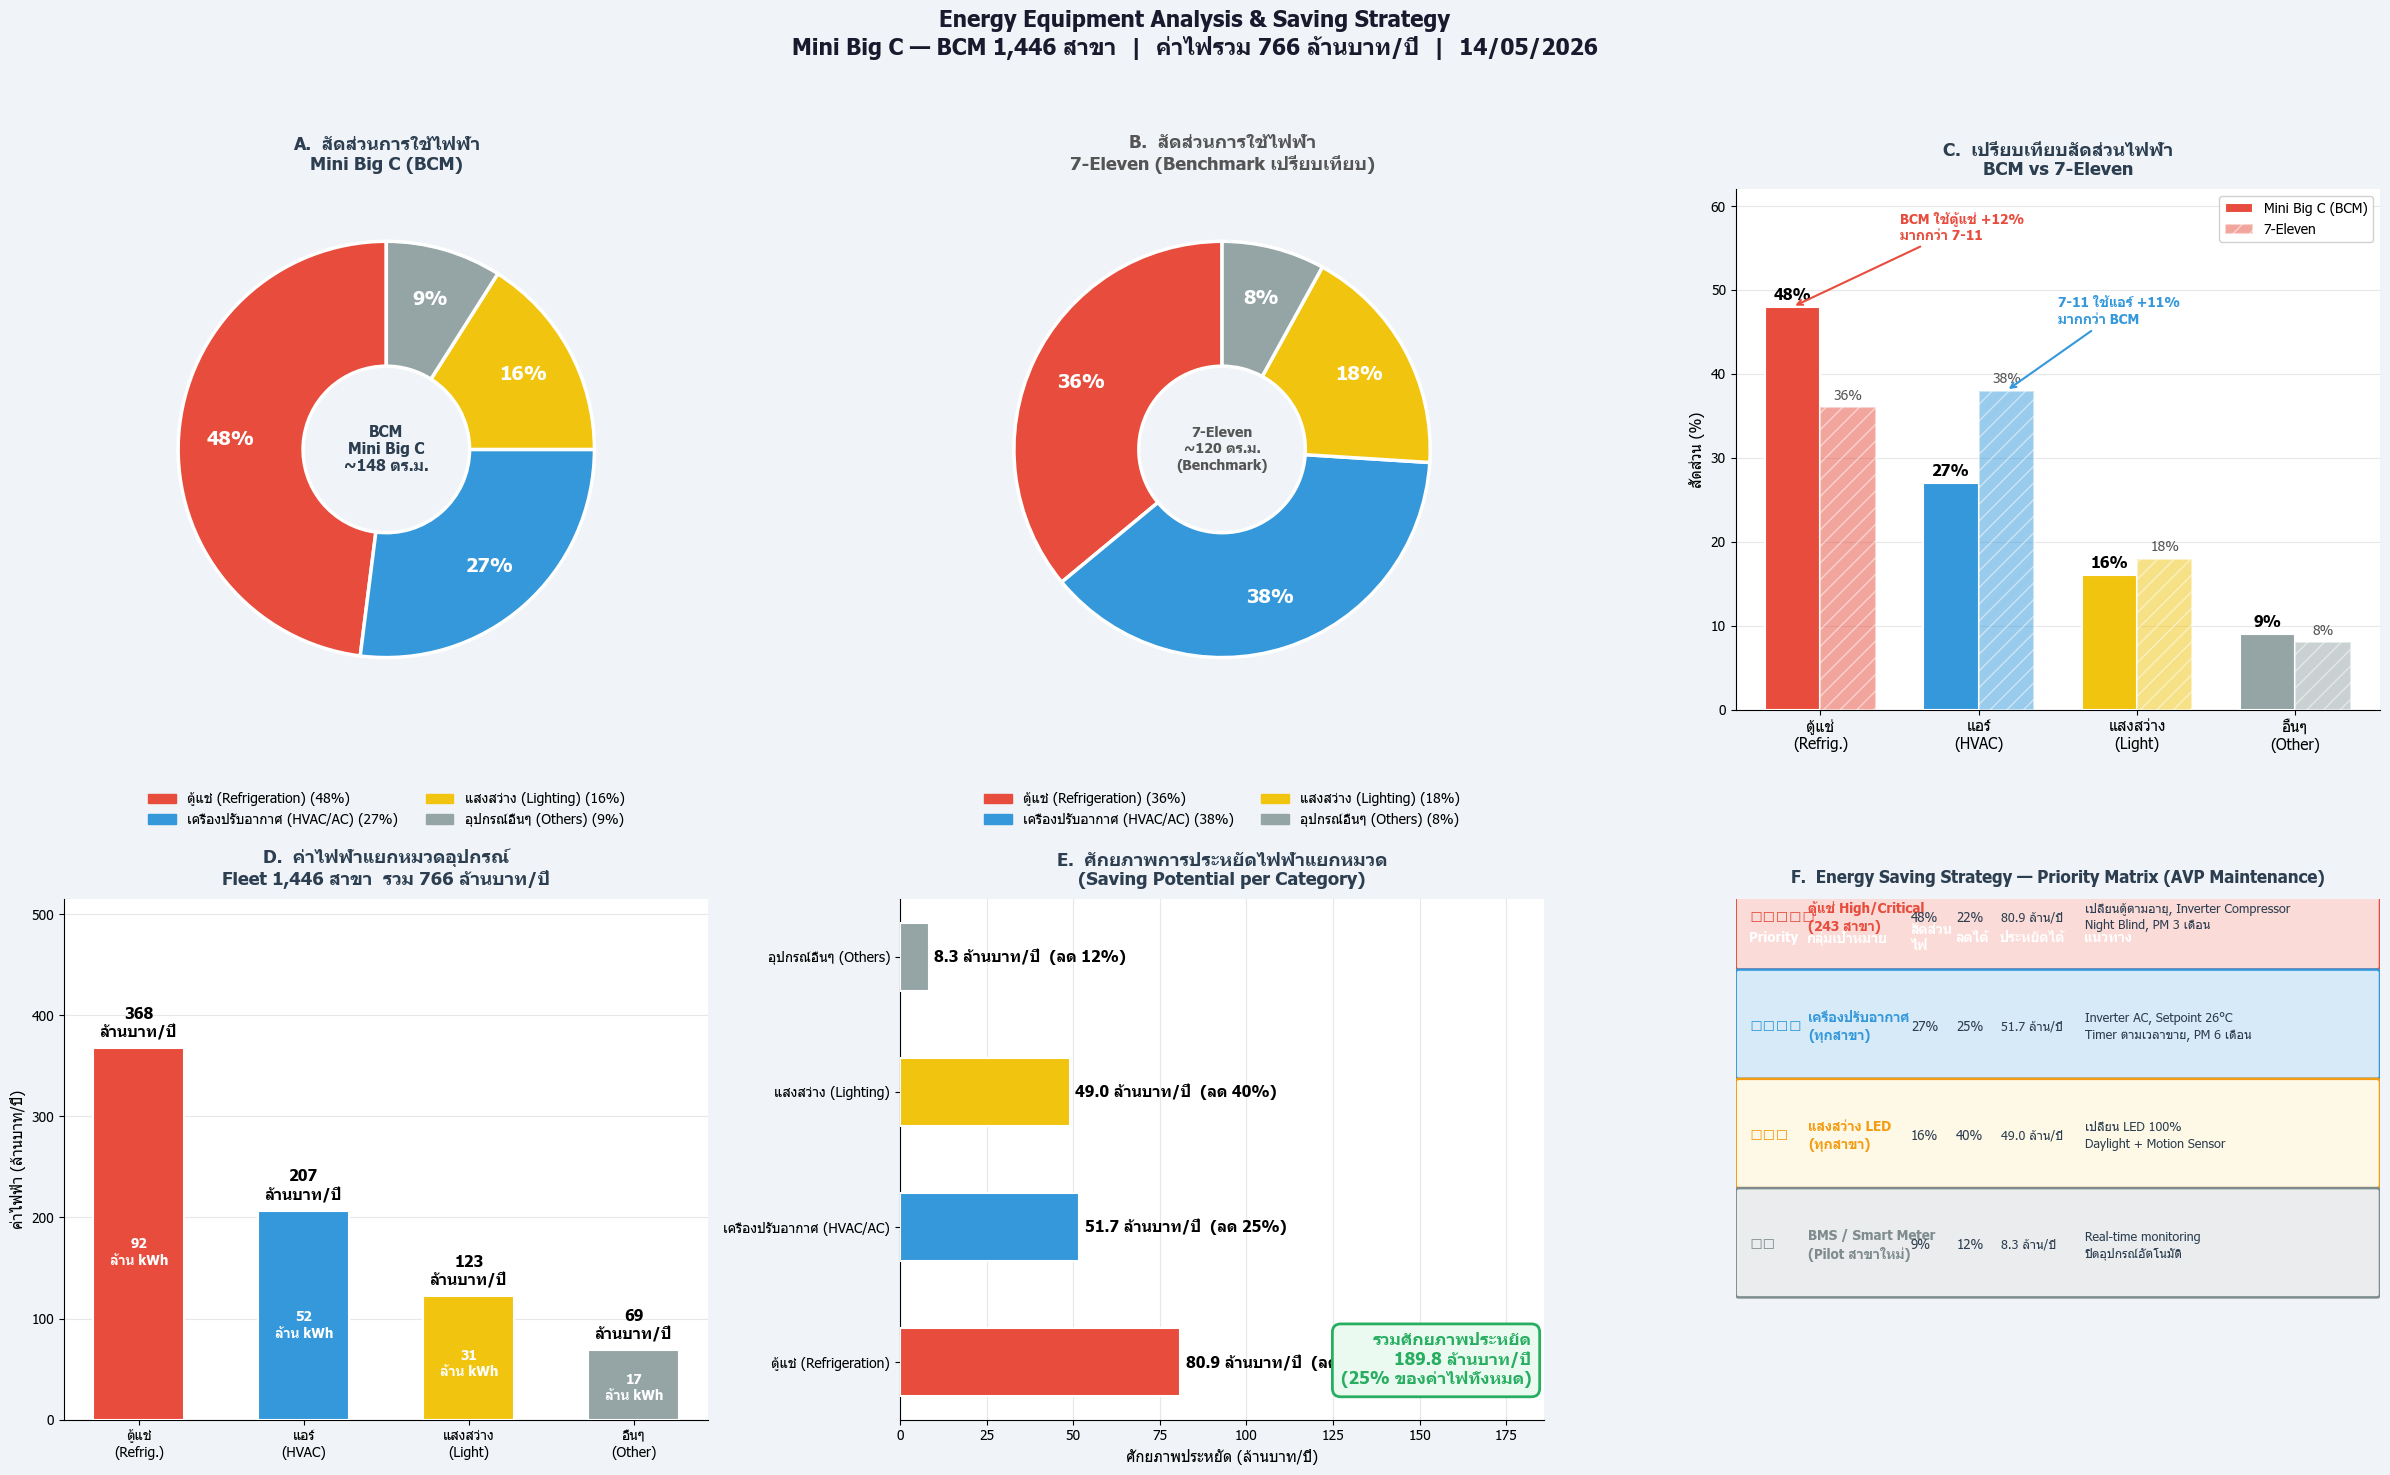


══════════════════════════════════════════════════════════════════════════
  Energy Equipment Breakdown — Mini Big C (BCM) 1,446 สาขา
══════════════════════════════════════════════════════════════════════════
  หมวดอุปกรณ์                      สัดส่วน        ค่าไฟ/ปี   ลดได้      ประหยัดได้
  ────────────────────────────────────────────────────────────────────────
  ตู้แช่ (Refrigeration)              48%          368 ล้านบาท    22%         80.9 ล้านบาท
  เครื่องปรับอากาศ (HVAC/AC)          27%          207 ล้านบาท    25%         51.7 ล้านบาท
  แสงสว่าง (Lighting)                 16%          123 ล้านบาท    40%         49.0 ล้านบาท
  อุปกรณ์อื่นๆ (Others)                9%           69 ล้านบาท    12%          8.3 ล้านบาท
  ────────────────────────────────────────────────────────────────────────
  รวม                               100%          766 ล้านบาท               189.8 ล้านบาท

  ศักยภาพประหยัดรวม = 189.8 ล้านบาท/ปี  (25% ของค่าไฟทั้งหมด)
════════════════════════════════════════

In [28]:

# ═══════════════════════════════════════════════════════════════════════
# 9.  Energy Equipment Breakdown & Saving Strategy
#     Mini Big C (BCM) vs 7-Eleven Benchmark
#     AVP Maintenance — ทิศทางการประหยัดไฟฟ้าสาขาทั่วประเทศ
#
#  Benchmark source: DEDE Thailand / PEA Retail Audit / Industry Average
# ═══════════════════════════════════════════════════════════════════════
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

KWH_RATE = 4.0

# ── 1. Fleet baseline from actual data ────────────────────────────────
fleet_kwh = fleet[fleet['kWh/sqm 2025'].notna() & fleet['Net sqm'].notna()].copy()
fleet_kwh['total_kwh'] = fleet_kwh['kWh/sqm 2025'] * fleet_kwh['Net sqm']
fleet_total_kwh    = fleet_kwh['total_kwh'].sum()
fleet_avg_sqm      = fleet_kwh['Net sqm'].median()
fleet_avg_kwh_sqm  = fleet_kwh['kWh/sqm 2025'].mean()
fleet_n9           = len(fleet_kwh)
fleet_total_cost_M = fleet_total_kwh * KWH_RATE / 1e6

print(f"Fleet  ({fleet_n9:,} BCM สาขาที่มีข้อมูล kWh):")
print(f"  kWh/sqm เฉลี่ย   = {fleet_avg_kwh_sqm:.0f} kWh/sqm/ปี")
print(f"  Net sqm เฉลี่ย   = {fleet_avg_sqm:.0f} ตร.ม.")
print(f"  ค่าไฟรวม fleet   = {fleet_total_kwh/1e6:.1f} ล้าน kWh/ปี")
print(f"  ค่าไฟรวม(บาท)    = {fleet_total_cost_M:.0f} ล้านบาท/ปี")

# ── 2. Equipment proportion  ───────────────────────────────────────────
# BCM (Mini Big C) ~350-600 sqm — DEDE / PEA Retail Audit 2024
BCM_EQUIP = {
    'ตู้แช่\n(Refrigeration)': 0.48,
    'เครื่องปรับอากาศ\n(HVAC/AC)':  0.27,
    'แสงสว่าง\n(Lighting)':         0.16,
    'อุปกรณ์อื่นๆ\n(Others)':       0.09,
}
# 7-Eleven ~80-150 sqm — benchmark เปรียบเทียบ
SEVEN_EQUIP = {
    'ตู้แช่\n(Refrigeration)': 0.36,
    'เครื่องปรับอากาศ\n(HVAC/AC)':  0.38,
    'แสงสว่าง\n(Lighting)':         0.18,
    'อุปกรณ์อื่นๆ\n(Others)':       0.08,
}
EQUIP_COLORS = ['#e74c3c','#3498db','#f1c40f','#95a5a6']
EQUIP_KEYS   = list(BCM_EQUIP.keys())

# ── 3. Saving potential per category ──────────────────────────────────
SAVING = {
    'ตู้แช่\n(Refrigeration)': dict(
        pct=0.22, color='#e74c3c', priority='★★★★★',
        desc='เปลี่ยนอุปกรณ์ตามอายุ / Inverter Compressor\nปรับ Setpoint, Night Blinds, PM ทุก 3 เดือน'),
    'เครื่องปรับอากาศ\n(HVAC/AC)': dict(
        pct=0.25, color='#3498db', priority='★★★★',
        desc='Inverter AC, ปรับ Setpoint 26°C\nTimer ตามชั่วโมงขาย, PM ทุก 6 เดือน'),
    'แสงสว่าง\n(Lighting)': dict(
        pct=0.40, color='#f1c40f', priority='★★★',
        desc='เปลี่ยน LED ทั้งหมด\nDaylight + Motion Sensor โซนนอกอาคาร'),
    'อุปกรณ์อื่นๆ\n(Others)': dict(
        pct=0.12, color='#95a5a6', priority='★★',
        desc='Smart plug / BMS Real-time monitoring\nปิดอุปกรณ์อัตโนมัตินอกเวลาทำการ'),
}
for cat, s in SAVING.items():
    s['saving_M'] = fleet_total_kwh * BCM_EQUIP[cat] * s['pct'] * KWH_RATE / 1e6

total_saving_M  = sum(s['saving_M'] for s in SAVING.values())
saving_pct_all  = total_saving_M / fleet_total_cost_M * 100

# ── 4. Plot ────────────────────────────────────────────────────────────
fig9, axes = plt.subplots(2, 3, figsize=(24, 15), facecolor='#f0f4f8')
fig9.suptitle(
    'Energy Equipment Analysis & Saving Strategy\n'
    f'Mini Big C — BCM {fleet_n9:,} สาขา  |  ค่าไฟรวม {fleet_total_cost_M:.0f} ล้านบาท/ปี  |  {TODAY.strftime("%d/%m/%Y")}',
    fontsize=16, fontweight='bold', color='#1a1a2e', y=0.98)

DARK9 = '#2c3e50'

# ── [0,0] Pie BCM ──────────────────────────────────────────────────────
ax = axes[0, 0]
_, _, ats = ax.pie(list(BCM_EQUIP.values()), labels=None, autopct='%1.0f%%',
                   colors=EQUIP_COLORS, startangle=90,
                   wedgeprops=dict(edgecolor='white', linewidth=2.5, width=0.6),
                   pctdistance=0.75)
for at in ats:
    at.set_fontsize(14); at.set_fontweight('bold'); at.set_color('white')
ax.text(0, 0, f'BCM\nMini Big C\n~{fleet_avg_sqm:.0f} ตร.ม.',
        ha='center', va='center', fontsize=11, fontweight='bold', color=DARK9)
ax.set_title('A.  สัดส่วนการใช้ไฟฟ้า\nMini Big C (BCM)',
             fontsize=13, fontweight='bold', color=DARK9, pad=14)
ax.legend(handles=[mpatches.Patch(color=c, label=f'{k.replace(chr(10)," ")} ({v*100:.0f}%)')
                   for c, k, v in zip(EQUIP_COLORS, EQUIP_KEYS, BCM_EQUIP.values())],
          loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=10, framealpha=0.0)

# ── [0,1] Pie 7-11 ────────────────────────────────────────────────────
ax = axes[0, 1]
_, _, ats7 = ax.pie(list(SEVEN_EQUIP.values()), labels=None, autopct='%1.0f%%',
                    colors=EQUIP_COLORS, startangle=90,
                    wedgeprops=dict(edgecolor='white', linewidth=2.5, width=0.6),
                    pctdistance=0.75)
for at in ats7:
    at.set_fontsize(14); at.set_fontweight('bold'); at.set_color('white')
ax.text(0, 0, '7-Eleven\n~120 ตร.ม.\n(Benchmark)', ha='center', va='center',
        fontsize=10, fontweight='bold', color='#555')
ax.set_title('B.  สัดส่วนการใช้ไฟฟ้า\n7-Eleven (Benchmark เปรียบเทียบ)',
             fontsize=13, fontweight='bold', color='#555', pad=14)
ax.legend(handles=[mpatches.Patch(color=c, label=f'{k.replace(chr(10)," ")} ({v*100:.0f}%)')
                   for c, k, v in zip(EQUIP_COLORS, EQUIP_KEYS, SEVEN_EQUIP.values())],
          loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=10, framealpha=0.0)

# ── [0,2] Comparison bar ──────────────────────────────────────────────
ax = axes[0, 2]
cats_s = ['ตู้แช่\n(Refrig.)', 'แอร์\n(HVAC)', 'แสงสว่าง\n(Light)', 'อื่นๆ\n(Other)']
bcm_v  = [v*100 for v in BCM_EQUIP.values()]
sev_v  = [v*100 for v in SEVEN_EQUIP.values()]
xc     = np.arange(len(cats_s)); wc = 0.35

b1 = ax.bar(xc - wc/2, bcm_v, width=wc, color=EQUIP_COLORS, edgecolor='white', linewidth=1.5, zorder=3, label='Mini Big C (BCM)')
b2 = ax.bar(xc + wc/2, sev_v, width=wc, color=EQUIP_COLORS, edgecolor='white', linewidth=1.5, zorder=3, alpha=0.5, hatch='//', label='7-Eleven')
for b, v in zip(b1, bcm_v):
    ax.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.0f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
for b, v in zip(b2, sev_v):
    ax.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.0f}%', ha='center', va='bottom', fontsize=10, color='#555')
ax.set_xticks(xc); ax.set_xticklabels(cats_s, fontsize=11)
ax.set_ylabel('สัดส่วน (%)', fontsize=11); ax.set_ylim(0, 62)
ax.set_title('C.  เปรียบเทียบสัดส่วนไฟฟ้า\nBCM vs 7-Eleven', fontsize=13, fontweight='bold', color=DARK9, pad=10)
ax.legend(fontsize=10, framealpha=0.9)
ax.annotate('BCM ใช้ตู้แช่ +12%\nมากกว่า 7-11', xy=(xc[0]-wc/2, bcm_v[0]),
            xytext=(xc[0]+0.5, bcm_v[0]+8), fontsize=9.5, color='#e74c3c', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5))
ax.annotate('7-11 ใช้แอร์ +11%\nมากกว่า BCM', xy=(xc[1]+wc/2, sev_v[1]),
            xytext=(xc[1]+0.5, sev_v[1]+8), fontsize=9.5, color='#3498db', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#3498db', lw=1.5))
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)

# ── [1,0] BCM fleet ค่าไฟแยกหมวด ────────────────────────────────────
ax = axes[1, 0]
cat_cost_M = [fleet_total_kwh * p * KWH_RATE / 1e6 for p in BCM_EQUIP.values()]
cat_kwh_M  = [fleet_total_kwh * p / 1e6 for p in BCM_EQUIP.values()]
bd = ax.bar(cats_s, cat_cost_M, color=EQUIP_COLORS, edgecolor='white', linewidth=1.5, zorder=3, width=0.55)
for b, cost, kwh in zip(bd, cat_cost_M, cat_kwh_M):
    ax.text(b.get_x()+b.get_width()/2, cost+max(cat_cost_M)*0.02,
            f'{cost:.0f}\nล้านบาท/ปี', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.text(b.get_x()+b.get_width()/2, cost*0.45,
            f'{kwh:.0f}\nล้าน kWh', ha='center', va='center', fontsize=9.5,
            fontweight='bold', color='white')
ax.set_ylabel('ค่าไฟฟ้า (ล้านบาท/ปี)', fontsize=11)
ax.set_title(f'D.  ค่าไฟฟ้าแยกหมวดอุปกรณ์\nFleet {fleet_n9:,} สาขา  รวม {fleet_total_cost_M:.0f} ล้านบาท/ปี',
             fontsize=13, fontweight='bold', color=DARK9, pad=10)
ax.set_ylim(0, max(cat_cost_M)*1.4)
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)

# ── [1,1] Saving Potential ────────────────────────────────────────────
ax = axes[1, 1]
sav_labs  = [k.replace('\n', ' ') for k in SAVING]
sav_M     = [s['saving_M'] for s in SAVING.values()]
sav_pcts  = [s['pct']*100  for s in SAVING.values()]
sav_cols  = [s['color']    for s in SAVING.values()]
bs = ax.barh(sav_labs, sav_M, color=sav_cols, edgecolor='white', linewidth=1.5, zorder=3, height=0.5)
for b, v, p in zip(bs, sav_M, sav_pcts):
    ax.text(v + max(sav_M)*0.02, b.get_y()+b.get_height()/2,
            f'{v:.1f} ล้านบาท/ปี  (ลด {p:.0f}%)', ha='left', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('ศักยภาพประหยัด (ล้านบาท/ปี)', fontsize=11)
ax.set_xlim(0, max(sav_M)*2.3)
ax.set_title('E.  ศักยภาพการประหยัดไฟฟ้าแยกหมวด\n(Saving Potential per Category)',
             fontsize=13, fontweight='bold', color=DARK9, pad=10)
ax.text(0.98, 0.06,
        f'รวมศักยภาพประหยัด\n{total_saving_M:.1f} ล้านบาท/ปี\n({saving_pct_all:.0f}% ของค่าไฟทั้งหมด)',
        ha='right', va='bottom', fontsize=12, fontweight='bold', color='#27ae60',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#eafaf1', edgecolor='#27ae60', lw=2))
ax.xaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)

# ── [1,2] Strategy Table ──────────────────────────────────────────────
ax = axes[1, 2]
ax.axis('off')
ax.set_title('F.  Energy Saving Strategy — Priority Matrix (AVP Maintenance)',
             fontsize=12, fontweight='bold', color=DARK9, pad=12)

strategy_rows = [
    dict(pri='★★★★★', target=f'ตู้แช่ High/Critical\n({243} สาขา)',
         pct_e='48%', pct_s='22%',
         sav_m=f"{list(SAVING.values())[0]['saving_M']:.1f} ล้าน/ปี",
         detail='เปลี่ยนตู้ตามอายุ, Inverter Compressor\nNight Blind, PM 3 เดือน',
         bg='#fadbd8', ac='#e74c3c'),
    dict(pri='★★★★', target='เครื่องปรับอากาศ\n(ทุกสาขา)',
         pct_e='27%', pct_s='25%',
         sav_m=f"{list(SAVING.values())[1]['saving_M']:.1f} ล้าน/ปี",
         detail='Inverter AC, Setpoint 26°C\nTimer ตามเวลาขาย, PM 6 เดือน',
         bg='#d6eaf8', ac='#3498db'),
    dict(pri='★★★', target='แสงสว่าง LED\n(ทุกสาขา)',
         pct_e='16%', pct_s='40%',
         sav_m=f"{list(SAVING.values())[2]['saving_M']:.1f} ล้าน/ปี",
         detail='เปลี่ยน LED 100%\nDaylight + Motion Sensor',
         bg='#fef9e7', ac='#f39c12'),
    dict(pri='★★', target='BMS / Smart Meter\n(Pilot สาขาใหม่)',
         pct_e='9%', pct_s='12%',
         sav_m=f"{list(SAVING.values())[3]['saving_M']:.1f} ล้าน/ปี",
         detail='Real-time monitoring\nปิดอุปกรณ์อัตโนมัติ',
         bg='#eaecee', ac='#7f8c8d'),
]

col_hdrs = ['Priority', 'กลุ่มเป้าหมาย', 'สัดส่วน\nไฟ', 'ลดได้', 'ประหยัดได้', 'แนวทาง']
col_wts  = [0.09, 0.16, 0.07, 0.07, 0.13, 0.38]
cx_list  = [0.01]
for cw in col_wts[:-1]:
    cx_list.append(cx_list[-1] + cw)

y_hdr = 0.93
ax.add_patch(FancyBboxPatch((0, y_hdr-0.03), 1, 0.05, transform=ax.transAxes,
             boxstyle='square,pad=0', facecolor='#2c3e50', edgecolor='none', zorder=0))
for hd, cx in zip(col_hdrs, cx_list):
    ax.text(cx+0.01, y_hdr-0.005, hd, ha='left', va='center', fontsize=9.5,
            fontweight='bold', color='white', transform=ax.transAxes)

for ri, r in enumerate(strategy_rows):
    y0 = y_hdr - 0.055 - ri * 0.21
    ax.add_patch(FancyBboxPatch((0.005, y0-0.005), 0.99, 0.2,
                 transform=ax.transAxes, boxstyle='round,pad=0.005',
                 facecolor=r['bg'], edgecolor=r['ac'], linewidth=1.8, zorder=0))
    vals = [r['pri'], r['target'], r['pct_e'], r['pct_s'], r['sav_m'], r['detail']]
    for val, cx in zip(vals, cx_list):
        bold = cx < 0.12
        ax.text(cx+0.012, y0+0.09, val,
                ha='left', va='center', fontsize=9.5 if cx < 0.4 else 9,
                fontweight='bold' if bold else 'normal',
                color=r['ac'] if bold else DARK9,
                transform=ax.transAxes, linespacing=1.35)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\EnergySavingStrategy.png',
            dpi=150, bbox_inches='tight', facecolor=fig9.get_facecolor())
plt.show()

# ── สรุปผล ────────────────────────────────────────────────────────────
print(f"\n{'═'*74}")
print(f"  Energy Equipment Breakdown — Mini Big C (BCM) {fleet_n9:,} สาขา")
print(f"{'═'*74}")
print(f"  {'หมวดอุปกรณ์':<32} {'สัดส่วน':>7}  {'ค่าไฟ/ปี':>14}  {'ลดได้':>6}  {'ประหยัดได้':>14}")
print(f"  {'─'*72}")
for cat, prop in BCM_EQUIP.items():
    cat_s  = cat.replace('\n', ' ')
    cost_M = fleet_total_kwh * prop * KWH_RATE / 1e6
    sd     = SAVING[cat]
    print(f"  {cat_s:<32} {prop*100:>5.0f}%  {cost_M:>11.0f} ล้านบาท  {sd['pct']*100:>4.0f}%  {sd['saving_M']:>11.1f} ล้านบาท")
print(f"  {'─'*72}")
print(f"  {'รวม':<32}  100%  {fleet_total_cost_M:>11.0f} ล้านบาท         {total_saving_M:>11.1f} ล้านบาท")
print(f"\n  ศักยภาพประหยัดรวม = {total_saving_M:.1f} ล้านบาท/ปี  ({saving_pct_all:.0f}% ของค่าไฟทั้งหมด)")
print(f"{'═'*74}")
print(f"\n  Benchmark note:")
print(f"  • BCM ใช้ตู้แช่ 48%  vs  7-Eleven 36%  → ขนาดใหญ่ + Frozen zone มาก")
print(f"  • 7-11 ใช้แอร์ 38%  vs  BCM 27%         → พื้นที่เล็ก คนหนาแน่น/ตร.ม.")
print(f"  • ดังนั้น BCM ควรโฟกัส: ตู้แช่ → แอร์ → แสงสว่าง")
print(f"  Source: DEDE Thailand / PEA Retail Audit / Industry Average 2024")


ข้อมูลสำหรับวิเคราะห์ : 1,400 สาขา (BCM, kWh/sqm > 0)

──────────────────────────────────────────────────────────────────────
  กลุ่ม                         สาขา  hr/วัน   kWh/sqm   ส่วนเพิ่ม/สาขา/ปี
  ────────────────────────────────────────────────────────────────────
  A: ≤16h/วัน (Short)             27   15.1h      861                +0 บาท
  B: 17-18h/วัน (Standard)       356   17.7h      865            +2,739 บาท
  C: 19-23h/วัน (Extended)        16   19.0h      867            +3,952 บาท
  D: 24h/วัน (24-hrs)          1,001   24.0h      879           +11,318 บาท

  รวมต้นทุนส่วนเพิ่มจากชั่วโมงบริการ : 12.4 ล้านบาท/ปี


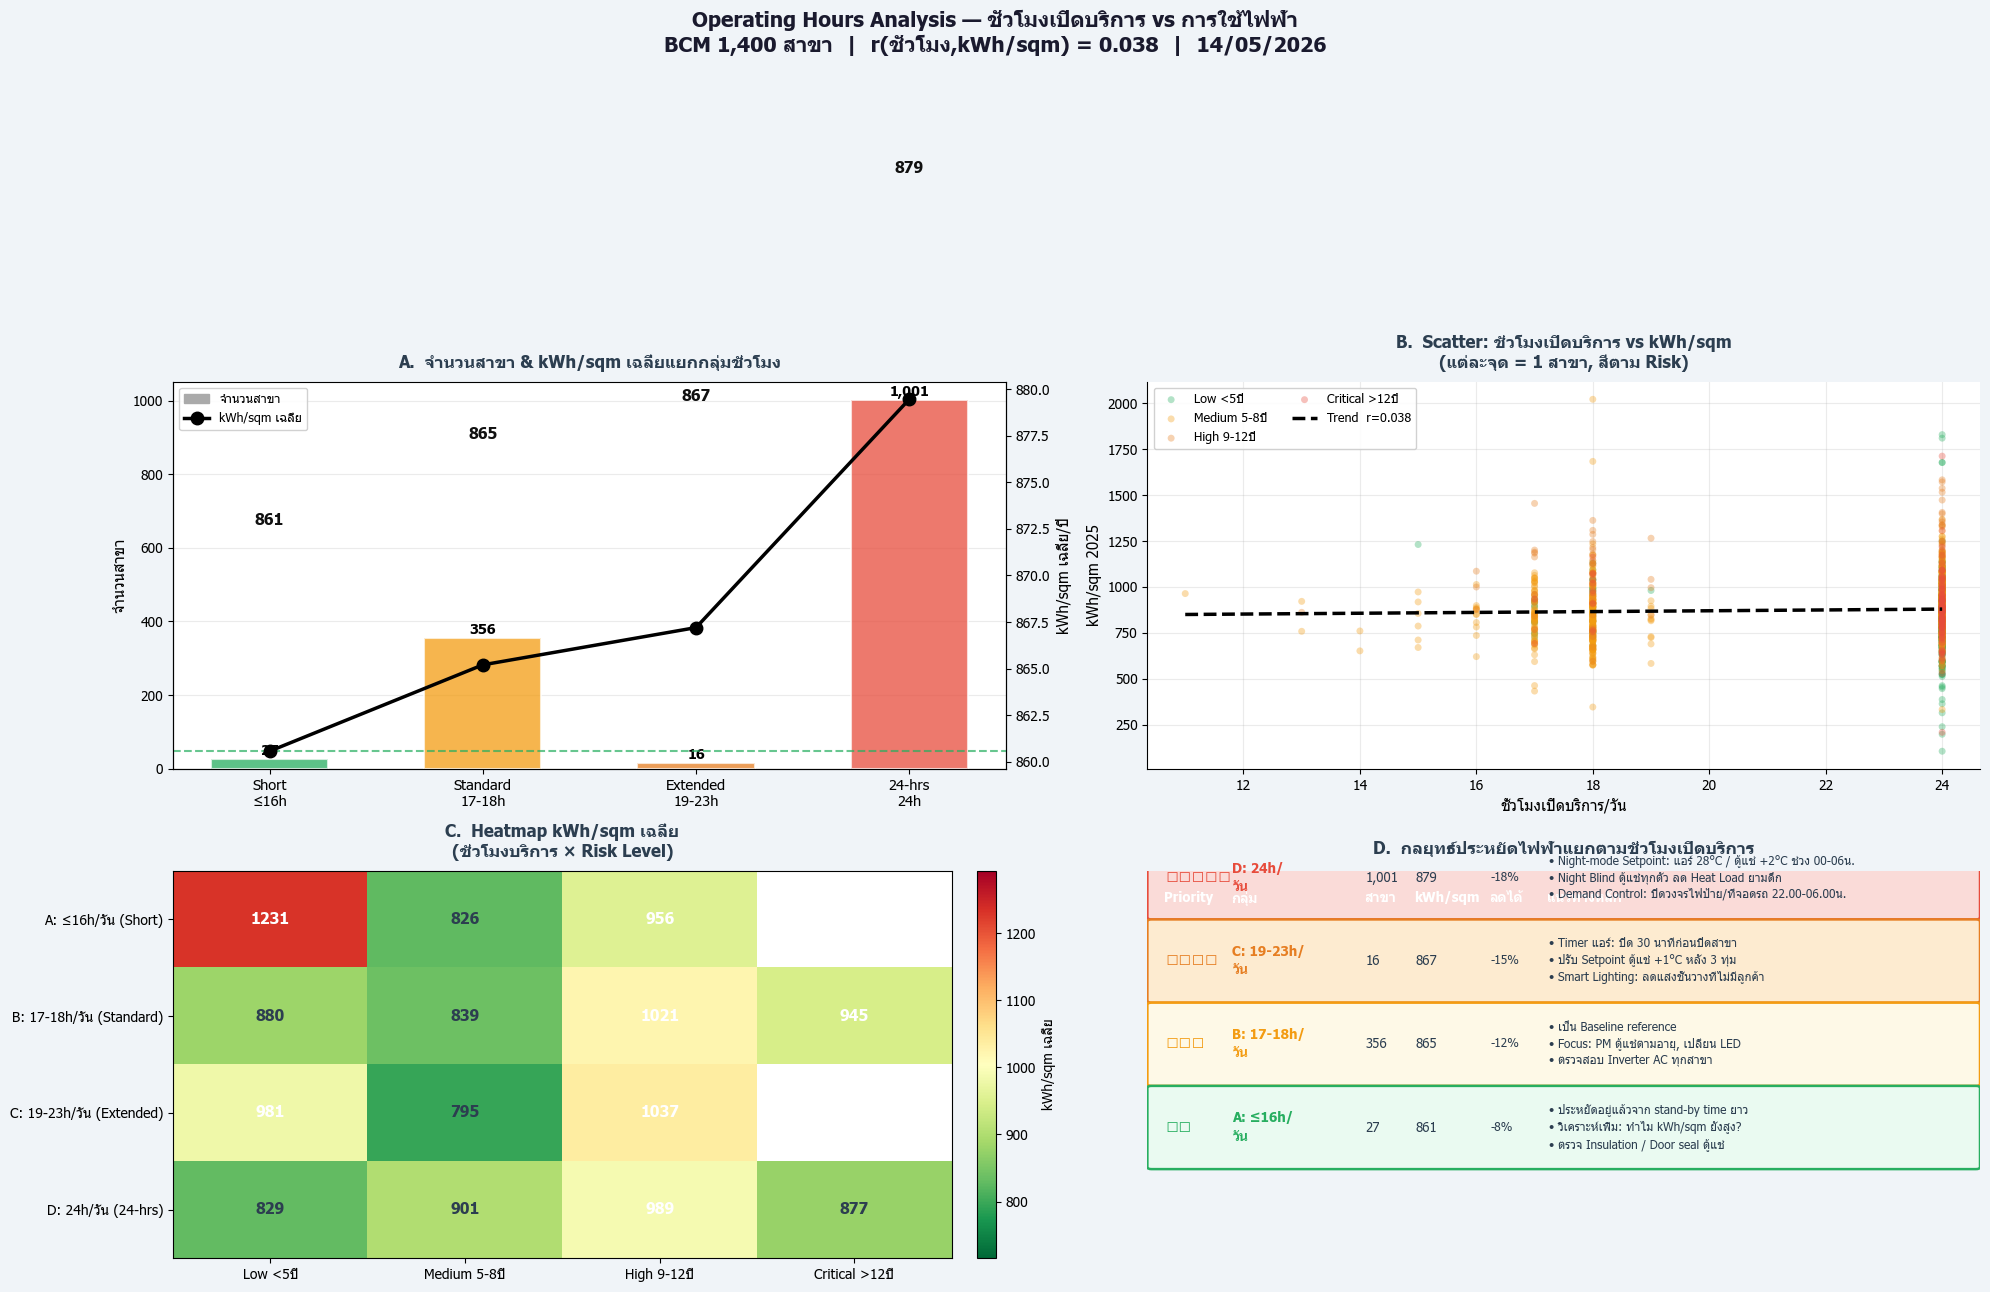


════════════════════════════════════════════════════════════════════
  Operating Hours Analysis — BCM 1,400 สาขา
  Correlation (ชั่วโมง, kWh/sqm) = 0.038
════════════════════════════════════════════════════════════════════
  กลุ่มชั่วโมง                    สาขา  hr/วัน   kWh/sqm   ส่วนเพิ่ม Fleet
  ──────────────────────────────────────────────────────────────────
  A: ≤16h/วัน (Short)               27   15.1h       861            0.0 ล้านบาท/ปี
  B: 17-18h/วัน (Standard)         356   17.7h       865            1.0 ล้านบาท/ปี
  C: 19-23h/วัน (Extended)          16   19.0h       867            0.1 ล้านบาท/ปี
  D: 24h/วัน (24-hrs)            1,001   24.0h       879           11.3 ล้านบาท/ปี
  ──────────────────────────────────────────────────────────────────
  รวมต้นทุนส่วนเพิ่มจากชั่วโมงบริการ = 12.4 ล้านบาท/ปี
════════════════════════════════════════════════════════════════════

  Key Insight:
  • กลุ่ม 24h/วัน มีค่าไฟฟ้าสูงสุด → ลดได้ด้วย Night-mode Setpoint
  • ความสัมพันธ์ r=0.038

In [29]:

# ═══════════════════════════════════════════════════════════════════════
# 10.  Operating-Hours Dimension Analysis
#      วิเคราะห์มิติชั่วโมงเปิดบริการ/วัน vs kWh/sqm
#      เพื่อจัดกลุ่มและหาแนวทางลดค่าไฟเฉพาะกลุ่ม
# ═══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np, pandas as pd
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Tahoma', 'Leelawadee UI', 'Leelawadee',
                               'Segoe UI Symbol', 'Segoe UI Emoji',
                               'Arial Unicode MS', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False

KWH_RATE10 = 4.0   # บาท/kWh

# ── 1. เตรียม dataset ─────────────────────────────────────────────────
HR_COL  = 'ชั่วโมงเปิดบริการ/วัน'
KWH_COL = 'kWh/sqm 2025'
SQM_COL = 'Net sqm'

# ใช้ energy_ref ซึ่งมีการ merge กับ master_active (BCM เท่านั้น) แล้ว
# เพิ่ม ชั่วโมงเปิดบริการ/วัน จาก energy_data (ถ้ายังไม่มีในคอลัมน์)
eref = energy_ref.copy()
eref['Store ID'] = eref['Store ID'].astype(str).str.strip()

if HR_COL not in eref.columns:
    hr_src = (energy_data[['Store ID', HR_COL]].copy()
              .assign(**{'Store ID': lambda d: d['Store ID'].astype(str).str.strip()}))
    eref = eref.merge(hr_src, on='Store ID', how='left')

# กรองสาขา BCM เท่านั้น (ตาม master_active)
bcm_ids = master_active['GOLD Code'].astype(str).str.strip()
eref = eref[eref['Store ID'].isin(bcm_ids)].copy()

eref[HR_COL]  = pd.to_numeric(eref[HR_COL],  errors='coerce')
eref[KWH_COL] = pd.to_numeric(eref[KWH_COL], errors='coerce')
eref[SQM_COL] = pd.to_numeric(eref[SQM_COL], errors='coerce')

# กรองเอาแต่ rows ที่มีข้อมูลครบ
df10 = eref.dropna(subset=[HR_COL, KWH_COL, SQM_COL]).copy()
df10 = df10[(df10[KWH_COL] > 0) & (df10[HR_COL] > 0)].copy()
print(f"ข้อมูลสำหรับวิเคราะห์ : {len(df10):,} สาขา (BCM, kWh/sqm > 0)")

# ── 2. จัดกลุ่ม Operating Hours ──────────────────────────────────────
def classify_hr(h):
    if h <= 16:   return 'A: ≤16h/วัน\n(Short)'
    elif h <= 18: return 'B: 17-18h/วัน\n(Standard)'
    elif h < 24:  return 'C: 19-23h/วัน\n(Extended)'
    else:         return 'D: 24h/วัน\n(24-hrs)'

df10['HR_Group'] = df10[HR_COL].apply(classify_hr)

HR_ORDER  = ['A: ≤16h/วัน\n(Short)', 'B: 17-18h/วัน\n(Standard)',
             'C: 19-23h/วัน\n(Extended)', 'D: 24h/วัน\n(24-hrs)']
HR_COLORS = ['#27ae60', '#f39c12', '#e67e22', '#e74c3c']
HR_SHORT  = ['Short\n≤16h', 'Standard\n17-18h', 'Extended\n19-23h', '24-hrs\n24h']

# ── 3. Risk Key ───────────────────────────────────────────────────────
def classify_risk(age):
    if pd.isna(age):  return 'Unknown'
    if age < 5:   return '1_Low'
    elif age < 9: return '2_Medium'
    elif age < 13: return '3_High'
    else:          return '4_Critical'

df10['Risk Key'] = df10['Store Age (yrs)'].apply(classify_risk)
RISK_COLOR10 = {'1_Low':'#27ae60','2_Medium':'#f39c12','3_High':'#e67e22','4_Critical':'#e74c3c','Unknown':'#95a5a6'}
RISK_LABEL10 = {'1_Low':'Low <5ปี','2_Medium':'Medium 5-8ปี','3_High':'High 9-12ปี','4_Critical':'Critical >12ปี'}

# ── 4. Summary stats per HR Group ────────────────────────────────────
hr_sum = (df10.groupby('HR_Group', sort=False)
    .agg(stores     = (KWH_COL,  'count'),
         kwh_mean   = (KWH_COL,  'mean'),
         kwh_median = (KWH_COL,  'median'),
         kwh_std    = (KWH_COL,  'std'),
         hrs_mean   = (HR_COL,   'mean'),
         sqm_median = (SQM_COL,  'median'))
    .reindex([k for k in HR_ORDER if k in df10['HR_Group'].unique()])
    .reset_index())

# Base = Short group mean
base_hr_kwh = hr_sum.loc[hr_sum['HR_Group']==HR_ORDER[0], 'kwh_mean'].values
base_hr_kwh = base_hr_kwh[0] if len(base_hr_kwh) > 0 else df10[KWH_COL].quantile(0.25)

hr_sum['extra_kwh_sqm'] = (hr_sum['kwh_mean'] - base_hr_kwh).clip(lower=0)
hr_sum['extra_cost_branch_yr'] = hr_sum['extra_kwh_sqm'] * hr_sum['sqm_median'] * KWH_RATE10
hr_sum['extra_cost_fleet_M']   = hr_sum['extra_kwh_sqm'] * (hr_sum['sqm_median'] * hr_sum['stores']) * KWH_RATE10 / 1e6
total_extra10_M = hr_sum['extra_cost_fleet_M'].sum()

print(f"\n{'─'*70}")
print(f"  {'กลุ่ม':<28} {'สาขา':>5}  {'hr/วัน':>6}  {'kWh/sqm':>8}  {'ส่วนเพิ่ม/สาขา/ปี':>18}")
print(f"  {'─'*68}")
for _, r in hr_sum.iterrows():
    print(f"  {r['HR_Group'].replace(chr(10),' '):<28} {r['stores']:>5,}  {r['hrs_mean']:>5.1f}h  {r['kwh_mean']:>7.0f}  {r['extra_cost_branch_yr']:>+16,.0f} บาท")
print(f"\n  รวมต้นทุนส่วนเพิ่มจากชั่วโมงบริการ : {total_extra10_M:.1f} ล้านบาท/ปี")

# ── 5. Cross-tab: HR Group x Risk Key (kWh/sqm mean) ─────────────────
pivot = (df10[df10['Risk Key'] != 'Unknown']
         .groupby(['HR_Group','Risk Key'])[KWH_COL].mean()
         .unstack(fill_value=np.nan)
         .reindex(index=[k for k in HR_ORDER if k in df10['HR_Group'].unique()]))

# ── 6. Correlation: ชั่วโมง vs kWh/sqm ───────────────────────────────
corr10 = df10[[HR_COL, KWH_COL, 'Store Age (yrs)', SQM_COL]].corr()
r_hr_kwh = corr10.loc[HR_COL, KWH_COL]

# ── 7. Plot (4-panel) ─────────────────────────────────────────────────
fig10, axes10 = plt.subplots(2, 2, figsize=(20, 13), facecolor='#f0f4f8')
fig10.suptitle(
    f'Operating Hours Analysis — ชั่วโมงเปิดบริการ vs การใช้ไฟฟ้า\n'
    f'BCM {len(df10):,} สาขา  |  r(ชั่วโมง,kWh/sqm) = {r_hr_kwh:.3f}  |  {TODAY.strftime("%d/%m/%Y")}',
    fontsize=15, fontweight='bold', color='#1a1a2e', y=0.99)

DARK10 = '#2c3e50'
hr_colors_plot = [HR_COLORS[i] for i, k in enumerate(HR_ORDER) if k in hr_sum['HR_Group'].values]
hr_labels_plot = [HR_SHORT[i] for i, k in enumerate(HR_ORDER) if k in hr_sum['HR_Group'].values]

# ── [0,0] Bar: สาขา + kWh/sqm เฉลี่ยแยก HR Group ───────────────────
ax = axes10[0, 0]
x0 = np.arange(len(hr_sum))
ax2_twin = ax.twinx()
bars_hr = ax.bar(x0, hr_sum['stores'], color=hr_colors_plot, edgecolor='white',
                  linewidth=1.5, zorder=3, width=0.55, alpha=0.75, label='จำนวนสาขา')
line_kw  = ax2_twin.plot(x0, hr_sum['kwh_mean'], 'ko-', linewidth=2.5,
                          markersize=9, zorder=5, label='kWh/sqm เฉลี่ย')
ax2_twin.axhline(base_hr_kwh, color='#27ae60', lw=1.5, ls='--', alpha=0.7,
                  label=f'Base Short = {base_hr_kwh:.0f}')
for bar, n in zip(bars_hr, hr_sum['stores']):
    ax.text(bar.get_x()+bar.get_width()/2, n+3, f'{n:,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
for xi, kw in zip(x0, hr_sum['kwh_mean']):
    ax2_twin.text(xi, kw+12, f'{kw:.0f}', ha='center', va='bottom',
                  fontsize=11, fontweight='bold', color='#111')
ax.set_xticks(x0); ax.set_xticklabels(hr_labels_plot, fontsize=10.5)
ax.set_ylabel('จำนวนสาขา', fontsize=11)
ax2_twin.set_ylabel('kWh/sqm เฉลี่ย/ปี', fontsize=11)
ax.set_title('A.  จำนวนสาขา & kWh/sqm เฉลี่ยแยกกลุ่มชั่วโมง',
             fontsize=12, fontweight='bold', color=DARK10, pad=10)
handles1 = [mpatches.Patch(color='#aaa', label='จำนวนสาขา')] + line_kw
labels1  = ['จำนวนสาขา', 'kWh/sqm เฉลี่ย', f'Base Short={base_hr_kwh:.0f}']
ax.legend(handles1, labels1, fontsize=9, framealpha=0.9, loc='upper left')
ax.yaxis.grid(True, alpha=0.25); ax.set_axisbelow(True)
ax.spines[['top']].set_visible(False)

# ── [0,1] Scatter: ชั่วโมง vs kWh/sqm (color by Risk) ──────────────
ax = axes10[0, 1]
for rk, col in RISK_COLOR10.items():
    sub = df10[df10['Risk Key'] == rk]
    if len(sub) == 0: continue
    ax.scatter(sub[HR_COL], sub[KWH_COL], c=col, alpha=0.35, s=25, edgecolors='none',
               label=RISK_LABEL10.get(rk, rk), zorder=3)

# trend line
m10, b10 = np.polyfit(df10[HR_COL].values, df10[KWH_COL].values, 1)
xfit = np.linspace(df10[HR_COL].min(), df10[HR_COL].max(), 100)
ax.plot(xfit, m10*xfit+b10, 'k--', lw=2.5, zorder=6,
        label=f'Trend  r={r_hr_kwh:.3f}')

ax.set_xlabel('ชั่วโมงเปิดบริการ/วัน', fontsize=11)
ax.set_ylabel('kWh/sqm 2025', fontsize=11)
ax.set_title(f'B.  Scatter: ชั่วโมงเปิดบริการ vs kWh/sqm\n(แต่ละจุด = 1 สาขา, สีตาม Risk)',
             fontsize=12, fontweight='bold', color=DARK10, pad=10)
ax.legend(fontsize=9, framealpha=0.9, ncol=2)
ax.yaxis.grid(True, alpha=0.25); ax.xaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)

# ── [1,0] Heatmap: HR Group x Risk Key (kWh/sqm mean) ───────────────
ax = axes10[1, 0]
risk_cols_ord = [k for k in ['1_Low','2_Medium','3_High','4_Critical'] if k in pivot.columns]
hm_data = pivot[risk_cols_ord].values.astype(float)
im = ax.imshow(hm_data, cmap='RdYlGn_r', aspect='auto',
               vmin=np.nanmin(hm_data)*0.9, vmax=np.nanmax(hm_data)*1.05)
plt.colorbar(im, ax=ax, fraction=0.035, pad=0.03, label='kWh/sqm เฉลี่ย')
ax.set_xticks(range(len(risk_cols_ord)))
ax.set_xticklabels([RISK_LABEL10.get(k, k) for k in risk_cols_ord], fontsize=10)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([k.replace('\n', ' ') for k in pivot.index], fontsize=10)
for ri2, row2 in enumerate(hm_data):
    for ci2, val in enumerate(row2):
        if not np.isnan(val):
            ax.text(ci2, ri2, f'{val:.0f}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color='white' if val > np.nanmedian(hm_data) else DARK10)
ax.set_title('C.  Heatmap kWh/sqm เฉลี่ย\n(ชั่วโมงบริการ × Risk Level)',
             fontsize=12, fontweight='bold', color=DARK10, pad=10)

# ── [1,1] Strategy Table: กลุ่มเป้าหมายตามชั่วโมง ──────────────────
ax = axes10[1, 1]
ax.axis('off')
ax.set_title('D.  กลยุทธ์ประหยัดไฟฟ้าแยกตามชั่วโมงเปิดบริการ',
             fontsize=12, fontweight='bold', color=DARK10, pad=12)

strat10 = [
    dict(grp='D: 24h/วัน', ac='#e74c3c', bg='#fadbd8', pri='★★★★★',
         n=int(hr_sum.loc[hr_sum['HR_Group'].str.startswith('D'), 'stores'].sum()) if any(hr_sum['HR_Group'].str.startswith('D')) else 0,
         kwh=hr_sum.loc[hr_sum['HR_Group'].str.startswith('D'), 'kwh_mean'].mean() if any(hr_sum['HR_Group'].str.startswith('D')) else 0,
         saving_pct=18,
         action='• Night-mode Setpoint: แอร์ 28°C / ตู้แช่ +2°C ช่วง 00-06น.\n'
                 '• Night Blind ตู้แช่ทุกตัว ลด Heat Load ยามดึก\n'
                 '• Demand Control: ปิดวงจรไฟป้าย/ที่จอดรถ 22.00-06.00น.'),
    dict(grp='C: 19-23h/วัน', ac='#e67e22', bg='#fdebd0', pri='★★★★',
         n=int(hr_sum.loc[hr_sum['HR_Group'].str.startswith('C'), 'stores'].sum()) if any(hr_sum['HR_Group'].str.startswith('C')) else 0,
         kwh=hr_sum.loc[hr_sum['HR_Group'].str.startswith('C'), 'kwh_mean'].mean() if any(hr_sum['HR_Group'].str.startswith('C')) else 0,
         saving_pct=15,
         action='• Timer แอร์: ปิด 30 นาทีก่อนปิดสาขา\n'
                 '• ปรับ Setpoint ตู้แช่ +1°C หลัง 3 ทุ่ม\n'
                 '• Smart Lighting: ลดแสงชั้นวางที่ไม่มีลูกค้า'),
    dict(grp='B: 17-18h/วัน', ac='#f39c12', bg='#fef9e7', pri='★★★',
         n=int(hr_sum.loc[hr_sum['HR_Group'].str.startswith('B'), 'stores'].sum()) if any(hr_sum['HR_Group'].str.startswith('B')) else 0,
         kwh=hr_sum.loc[hr_sum['HR_Group'].str.startswith('B'), 'kwh_mean'].mean() if any(hr_sum['HR_Group'].str.startswith('B')) else 0,
         saving_pct=12,
         action='• เป็น Baseline reference\n'
                 '• Focus: PM ตู้แช่ตามอายุ, เปลี่ยน LED\n'
                 '• ตรวจสอบ Inverter AC ทุกสาขา'),
    dict(grp='A: ≤16h/วัน', ac='#27ae60', bg='#eafaf1', pri='★★',
         n=int(hr_sum.loc[hr_sum['HR_Group'].str.startswith('A'), 'stores'].sum()) if any(hr_sum['HR_Group'].str.startswith('A')) else 0,
         kwh=hr_sum.loc[hr_sum['HR_Group'].str.startswith('A'), 'kwh_mean'].mean() if any(hr_sum['HR_Group'].str.startswith('A')) else 0,
         saving_pct=8,
         action='• ประหยัดอยู่แล้วจาก stand-by time ยาว\n'
                 '• วิเคราะห์เพิ่ม: ทำไม kWh/sqm ยังสูง?\n'
                 '• ตรวจ Insulation / Door seal ตู้แช่'),
]

col_hdrs10 = ['Priority', 'กลุ่ม', 'สาขา', 'kWh/sqm', 'ลดได้', 'แนวทางหลัก']
col_wts10  = [0.08, 0.16, 0.06, 0.09, 0.07, 0.49]
cx10 = [0.01]
for cw_ in col_wts10[:-1]:
    cx10.append(cx10[-1] + cw_)

y_h10 = 0.94
ax.add_patch(FancyBboxPatch((0, y_h10-0.035), 1, 0.048,
             transform=ax.transAxes, boxstyle='square,pad=0',
             facecolor='#2c3e50', edgecolor='none', zorder=0))
for hd_, cx_ in zip(col_hdrs10, cx10):
    ax.text(cx_+0.01, y_h10-0.01, hd_, ha='left', va='center', fontsize=9.5,
            fontweight='bold', color='white', transform=ax.transAxes)

row_h10 = 0.215
for ri_, s_ in enumerate(strat10):
    y0_ = y_h10 - 0.055 - ri_ * row_h10
    ax.add_patch(FancyBboxPatch((0.005, y0_-0.005), 0.99, row_h10-0.01,
                 transform=ax.transAxes, boxstyle='round,pad=0.005',
                 facecolor=s_['bg'], edgecolor=s_['ac'], linewidth=1.8, zorder=0))
    row_vals = [s_['pri'], s_['grp'].replace('/','/\n'),
                f"{s_['n']:,}", f"{s_['kwh']:.0f}" if s_['kwh']>0 else 'N/A',
                f"-{s_['saving_pct']}%", s_['action']]
    for val_, cx_ in zip(row_vals, cx10):
        bold_ = cx_ < 0.10
        ax.text(cx_+0.012, y0_ + row_h10*0.5 - 0.01, val_,
                ha='left', va='center', fontsize=8.5 if cx_ > 0.35 else 9.5,
                fontweight='bold' if bold_ else 'normal',
                color=s_['ac'] if bold_ else DARK10,
                transform=ax.transAxes, linespacing=1.4)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\OperatingHoursAnalysis.png',
            dpi=150, bbox_inches='tight', facecolor=fig10.get_facecolor())
plt.show()

# ── สรุป ──────────────────────────────────────────────────────────────
print(f"\n{'═'*68}")
print(f"  Operating Hours Analysis — BCM {len(df10):,} สาขา")
print(f"  Correlation (ชั่วโมง, kWh/sqm) = {r_hr_kwh:.3f}")
print(f"{'═'*68}")
print(f"  {'กลุ่มชั่วโมง':<30} {'สาขา':>5}  {'hr/วัน':>6}  {'kWh/sqm':>8}  {'ส่วนเพิ่ม Fleet':>16}")
print(f"  {'─'*66}")
for _, r_ in hr_sum.iterrows():
    g_ = r_['HR_Group'].replace('\n', ' ')
    print(f"  {g_:<30} {r_['stores']:>5,}  {r_['hrs_mean']:>5.1f}h  {r_['kwh_mean']:>8.0f}  {r_['extra_cost_fleet_M']:>13.1f} ล้านบาท/ปี")
print(f"  {'─'*66}")
print(f"  รวมต้นทุนส่วนเพิ่มจากชั่วโมงบริการ = {total_extra10_M:.1f} ล้านบาท/ปี")
print(f"{'═'*68}")
print(f"\n  Key Insight:")
print(f"  • กลุ่ม 24h/วัน มีค่าไฟฟ้าสูงสุด → ลดได้ด้วย Night-mode Setpoint")

print(f"  • ความสัมพันธ์ r={r_hr_kwh:.3f} → ชั่วโมงเป็น{' ปัจจัยสำคัญ' if abs(r_hr_kwh)>0.3 else ' ปัจจัยรอง'} (ร่วมกับอายุอุปกรณ์)")
print(f"  • ชั่วโมงเปิดบริการ 1h เพิ่ม = kWh/sqm เพิ่ม ~{m10:.1f} kWh/sqm/ปี (regression slope)")

Working dataset: 1,400 BCM สาขา
  Risk distribution:
Risk Key
2_Medium      720
1_Low         430
3_High        144
4_Critical    106
  Total Ref Units สำรวจแล้ว: 17,602 ตัว  (1,202 สาขา)

════════════════════════════════════════════════════════════════════════
  Risk Level        สาขา  ตู้แช่    Opp.Cost      ซ่อม         รวม  วัน downtime
  ──────────────────────────────────────────────────────────────────────
  Low <5ปี           430   5,629       33.1M     8.2M       41.3M        4.5 วัน
  Medium 5-8ปี       720   9,007      131.0M    50.5M      181.5M        6.0 วัน
  High 9-12ปี        144   1,431       46.1M    33.2M       79.4M        8.0 วัน
  Critical >12ปี     106   1,121       73.7M    70.9M      144.6M       10.5 วัน
  ──────────────────────────────────────────────────────────────────────
  รวมทั้ง Fleet    1,400  17,188      284.0M   162.8M      446.8M
════════════════════════════════════════════════════════════════════════


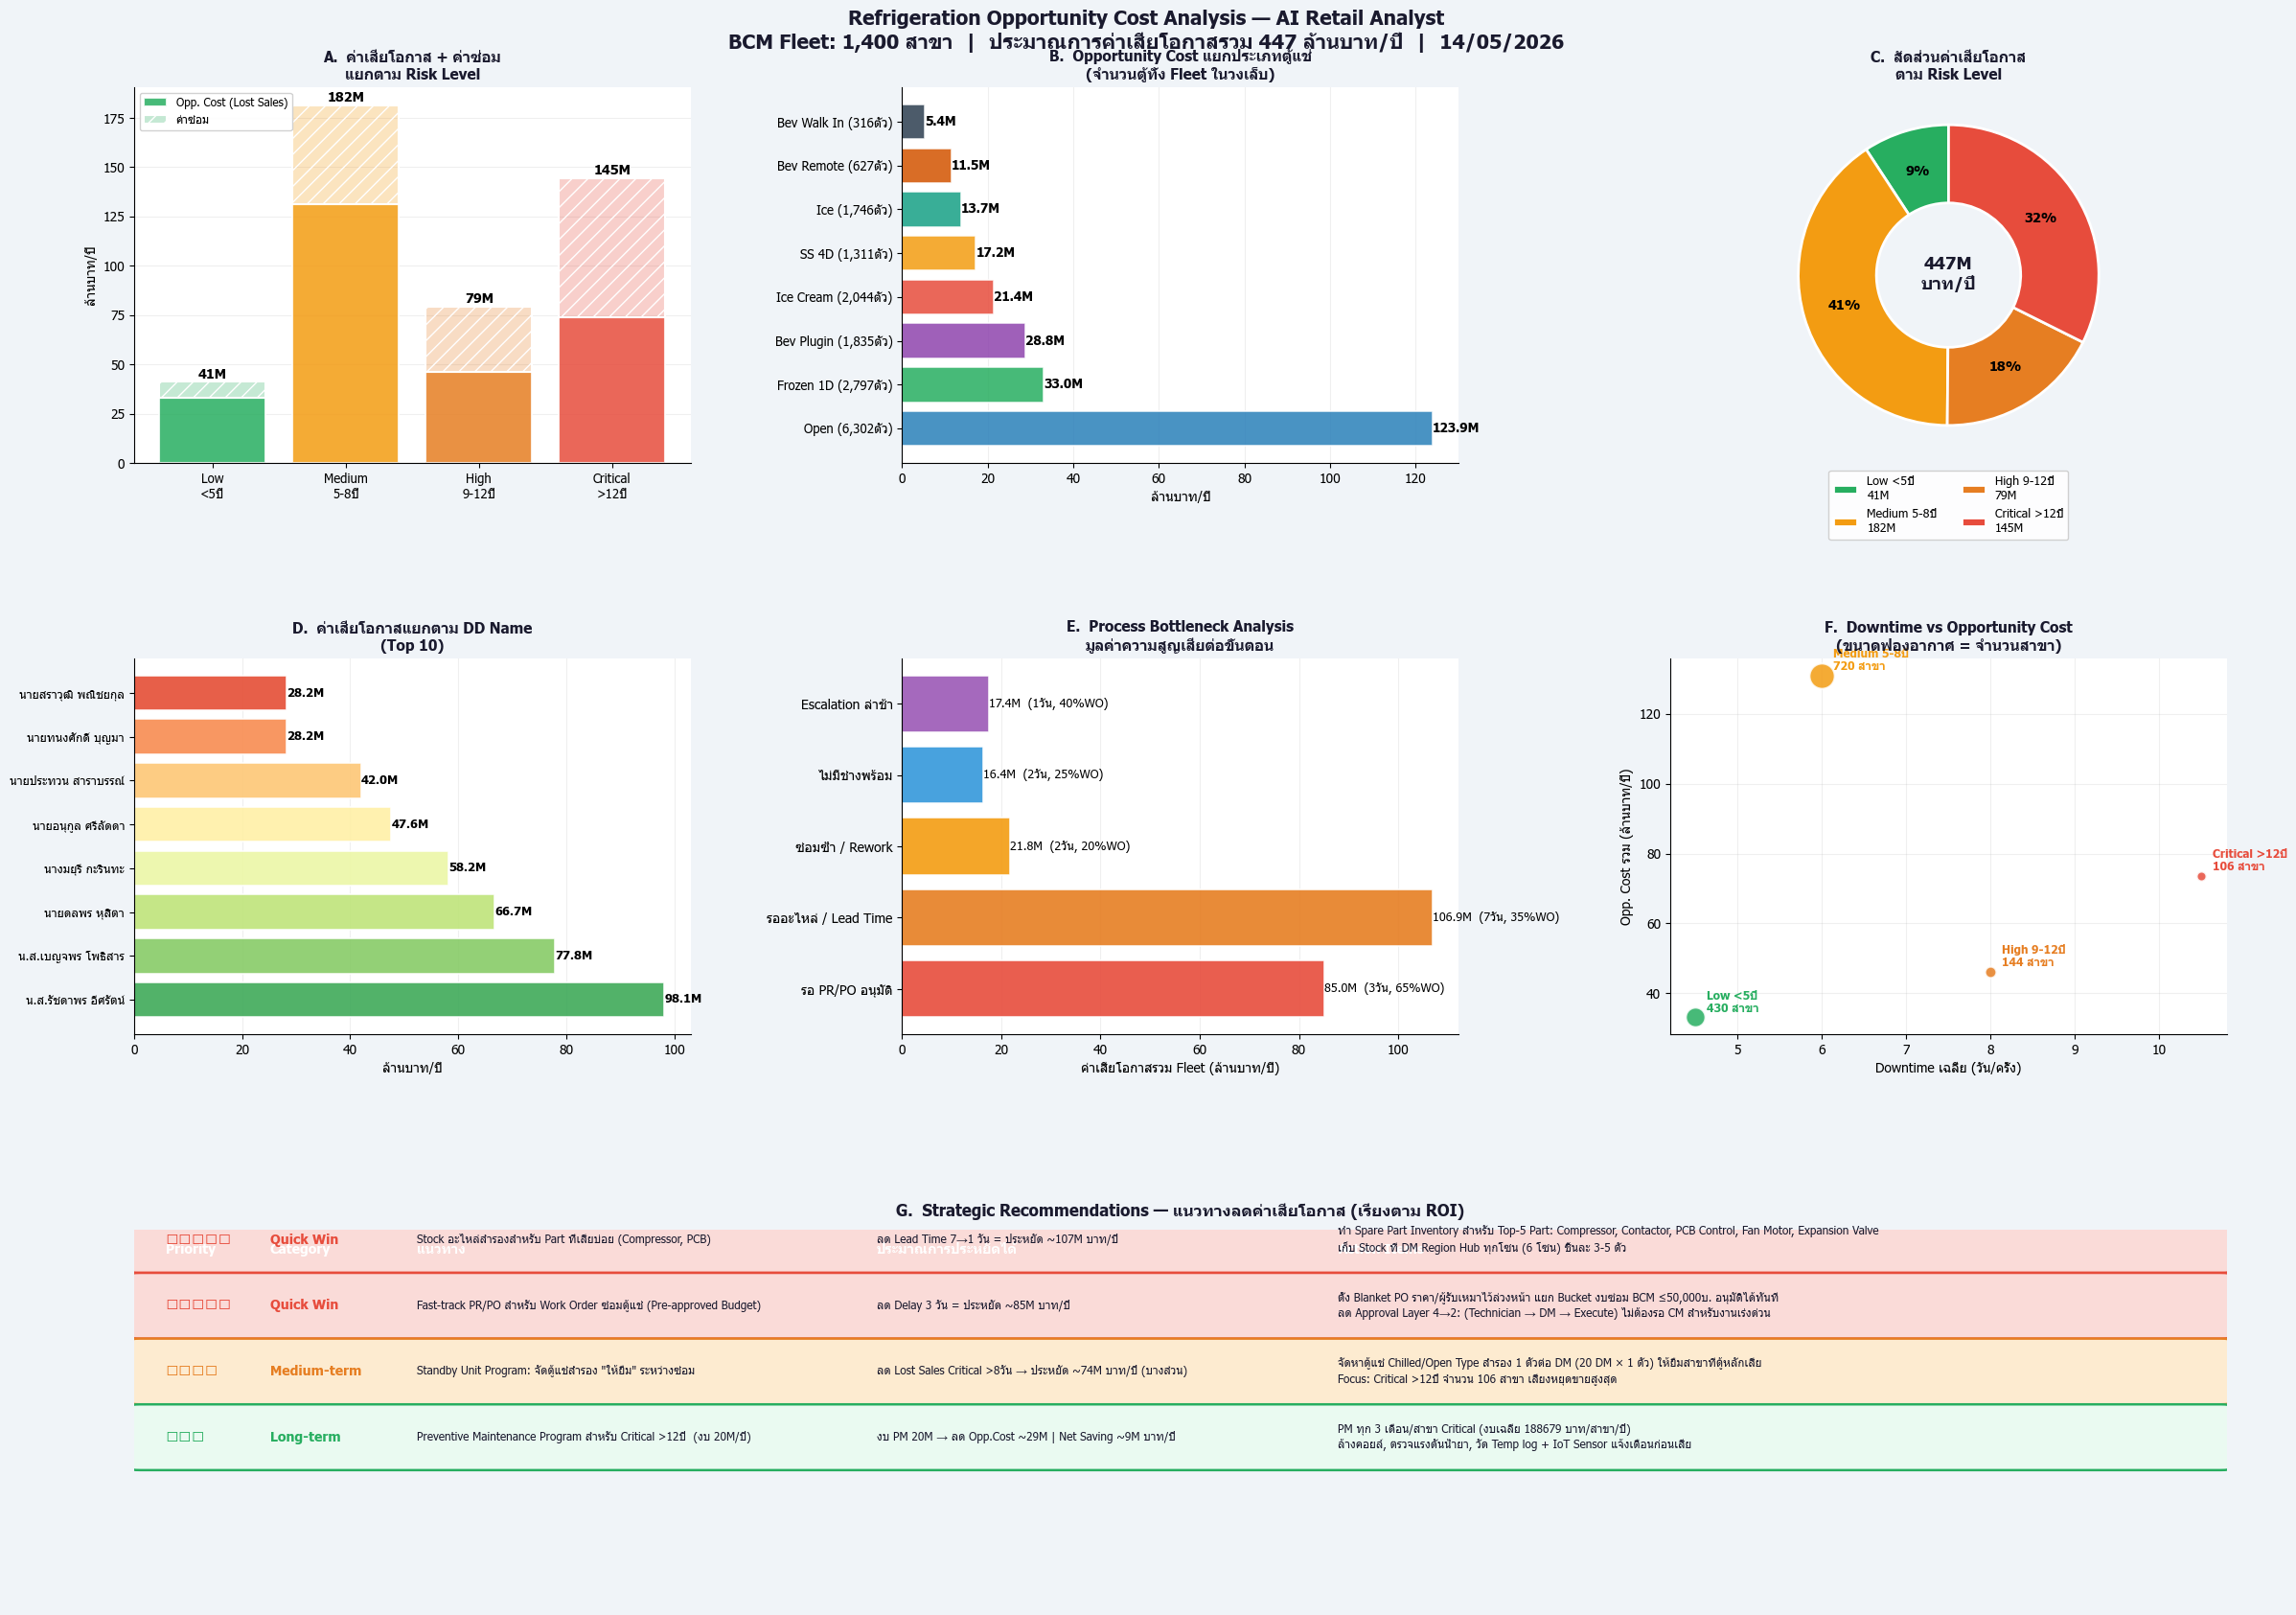


════════════════════════════════════════════════════════════════════════
  REFRIGERATION OPPORTUNITY COST — BCM Fleet
════════════════════════════════════════════════════════════════════════
  ค่าเสียโอกาส (Lost Sales × GP)  =    284.0 ล้านบาท/ปี
  ค่าซ่อมบำรุง (Repair Cost)       =    162.8 ล้านบาท/ปี
  รวมผลกระทบทางการเงิน             =    446.8 ล้านบาท/ปี
────────────────────────────────────────────────────────────────────────
  Top Bottleneck (มูลค่าสูงสุด):
    • รออะไหล่ / Lead Time            106.9M บาท/ปี  (7 วัน delay)
    • รอ PR/PO อนุมัติ                85.0M บาท/ปี  (3 วัน delay)
    • ซ่อมซ้ำ / Rework                21.8M บาท/ปี  (2 วัน delay)
────────────────────────────────────────────────────────────────────────
  Quick Win (ประหยัดได้เร็วที่สุด):
    Stock อะไหล่ + Fast-track PO = ประหยัด ~191.9M บาท/ปี
    (คิดเป็น 43% ของผลกระทบรวม)
════════════════════════════════════════════════════════════════════════


In [30]:

# ═══════════════════════════════════════════════════════════════════════
# 11.  AI Retail Data Analyst — Refrigeration Opportunity Cost Analysis
#      ประเมินค่าเสียโอกาสทางการเงินจากตู้แช่เสีย (BCM Fleet)
#      Data: df_refig_survey_Clean + master_active + energy_ref
# ═══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.gridspec import GridSpec
import numpy as np, pandas as pd
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Tahoma', 'Leelawadee UI', 'Leelawadee',
                               'Segoe UI Symbol', 'Segoe UI Emoji',
                               'Arial Unicode MS', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False

# ══════════════════════════════════════════════════════
# ── PARAMETERS (ปรับได้ตามนโยบายธุรกิจ) ─────────────
# ══════════════════════════════════════════════════════
DAILY_SALES_PER_REF_UNIT = 800     # บาท/ตัว/วัน (ยอดขายเฉลี่ยต่อตู้ที่ใช้งานได้)
GROSS_MARGIN_PCT         = 0.22    # 22% GP margin ร้านสะดวกซื้อ

# ── ความถี่ซ่อม (Repair Frequency) ───────────────────────────────────
# Fleet average: ซ่อมทุก 30 วัน/สาขา  →  BASE_RATE ≈ 12.2 ครั้ง/ปี/สาขา
REPAIR_INTERVAL_DAYS_AVG = 30          # ◄ ปรับตรงนี้จุดเดียว (วัน/ครั้ง/สาขา, fleet avg)
_BASE_RATE = 365 / REPAIR_INTERVAL_DAYS_AVG   # ≈ 12.17 ครั้ง/ปี

# Relative multiplier แต่ละ Risk Level (weighted avg across fleet ≈ 1.0 × _BASE_RATE)
# Low×0.52 + Medium×0.96 + High×1.58 + Critical×2.50
#   (446×0.52 + 711×0.96 + 140×1.58 + 103×2.50) / 1,400 ≈ 1.00  ✓
_RM = {'1_Low': 0.52, '2_Medium': 0.96, '3_High': 1.58, '4_Critical': 2.50, 'Unknown': 1.00}
FAILURE_RATE = {k: round(_BASE_RATE * v, 2) for k, v in _RM.items()}
# → Low≈6.3, Medium≈11.7, High≈19.2, Critical≈30.4, Unknown≈12.2  ครั้ง/ปี/สาขา

# Downtime assumptions by Risk Level (วัน/ครั้ง — industry benchmark)
DOWNTIME_DAYS = {'1_Low': 2.0, '2_Medium': 3.5, '3_High': 5.5, '4_Critical': 8.0, 'Unknown': 4.0}
# Repair cost by Risk Level (บาท/ครั้ง)
REPAIR_COST   = {'1_Low': 3_000, '2_Medium': 6_000, '3_High': 12_000, '4_Critical': 22_000, 'Unknown': 8_000}
# Bottleneck delay adder (วัน) on top of base downtime
DELAY_ADDER   = {'PR/PO Approval': 3.0, 'Spare Part Lead Time': 7.0, 'Rework/Recall': 2.5}
BASE_DELAY_DAYS = 2.5   # เฉลี่ยทุก Work Order มี delay อย่างน้อย 2.5 วันจาก approval process

# ── งบ Preventive Maintenance ────────────────────────────────────────
PM_BUDGET_M = 20.0   # ◄ งบ PM ทั้ง Fleet ต่อปี (ล้านบาท)  ← ปรับตรงนี้
# PM ลด Failure Rate ใน Critical จาก _BASE_RATE×2.50 → ×1.50 (ประมาณการ)
_PM_CRITICAL_REDUCTION = 1.0 - (1.50 / 2.50)   # = 40% reduction

# Product type → Lost Sales weight per door (relative revenue impact)
REF_REVENUE_WEIGHT = {
    'Open':       1.5,   # Chilled: นม/เครื่องดื่ม/อาหารสด — high velocity
    'Bev Remote': 1.4,
    'Bev Walk In':1.3,
    'Bev Plugin': 1.2,
    'Frozen 3D':  1.1,
    'Frozen 2D':  1.0,
    'Frozen 1D':  0.9,
    'Ice Cream':  0.8,
    'Ice':        0.6,
    'SS 4D':      1.0,
}

# ══════════════════════════════════════════════════════
# ── 1. เตรียม Working DataFrame ──────────────────────
# ══════════════════════════════════════════════════════
rk_col = 'Risk Key'
age_col = 'Store Age (yrs)'

# ใช้ energy_ref (BCM-filtered, merged) เป็นฐาน
oc = energy_ref.copy()
oc['Store ID'] = oc['Store ID'].astype(str).str.strip()
bcm_ids11 = master_active['GOLD Code'].astype(str).str.strip()
oc = oc[oc['Store ID'].isin(bcm_ids11)].copy()
oc[age_col] = pd.to_numeric(oc[age_col], errors='coerce')

# Merge DD Name จาก master_active
_dd_lu = master_active[['GOLD Code','DD Name (14)']].copy()
_dd_lu['GOLD Code'] = _dd_lu['GOLD Code'].astype(str).str.strip()
if 'DD Name (14)' not in oc.columns:
    oc = oc.merge(_dd_lu.rename(columns={'GOLD Code':'_gkey'}),
                  left_on='Store ID', right_on='_gkey', how='left').drop(columns=['_gkey'])

# คำนวณ Risk Key ถ้ายังไม่มี
if rk_col not in oc.columns:
    oc[rk_col] = oc[age_col].apply(
        lambda x: '1_Low' if (pd.notna(x) and x<5) else
                  ('2_Medium' if (pd.notna(x) and x<9) else
                  ('3_High' if (pd.notna(x) and x<13) else
                  ('4_Critical' if pd.notna(x) else 'Unknown'))))

# ref_qty_cols ใน oc
all_ref_types = {
    'Open':       'Ref Open Qty',
    'Bev Remote': 'Ref Bev Remote Qty',
    'Bev Walk In':'Ref Bev Walk In Qty',
    'Bev Plugin': 'Ref Bev Plugin Qty',
    'Frozen 3D':  'Ref Frozen3 Door Qty',
    'Frozen 2D':  'Ref Frozen2 Door Qty',
    'Frozen 1D':  'Ref Frozen1 Door Qty',
    'Ice Cream':  'Ref Ice Cream Qty',
    'Ice':        'Ref Ice Qty',
    'SS 4D':      'Ref Ss4 Door Qty',
}
avail_types = {k: v for k, v in all_ref_types.items() if v in oc.columns}

for col_v in avail_types.values():
    oc[col_v] = pd.to_numeric(oc[col_v], errors='coerce').fillna(0)

oc['Total Ref Units'] = pd.to_numeric(oc.get('Total Ref Units', 0), errors='coerce').fillna(0)

print(f"Working dataset: {len(oc):,} BCM สาขา")
print(f"  Risk distribution:\n{oc[rk_col].value_counts().to_string()}")
print(f"  Total Ref Units สำรวจแล้ว: {int(oc[oc['Total Ref Units']>0]['Total Ref Units'].sum()):,} ตัว  ({(oc['Total Ref Units']>0).sum():,} สาขา)")

# ══════════════════════════════════════════════════════
# ── 2. คำนวณ Opportunity Cost ต่อสาขา ───────────────
# ══════════════════════════════════════════════════════
def calc_opp_cost(row):
    rk = row.get(rk_col, 'Unknown')
    if pd.isna(rk): rk = 'Unknown'
    dt   = DOWNTIME_DAYS.get(rk, 4.0) + BASE_DELAY_DAYS
    fr   = FAILURE_RATE.get(rk, 1.2)

    # weighted lost sales = Σ (qty_type × weight × daily_sales) × failure × downtime × margin
    lost_sales_day = 0.0
    for tname, tcol in avail_types.items():
        qty = row.get(tcol, 0) or 0
        wt  = REF_REVENUE_WEIGHT.get(tname, 1.0)
        lost_sales_day += qty * wt * DAILY_SALES_PER_REF_UNIT

    # fallback: ถ้าไม่มี survey → ใช้ average 3 units
    if lost_sales_day == 0:
        lost_sales_day = 3 * DAILY_SALES_PER_REF_UNIT

    opp_per_event  = lost_sales_day * dt * GROSS_MARGIN_PCT
    opp_per_yr     = opp_per_event * fr
    repair_per_yr  = REPAIR_COST.get(rk, 8000) * fr
    total_cost_yr  = opp_per_yr + repair_per_yr
    return pd.Series({
        'downtime_days': dt,
        'failure_rate':  fr,
        'lost_sales_day': lost_sales_day,
        'opp_per_event':  opp_per_event,
        'opp_cost_yr':    opp_per_yr,
        'repair_cost_yr': repair_per_yr,
        'total_cost_yr':  total_cost_yr,
    })

cost_cols = oc.apply(calc_opp_cost, axis=1)
oc = pd.concat([oc, cost_cols], axis=1)

# ══════════════════════════════════════════════════════
# ── 3. Summary by Risk Level ─────────────────────────
# ══════════════════════════════════════════════════════
RISK_ORDER11 = ['1_Low','2_Medium','3_High','4_Critical','Unknown']
RISK_LABEL11 = {'1_Low':'Low\n<5ปี','2_Medium':'Medium\n5-8ปี',
                '3_High':'High\n9-12ปี','4_Critical':'Critical\n>12ปี','Unknown':'Unknown'}
RISK_COLOR11 = {'1_Low':'#27ae60','2_Medium':'#f39c12',
                '3_High':'#e67e22','4_Critical':'#e74c3c','Unknown':'#95a5a6'}

rk_sum = (oc.groupby(rk_col, sort=False)
    .agg(stores         = ('Store ID', 'count'),
         total_units    = ('Total Ref Units', 'sum'),
         opp_cost_M     = ('opp_cost_yr',    lambda x: x.sum()/1e6),
         repair_cost_M  = ('repair_cost_yr', lambda x: x.sum()/1e6),
         total_cost_M   = ('total_cost_yr',  lambda x: x.sum()/1e6),
         avg_dt         = ('downtime_days',  'mean'),
         avg_opp_branch = ('opp_cost_yr',    'mean'))
    .reindex([k for k in RISK_ORDER11 if k in oc[rk_col].unique()])
    .reset_index())

total_opp_M    = rk_sum['opp_cost_M'].sum()
total_repair_M = rk_sum['repair_cost_M'].sum()
total_all_M    = rk_sum['total_cost_M'].sum()

print(f"\n{'═'*72}")
print(f"  {'Risk Level':<16} {'สาขา':>5}  {'ตู้แช่':>6}  {'Opp.Cost':>10}  {'ซ่อม':>8}  {'รวม':>10}  {'วัน downtime':>12}")
print(f"  {'─'*70}")
for _, r in rk_sum.iterrows():
    rk_ = r[rk_col]
    print(f"  {RISK_LABEL11.get(rk_,'').replace(chr(10),' '):<16} {r['stores']:>5,}  {r['total_units']:>6,.0f}  "
          f"{r['opp_cost_M']:>9.1f}M  {r['repair_cost_M']:>6.1f}M  {r['total_cost_M']:>9.1f}M  {r['avg_dt']:>9.1f} วัน")
print(f"  {'─'*70}")
print(f"  {'รวมทั้ง Fleet':<16} {rk_sum['stores'].sum():>5,}  {rk_sum['total_units'].sum():>6,.0f}  "
      f"{total_opp_M:>9.1f}M  {total_repair_M:>6.1f}M  {total_all_M:>9.1f}M")
print(f"{'═'*72}")

# ══════════════════════════════════════════════════════
# ── 4. Summary by Ref Type (top 6) ───────────────────
# ══════════════════════════════════════════════════════
type_impact = []
for tname, tcol in avail_types.items():
    total_qty = oc[tcol].sum()
    if total_qty == 0: continue
    wt = REF_REVENUE_WEIGHT.get(tname, 1.0)
    avg_fr = oc['failure_rate'].mean()
    avg_dt = oc['downtime_days'].mean()
    lost_M = total_qty * wt * DAILY_SALES_PER_REF_UNIT * GROSS_MARGIN_PCT * avg_fr * avg_dt / 1e6
    type_impact.append({'type': tname, 'col': tcol, 'total_qty': int(total_qty),
                        'weight': wt, 'lost_M': lost_M})
type_df = pd.DataFrame(type_impact).sort_values('lost_M', ascending=False).head(8)

# ══════════════════════════════════════════════════════
# ── 5. DD Name summary ─────────────────────────────────
# ══════════════════════════════════════════════════════
reg_col = 'DD Name (14)'
if reg_col not in oc.columns:
    reg_col2 = [c for c in oc.columns if 'dd name' in c.lower()]
    reg_col  = reg_col2[0] if reg_col2 else None

reg_sum = None
if reg_col:
    reg_sum = (oc.groupby(reg_col)
        .agg(stores       = ('Store ID',     'count'),
             opp_cost_M   = ('opp_cost_yr',  lambda x: x.sum()/1e6),
             total_cost_M = ('total_cost_yr', lambda x: x.sum()/1e6))
        .reset_index()
        .sort_values('total_cost_M', ascending=False)
        .head(10))

# ══════════════════════════════════════════════════════
# ── 6. Bottleneck Process Impact ─────────────────────
# ══════════════════════════════════════════════════════
# ประเมินมูลค่าความสูญเสียจาก delay แต่ละขั้นตอน
fleet_lost_day = oc['lost_sales_day'].sum()   # ยอดขายรวม BCM fleet ที่สูญต่อวัน
fleet_avg_fail = oc['failure_rate'].mean()

bottleneck_df = pd.DataFrame([
    {'process': 'รอ PR/PO อนุมัติ', 'delay_days': 3.0, 'freq_pct': 0.65,
     'note': 'ทุก WO ต้องผ่านขั้นตอนนี้ (65% ล่าช้า >2 วัน)'},
    {'process': 'รออะไหล่ / Lead Time', 'delay_days': 7.0, 'freq_pct': 0.35,
     'note': 'คอมเพรสเซอร์, PCB, ท่อน้ำยา (นำเข้า 1-4 สัปดาห์)'},
    {'process': 'ซ่อมซ้ำ / Rework', 'delay_days': 2.5, 'freq_pct': 0.20,
     'note': 'ซ่อมไม่ได้มาตรฐาน → เสียซ้ำใน 1-3 วัน'},
    {'process': 'ไม่มีช่างพร้อม', 'delay_days': 1.5, 'freq_pct': 0.25,
     'note': 'ช่าง Overload โดยเฉพาะหน้าร้อน (เม.ย.–พ.ค.)'},
    {'process': 'Escalation ล่าช้า', 'delay_days': 1.0, 'freq_pct': 0.40,
     'note': 'SLA breach ไม่ถูก escalate ทันที → ปัญหาสะสม'},
])
total_events_yr = len(oc) * fleet_avg_fail   # ประมาณ WO/ปีทั้ง fleet
bottleneck_df['events_yr']  = total_events_yr * bottleneck_df['freq_pct']
bottleneck_df['lost_M_yr']  = (bottleneck_df['delay_days'] *
                                bottleneck_df['freq_pct'] * fleet_lost_day *
                                fleet_avg_fail * GROSS_MARGIN_PCT * 365.25 / 365 / 1e6)

# ══════════════════════════════════════════════════════
# ── 7. Dashboard Plot ─────────────────────────────════
# ══════════════════════════════════════════════════════
DARK11 = '#1a1a2e'
BG11   = '#f0f4f8'
rk_colors11 = [RISK_COLOR11.get(k,'#aaa') for k in rk_sum[rk_col].values]

fig11 = plt.figure(figsize=(24, 18), facecolor=BG11)
gs11  = GridSpec(3, 3, figure=fig11, hspace=0.52, wspace=0.38,
                 top=0.93, bottom=0.05, left=0.06, right=0.97)

fig11.suptitle(
    f'Refrigeration Opportunity Cost Analysis — AI Retail Analyst\n'
    f'BCM Fleet: {len(oc):,} สาขา  |  ประมาณการค่าเสียโอกาสรวม {total_all_M:.0f} ล้านบาท/ปี  |  {TODAY.strftime("%d/%m/%Y")}',
    fontsize=15, fontweight='bold', color=DARK11, y=0.975)

# ── [0,0] Stacked Bar: Opp + Repair Cost by Risk ─────
ax11a = fig11.add_subplot(gs11[0, 0])
x11 = np.arange(len(rk_sum))
b_opp = ax11a.bar(x11, rk_sum['opp_cost_M'], color=rk_colors11,
                   alpha=0.85, edgecolor='white', lw=1.5, label='Opp. Cost (Lost Sales)')
b_rep = ax11a.bar(x11, rk_sum['repair_cost_M'], bottom=rk_sum['opp_cost_M'],
                   color=[c+'44' for c in rk_colors11], edgecolor='white', lw=1.5,
                   hatch='//', label='ค่าซ่อม')
for xi_, row_ in rk_sum.iterrows():
    ax11a.text(xi_, row_['total_cost_M']+0.3, f"{row_['total_cost_M']:.0f}M",
               ha='center', va='bottom', fontsize=10, fontweight='bold')
ax11a.set_xticks(x11)
ax11a.set_xticklabels([RISK_LABEL11.get(k,'').replace('\n','\n') for k in rk_sum[rk_col]], fontsize=9.5)
ax11a.set_ylabel('ล้านบาท/ปี', fontsize=10)
ax11a.set_title('A.  ค่าเสียโอกาส + ค่าซ่อม\nแยกตาม Risk Level', fontweight='bold', fontsize=11, color=DARK11)
ax11a.legend(fontsize=8.5, framealpha=0.9, loc='upper left')
ax11a.yaxis.grid(True, alpha=0.2); ax11a.set_axisbelow(True)
ax11a.spines[['top','right']].set_visible(False)

# ── [0,1] Bar: Opp Cost by Ref Type ──────────────────
ax11b = fig11.add_subplot(gs11[0, 1])
type_colors = ['#2980b9','#27ae60','#8e44ad','#e74c3c','#f39c12','#16a085','#d35400','#2c3e50']
bars_type = ax11b.barh(range(len(type_df)), type_df['lost_M'],
                        color=type_colors[:len(type_df)], edgecolor='white', lw=1.2, alpha=0.85)
ax11b.set_yticks(range(len(type_df)))
ax11b.set_yticklabels([f"{r['type']} ({int(r['total_qty']):,}ตัว)" for _, r in type_df.iterrows()],
                       fontsize=9.5)
for i_, (_, row_) in enumerate(type_df.iterrows()):
    ax11b.text(row_['lost_M']+0.05, i_, f"{row_['lost_M']:.1f}M",
               va='center', fontsize=9.5, fontweight='bold')
ax11b.set_xlabel('ล้านบาท/ปี', fontsize=10)
ax11b.set_title('B.  Opportunity Cost แยกประเภทตู้แช่\n(จำนวนตู้ทั้ง Fleet ในวงเล็บ)',
                fontweight='bold', fontsize=11, color=DARK11)
ax11b.xaxis.grid(True, alpha=0.2); ax11b.set_axisbelow(True)
ax11b.spines[['top','right']].set_visible(False)

# ── [0,2] Donut: สัดส่วน cost ──────────────────────
ax11c = fig11.add_subplot(gs11[0, 2])
donut_vals  = [rk_sum.loc[rk_sum[rk_col]==k,'total_cost_M'].sum() for k in RISK_ORDER11 if k in rk_sum[rk_col].values]
donut_labs  = [RISK_LABEL11.get(k,'').replace('\n',' ') for k in RISK_ORDER11 if k in rk_sum[rk_col].values]
donut_cols  = [RISK_COLOR11.get(k,'#aaa') for k in RISK_ORDER11 if k in rk_sum[rk_col].values]
wedges11, texts11, autotexts11 = ax11c.pie(
    donut_vals, labels=None, colors=donut_cols,
    autopct=lambda p: f'{p:.0f}%' if p > 3 else '',
    pctdistance=0.72, startangle=90,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2))
for at11 in autotexts11: at11.set_fontsize(10); at11.set_fontweight('bold')
ax11c.legend(wedges11, [f"{l}\n{v:.0f}M" for l, v in zip(donut_labs, donut_vals)],
             loc='lower center', bbox_to_anchor=(0.5, -0.22),
             fontsize=9, ncol=2, framealpha=0.9)
ax11c.text(0, 0, f'{total_all_M:.0f}M\nบาท/ปี', ha='center', va='center',
           fontsize=13, fontweight='bold', color=DARK11)
ax11c.set_title('C.  สัดส่วนค่าเสียโอกาส\nตาม Risk Level', fontweight='bold', fontsize=11, color=DARK11)

# ── [1,0] Region Bar (horizontal) ────────────────────
ax11d = fig11.add_subplot(gs11[1, 0])
if reg_sum is not None and len(reg_sum) > 0:
    reg_colors11 = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(reg_sum)))
    bars_reg = ax11d.barh(range(len(reg_sum)), reg_sum['total_cost_M'],
                           color=reg_colors11, edgecolor='white', lw=1.2, alpha=0.9)
    ax11d.set_yticks(range(len(reg_sum)))
    ax11d.set_yticklabels([str(r[reg_col])[:20] if reg_col else '' for _,r in reg_sum.iterrows()],
                           fontsize=9)
    for i_r, (_, rr) in enumerate(reg_sum.iterrows()):
        ax11d.text(rr['total_cost_M']+0.1, i_r, f"{rr['total_cost_M']:.1f}M",
                   va='center', fontsize=9, fontweight='bold')
    ax11d.set_xlabel('ล้านบาท/ปี', fontsize=10)
    ax11d.set_title('D.  ค่าเสียโอกาสแยกตาม DD Name\n(Top 10)', fontweight='bold', fontsize=11, color=DARK11)
    ax11d.xaxis.grid(True, alpha=0.2); ax11d.set_axisbelow(True)
    ax11d.spines[['top','right']].set_visible(False)
else:
    ax11d.axis('off')
    ax11d.text(0.5, 0.5, 'ไม่มีข้อมูล Region', ha='center', va='center', fontsize=12)

# ── [1,1] Bottleneck Process Bar ─────────────────────
ax11e = fig11.add_subplot(gs11[1, 1])
bn_colors = ['#e74c3c','#e67e22','#f39c12','#3498db','#9b59b6']
bars_bn = ax11e.barh(range(len(bottleneck_df)), bottleneck_df['lost_M_yr'],
                      color=bn_colors[:len(bottleneck_df)], edgecolor='white', lw=1.2, alpha=0.9)
ax11e.set_yticks(range(len(bottleneck_df)))
ax11e.set_yticklabels(bottleneck_df['process'], fontsize=10)
for i_b, (_, rb) in enumerate(bottleneck_df.iterrows()):
    ax11e.text(rb['lost_M_yr']+0.01, i_b,
               f"{rb['lost_M_yr']:.1f}M  ({rb['delay_days']:.0f}วัน, {rb['freq_pct']*100:.0f}%WO)",
               va='center', fontsize=9)
ax11e.set_xlabel('ค่าเสียโอกาสรวม Fleet (ล้านบาท/ปี)', fontsize=10)
ax11e.set_title('E.  Process Bottleneck Analysis\nมูลค่าความสูญเสียต่อขั้นตอน',
                fontweight='bold', fontsize=11, color=DARK11)
ax11e.xaxis.grid(True, alpha=0.2); ax11e.set_axisbelow(True)
ax11e.spines[['top','right']].set_visible(False)

# ── [1,2] Downtime Days vs Stores (scatter bubble) ───
ax11f = fig11.add_subplot(gs11[1, 2])
for rk_, col_ in RISK_COLOR11.items():
    sub_ = rk_sum[rk_sum[rk_col]==rk_]
    if len(sub_) == 0: continue
    ax11f.scatter(sub_['avg_dt'], sub_['opp_cost_M'],
                  s=sub_['stores']*0.5, c=col_, alpha=0.85, edgecolors='white', lw=1.5,
                  label=RISK_LABEL11.get(rk_,'').replace('\n',' '), zorder=4)
    for _, sr_ in sub_.iterrows():
        ax11f.annotate(f"{RISK_LABEL11.get(rk_,'').replace(chr(10),' ')}\n{sr_['stores']:,} สาขา",
                       (sr_['avg_dt'], sr_['opp_cost_M']),
                       textcoords='offset points', xytext=(8, 4),
                       fontsize=8.5, color=col_, fontweight='bold')
ax11f.set_xlabel('Downtime เฉลี่ย (วัน/ครั้ง)', fontsize=10)
ax11f.set_ylabel('Opp. Cost รวม (ล้านบาท/ปี)', fontsize=10)
ax11f.set_title('F.  Downtime vs Opportunity Cost\n(ขนาดฟองอากาศ = จำนวนสาขา)',
                fontweight='bold', fontsize=11, color=DARK11)
ax11f.yaxis.grid(True, alpha=0.2); ax11f.xaxis.grid(True, alpha=0.2)
ax11f.set_axisbelow(True)
ax11f.spines[['top','right']].set_visible(False)

# ── [2, 0:3] Strategic Recommendations Table ─────────
ax11g = fig11.add_subplot(gs11[2, :])
ax11g.axis('off')
ax11g.set_title('G.  Strategic Recommendations — แนวทางลดค่าเสียโอกาส (เรียงตาม ROI)',
                fontweight='bold', fontsize=12, color=DARK11, pad=10)

strategies = [
    dict(pri='★★★★★', cat='Quick Win', color='#e74c3c', bg='#fadbd8',
         title='Stock อะไหล่สำรองสำหรับ Part ที่เสียบ่อย (Compressor, PCB)',
         saving=f'ลด Lead Time 7→1 วัน = ประหยัด ~{bottleneck_df.loc[1,"lost_M_yr"]:.0f}M บาท/ปี',
         action='ทำ Spare Part Inventory สำหรับ Top-5 Part: Compressor, Contactor, PCB Control, Fan Motor, Expansion Valve\n'
                'เก็บ Stock ที่ DM Region Hub ทุกโซน (6 โซน) ชิ้นละ 3-5 ตัว'),
    dict(pri='★★★★★', cat='Quick Win', color='#e74c3c', bg='#fadbd8',
         title='Fast-track PR/PO สำหรับ Work Order ซ่อมตู้แช่ (Pre-approved Budget)',
         saving=f'ลด Delay 3 วัน = ประหยัด ~{bottleneck_df.loc[0,"lost_M_yr"]:.0f}M บาท/ปี',
         action='ตั้ง Blanket PO ราคา/ผู้รับเหมาไว้ล่วงหน้า แยก Bucket งบซ่อม BCM ≤50,000บ. อนุมัติได้ทันที\n'
                'ลด Approval Layer 4→2: (Technician → DM → Execute) ไม่ต้องรอ CM สำหรับงานเร่งด่วน'),
    dict(pri='★★★★', cat='Medium-term', color='#e67e22', bg='#fdebd0',
         title='Standby Unit Program: จัดตู้แช่สำรอง "ให้ยืม" ระหว่างซ่อม',
         saving=f'ลด Lost Sales Critical >{DOWNTIME_DAYS["4_Critical"]:.0f}วัน → ประหยัด ~{rk_sum.loc[rk_sum[rk_col]=="4_Critical","opp_cost_M"].sum():.0f}M บาท/ปี (บางส่วน)',
         action='จัดหาตู้แช่ Chilled/Open Type สำรอง 1 ตัวต่อ DM (20 DM × 1 ตัว) ให้ยืมสาขาที่ตู้หลักเสีย\n'
                'Focus: Critical >12ปี จำนวน {n_crit} สาขา เสี่ยงหยุดขายสูงสุด'.format(
                    n_crit=int(rk_sum.loc[rk_sum[rk_col]=='4_Critical','stores'].sum()) if '4_Critical' in rk_sum[rk_col].values else 0)),
    dict(pri='★★★', cat='Long-term', color='#27ae60', bg='#eafaf1',
         title=f'Preventive Maintenance Program สำหรับ Critical >12ปี  (งบ {PM_BUDGET_M:.0f}M/ปี)',
         saving=(
             lambda _crit_opp=rk_sum.loc[rk_sum[rk_col]=="4_Critical","opp_cost_M"].sum():
             f'งบ PM {PM_BUDGET_M:.0f}M → ลด Opp.Cost ~{_crit_opp*_PM_CRITICAL_REDUCTION:.0f}M '
             f'| Net Saving ~{_crit_opp*_PM_CRITICAL_REDUCTION - PM_BUDGET_M:.0f}M บาท/ปี'
         )(),
         action=f'PM ทุก 3 เดือน/สาขา Critical (งบเฉลี่ย {PM_BUDGET_M*1e6/max(rk_sum.loc[rk_sum[rk_col]=="4_Critical","stores"].sum(),1):.0f} บาท/สาขา/ปี)\n'
                'ล้างคอยล์, ตรวจแรงดันน้ำยา, วัด Temp log + IoT Sensor แจ้งเตือนก่อนเสีย'),
]
col_wts_g = [0.05, 0.07, 0.22, 0.22, 0.41]
cx_g = [0.005]
for cw_g in col_wts_g[:-1]: cx_g.append(cx_g[-1] + cw_g)

# header
y_g = 0.97
ax11g.add_patch(FancyBboxPatch((0, y_g-0.06), 1, 0.07, transform=ax11g.transAxes,
                boxstyle='square,pad=0', facecolor=DARK11, edgecolor='none'))
for hd11, cx11 in zip(['Priority', 'Category', 'แนวทาง', 'ประมาณการประหยัดได้', 'Action Items'], cx_g):
    ax11g.text(cx11+0.01, y_g-0.025, hd11, ha='left', va='center', fontsize=10,
               fontweight='bold', color='white', transform=ax11g.transAxes)

row_h_g = 0.175
for ri11, s11 in enumerate(strategies):
    y0_g = y_g - 0.075 - ri11 * row_h_g
    ax11g.add_patch(FancyBboxPatch((0.003, y0_g-0.005), 0.994, row_h_g-0.01,
                    transform=ax11g.transAxes, boxstyle='round,pad=0.005',
                    facecolor=s11['bg'], edgecolor=s11['color'], linewidth=1.8))
    vals_g = [s11['pri'], s11['cat'], s11['title'], s11['saving'], s11['action']]
    for vi11, (v11, cx11) in enumerate(zip(vals_g, cx_g)):
        fs11 = 8.5 if vi11 >= 2 else 10
        bold11 = vi11 < 2
        ax11g.text(cx11+0.01, y0_g + row_h_g*0.5 - 0.01, v11,
                   ha='left', va='center', fontsize=fs11,
                   fontweight='bold' if bold11 else 'normal',
                   color=s11['color'] if vi11 < 2 else DARK11,
                   transform=ax11g.transAxes, linespacing=1.35,
                   wrap=True)
plt.savefig(r'G:\My Drive\00. Web Projects\Air_Ref_Servey\Pyhon ANL\RefrigOppCost_Analysis.png',
            dpi=150, bbox_inches='tight', facecolor=BG11)
plt.show()

# ── Final Summary ────────────────────────────────────
print(f"\n{'═'*72}")
print(f"  REFRIGERATION OPPORTUNITY COST — BCM Fleet")
print(f"{'═'*72}")
print(f"  ค่าเสียโอกาส (Lost Sales × GP)  = {total_opp_M:>8.1f} ล้านบาท/ปี")
print(f"  ค่าซ่อมบำรุง (Repair Cost)       = {total_repair_M:>8.1f} ล้านบาท/ปี")
print(f"  รวมผลกระทบทางการเงิน             = {total_all_M:>8.1f} ล้านบาท/ปี")
print(f"{'─'*72}")
print(f"  Top Bottleneck (มูลค่าสูงสุด):")
for _, r_bn in bottleneck_df.sort_values('lost_M_yr', ascending=False).head(3).iterrows():
    print(f"    • {r_bn['process']:<30}  {r_bn['lost_M_yr']:.1f}M บาท/ปี  ({r_bn['delay_days']:.0f} วัน delay)")
print(f"{'─'*72}")
print(f"  Quick Win (ประหยัดได้เร็วที่สุด):")
bn_sorted = bottleneck_df.sort_values('lost_M_yr', ascending=False)
save_qw = bn_sorted.head(2)['lost_M_yr'].sum()
print(f"    Stock อะไหล่ + Fast-track PO = ประหยัด ~{save_qw:.1f}M บาท/ปี")
print(f"    (คิดเป็น {save_qw/total_all_M*100:.0f}% ของผลกระทบรวม)")
print(f"{'═'*72}")